In [2]:
import os

data_path = "../data"

print("Files available:")

for file in os.listdir(data_path):
    print(file)

Files available:
master_quality_report.csv
master_quality_report_final.csv
olist_customers_dataset.csv
olist_geolocation_dataset.csv
olist_orders_dataset.csv
olist_order_items_dataset.csv
olist_order_payments_dataset.csv
olist_order_reviews_dataset.csv
olist_products_dataset.csv
olist_sellers_dataset.csv
product_category_name_translation.csv


# **Customers table Inspection**

In [3]:
import pandas as pd

customers = pd.read_csv("../data/olist_customers_dataset.csv")

print("Rows:", customers.shape[0])
print("Columns:", customers.shape[1])

customers.head()

Rows: 99441
Columns: 5


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [4]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [5]:
customers.isnull().sum()

customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

In [6]:
print("Duplicate rows:", customers.duplicated().sum())

print("Unique customer_id:", customers["customer_id"].nunique())

print("Unique customer_unique_id:", customers["customer_unique_id"].nunique())

print("Total rows:", len(customers))

Duplicate rows: 0
Unique customer_id: 99441
Unique customer_unique_id: 96096
Total rows: 99441


In [7]:
customers.describe(include="all")

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
count,99441,99441,99441.000000,99441,99441
unique,99441,96096,NaN,4119,27
top,06b8999e2fba1a1fbc88172c00ba8bc7,8d50f5eadf50201ccdcedfb9e2ac8455,NaN,sao paulo,SP
freq,1,17,NaN,15540,41746
mean,NaN,NaN,35137.474583,NaN,NaN
std,NaN,NaN,29797.938996,NaN,NaN
min,NaN,NaN,1003.000000,NaN,NaN
25%,NaN,NaN,11347.000000,NaN,NaN
50%,NaN,NaN,24416.000000,NaN,NaN
75%,NaN,NaN,58900.000000,NaN,NaN


In [8]:
customers["customer_state"].value_counts().head(10)

customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
Name: count, dtype: int64

# orders table inspection

In [9]:
orders = pd.read_csv("../data/olist_orders_dataset.csv")

print("Rows:", orders.shape[0])
print("Columns:", orders.shape[1])

orders.head()

Rows: 99441
Columns: 8


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [10]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [11]:
orders.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [12]:
orders["order_status"].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [13]:
orders_analysis = orders.copy()

date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_columns:
    orders_analysis[col] = pd.to_datetime(orders_analysis[col])

orders_analysis.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.1+ MB


In [14]:
orders_analysis["delivery_days"] = (
    orders_analysis["order_delivered_customer_date"]
    - orders_analysis["order_purchase_timestamp"]
).dt.days

orders_analysis["delivery_delay_days"] = (
    orders_analysis["order_delivered_customer_date"]
    - orders_analysis["order_estimated_delivery_date"]
).dt.days

In [15]:
orders_analysis[
    [
        "order_id",
        "order_status",
        "delivery_days",
        "delivery_delay_days"
    ]
].head(10)


,order_id,order_status,delivery_days,delivery_delay_days
0,e481f51cbdc54678b7cc49136f2d6af7,delivered,8.0,-8.0
1,53cdb2fc8bc7dce0b6741e2150273451,delivered,13.0,-6.0
2,47770eb9100c2d0c44946d9cf07ec65d,delivered,9.0,-18.0
3,949d5b44dbf5de918fe9c16f97b45f8a,delivered,13.0,-13.0
4,ad21c59c0840e6cb83a9ceb5573f8159,delivered,2.0,-10.0
5,a4591c265e18cb1dcee52889e2d8acc3,delivered,16.0,-6.0
6,136cce7faa42fdb2cefd53fdc79a6098,invoiced,NaN,NaN
7,6514b8ad8028c9f2cc2374ded245783f,delivered,9.0,-12.0
8,76c6e866289321a7c93b82b54852dc33,delivered,9.0,-32.0
9,e69bfb5eb88e0ed6a785585b27e16dbf,delivered,18.0,-7.0


In [16]:
delivered_orders = orders_analysis[
    orders_analysis["order_status"] == "delivered"
].copy()

on_time_orders = delivered_orders[
    delivered_orders["delivery_delay_days"] <= 0
]

on_time_delivery_rate = (
    len(on_time_orders) / len(delivered_orders)
) * 100

print("Total Delivered Orders:", len(delivered_orders))
print("On-Time Orders:", len(on_time_orders))
print("On-Time Delivery Rate:", round(on_time_delivery_rate, 2), "%")

Total Delivered Orders: 96478
On-Time Orders: 89936
On-Time Delivery Rate: 93.22 %


# Order_item table inspection for Calculate Revenue

In [17]:
order_items = pd.read_csv("../data/olist_order_items_dataset.csv")

print("Rows:", order_items.shape[0])
print("Columns:", order_items.shape[1])

order_items.head()

Rows: 112650
Columns: 7


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [18]:
order_items.info()
order_items.isnull().sum()
order_items.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


np.int64(0)

In [19]:
total_revenue = order_items["price"].sum()

print("Total Revenue:",round(total_revenue,2))

Total Revenue: 13591643.7


In [20]:
total_freight = order_items["freight_value"].sum()

print("Total Freight Cost:", round(total_freight, 2))

Total Freight Cost: 2251909.54


In [21]:
order_revenue = order_items.groupby("order_id")["price"].sum()

average_order_value = order_revenue.mean()

print("Average Order Value:", round(average_order_value, 2))

Average Order Value: 137.75


In [22]:
sales_data = order_items.merge(
    orders_analysis[
        ["order_id", "order_status", "order_purchase_timestamp"]
    ],
    on="order_id",
    how="left"
)

sales_data.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,order_status,order_purchase_timestamp
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,delivered,2017-09-13 08:59:02
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,delivered,2017-04-26 10:53:06
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,delivered,2018-01-14 14:33:31
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,delivered,2018-08-08 10:00:35
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,delivered,2017-02-04 13:57:51


In [23]:
print("Rows:", sales_data.shape[0])
print("Columns:", sales_data.shape[1])

Rows: 112650
Columns: 9


In [24]:
sales_data = sales_data[
    sales_data["order_status"] == "delivered"
].copy()

print("Delivered Sales Rows:", sales_data.shape[0])

Delivered Sales Rows: 110197


In [25]:
sales_data["month"] = sales_data[
    "order_purchase_timestamp"
].dt.to_period("M").astype(str)

sales_data[["order_id", "price", "month"]].head()

,order_id,price,month
0,00010242fe8c5a6d1ba2dd792cb16214,58.90,2017-09
1,00018f77f2f0320c557190d7a144bdd3,239.90,2017-04
2,000229ec398224ef6ca0657da4fc703e,199.00,2018-01
3,00024acbcdf0a6daa1e931b038114c75,12.99,2018-08
4,00042b26cf59d7ce69dfabb4e55b4fd9,199.90,2017-02


In [26]:
monthly_revenue = (
    sales_data
    .groupby("month")["price"]
    .sum()
    .reset_index()
)

monthly_revenue.columns = ["month", "revenue"]

monthly_revenue

,month,revenue
0,2016-09,134.97
1,2016-10,40325.11
2,2016-12,10.90
3,2017-01,111798.36
4,2017-02,234223.40
5,2017-03,359198.85
6,2017-04,340669.68
7,2017-05,489338.25
8,2017-06,421923.37
9,2017-07,481604.52


In [27]:
highest_revenue_month = monthly_revenue.loc[
    monthly_revenue["revenue"].idxmax()
]

print("Highest Revenue Month:", highest_revenue_month["month"])
print("Revenue:", round(highest_revenue_month["revenue"], 2))

Highest Revenue Month: 2017-11
Revenue: 987765.37


In [28]:
lowest_revenue_month = monthly_revenue.loc[
    monthly_revenue["revenue"].idxmin()
]

print("Lowest Revenue Month:", lowest_revenue_month["month"])
print("Revenue:", round(lowest_revenue_month["revenue"], 2))

Lowest Revenue Month: 2016-12
Revenue: 10.9


# products table inspection 

In [29]:
products = pd.read_csv("../data/olist_products_dataset.csv")

print("Rows:", products.shape[0])
print("Columns:", products.shape[1])

products.head()

Rows: 32951
Columns: 9


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [30]:
products.info()
products.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

In [31]:
product_revenue = (
    sales_data
    .groupby("product_id")["price"]
    .sum()
    .reset_index()
)

product_revenue.columns = ["product_id", "revenue"]

product_revenue = product_revenue.sort_values(
    "revenue",
    ascending=False
)

product_revenue.head(10)

,product_id,revenue
23546,bb50f2e236e5eea0100680137654686c,63560.00
13749,6cdd53843498f92890544667809f1595,53652.30
26997,d6160fb7873f184099d9bc95e30376af,45949.35
26436,d1c427060a0f73f6b889a5c7c61f2ac4,45620.56
19290,99a4788cb24856965c36a24e339b6058,42049.66
7881,3dd2a17168ec895c781a9191c1e95ad7,40782.80
4892,25c38557cf793876c5abdd5931f922db,38907.32
12074,5f504b3a1c75b73d6151be81eb05bdc9,37733.90
10616,53b36df67ebb7c41585e8d54d6772e08,37454.63
21617,aca2eb7d00ea1a7b8ebd4e68314663af,37104.30


In [32]:
product_revenue_category = product_revenue.merge(
    products[
        ["product_id", "product_category_name"]
    ],
    on="product_id",
    how="left"
)

product_revenue_category.head(10)

,product_id,revenue,product_category_name
0,bb50f2e236e5eea0100680137654686c,63560.00,beleza_saude
1,6cdd53843498f92890544667809f1595,53652.30,beleza_saude
2,d6160fb7873f184099d9bc95e30376af,45949.35,pcs
3,d1c427060a0f73f6b889a5c7c61f2ac4,45620.56,informatica_acessorios
4,99a4788cb24856965c36a24e339b6058,42049.66,cama_mesa_banho
5,3dd2a17168ec895c781a9191c1e95ad7,40782.80,informatica_acessorios
6,25c38557cf793876c5abdd5931f922db,38907.32,bebes
7,5f504b3a1c75b73d6151be81eb05bdc9,37733.90,cool_stuff
8,53b36df67ebb7c41585e8d54d6772e08,37454.63,relogios_presentes
9,aca2eb7d00ea1a7b8ebd4e68314663af,37104.30,moveis_decoracao


In [33]:
print(
    "Missing Categories:",
    product_revenue_category["product_category_name"].isnull().sum()
)

Missing Categories: 584


In [34]:
category_revenue = (
    product_revenue_category
    .groupby("product_category_name")["revenue"]
    .sum()
    .reset_index()
    .sort_values("revenue", ascending=False)
)

category_revenue.head(10)

,product_category_name,revenue
11,beleza_saude,1233131.72
66,relogios_presentes,1166176.98
13,cama_mesa_banho,1023434.76
32,esporte_lazer,954852.55
44,informatica_acessorios,888724.61
54,moveis_decoracao,711927.69
72,utilidades_domesticas,615628.69
26,cool_stuff,610204.10
8,automotivo,578966.65
12,brinquedos,471286.48


In [35]:
customer_orders = orders_analysis.merge(
    customers[
        ["customer_id", "customer_unique_id", "customer_city", "customer_state"]
    ],
    on="customer_id",
    how="left"
)

customer_orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,delivery_delay_days,customer_unique_id,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,-8.0,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13.0,-6.0,af07308b275d755c9edb36a90c618231,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.0,-18.0,3a653a41f6f9fc3d2a113cf8398680e8,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,13.0,-13.0,7c142cf63193a1473d2e66489a9ae977,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2.0,-10.0,72632f0f9dd73dfee390c9b22eb56dd6,santo andre,SP


In [36]:
print("Rows:", customer_orders.shape[0])
print("Columns:", customer_orders.shape[1])

Rows: 99441
Columns: 13


In [37]:
customer_order_count = (
    customer_orders
    .groupby("customer_unique_id")["order_id"]
    .nunique()
    .reset_index()
)

customer_order_count.columns = [
    "customer_unique_id",
    "order_count"
]

customer_order_count.head()

,customer_unique_id,order_count
0,0000366f3b9a7992bf8c76cfdf3221e2,1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1
2,0000f46a3911fa3c0805444483337064,1
3,0000f6ccb0745a6a4b88665a16c9f078,1
4,0004aac84e0df4da2b147fca70cf8255,1


In [38]:
repeat_customers = customer_order_count[
    customer_order_count["order_count"] > 1
]

print("Total Unique Customers:", len(customer_order_count))
print("Repeat Customers:", len(repeat_customers))

Total Unique Customers: 96096
Repeat Customers: 2997


In [39]:
repeat_customer_rate = (
    len(repeat_customers) / len(customer_order_count)
) * 100

print("Total Unique Customers:", len(customer_order_count))
print("Repeat Customers:", len(repeat_customers))
print("Repeat Customer Rate:", round(repeat_customer_rate, 2), "%")

Total Unique Customers: 96096
Repeat Customers: 2997
Repeat Customer Rate: 3.12 %


In [40]:
sales_customer_data = sales_data.merge(
    orders_analysis[["order_id", "customer_id"]],
    on="order_id",
    how="left"
)

print("Rows:", sales_customer_data.shape[0])
print("Columns:", sales_customer_data.shape[1])

Rows: 110197
Columns: 11


In [41]:
sales_customer_data = sales_customer_data.merge(
    customers[["customer_id", "customer_unique_id"]],
    on="customer_id",
    how="left"
)

sales_customer_data.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,order_status,order_purchase_timestamp,month,customer_id,customer_unique_id
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,delivered,2017-09-13 08:59:02,2017-09,3ce436f183e68e07877b285a838db11a,871766c5855e863f6eccc05f988b23cb
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,delivered,2017-04-26 10:53:06,2017-04,f6dd3ec061db4e3987629fe6b26e5cce,eb28e67c4c0b83846050ddfb8a35d051
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,delivered,2018-01-14 14:33:31,2018-01,6489ae5e4333f3693df5ad4372dab6d3,3818d81c6709e39d06b2738a8d3a2474
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,delivered,2018-08-08 10:00:35,2018-08,d4eb9395c8c0431ee92fce09860c5a06,af861d436cfc08b2c2ddefd0ba074622
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,delivered,2017-02-04 13:57:51,2017-02,58dbd0b2d70206bf40e62cd34e84d795,64b576fb70d441e8f1b2d7d446e483c5


In [42]:
customer_revenue = (
    sales_customer_data
    .groupby("customer_unique_id")["price"]
    .sum()
    .reset_index()
)

customer_revenue.columns = [
    "customer_unique_id",
    "revenue"
]

customer_revenue = customer_revenue.sort_values(
    "revenue",
    ascending=False
)

customer_revenue.head(10)

,customer_unique_id,revenue
3724,0a0a92112bd4c708ca5fde585afaa872,13440.0
79636,da122df9eeddfedc1dc1f5349a1a690c,7388.0
43168,763c8b1c9c68a0229c42c9fc6f662b93,7160.0
80463,dc4802a71eae9be1dd28f5d788ceb526,6735.0
25436,459bef486812aa25204be022145caa62,6729.0
93081,ff4159b92c40ebe40454e3e6a7c35ed6,6499.0
23411,4007669dec559734d6f53e029e360987,5934.6
87148,eebb5dda148d3893cdaf5b5ca3040ccb,4690.0
26640,48e1ac109decbb87765a3eade6854098,4590.0
59163,a229eba70ec1c2abef51f04987deb7a5,4400.0


In [43]:
customer_summary = (
    customer_order_count
    .merge(
        customer_revenue,
        on="customer_unique_id",
        how="left"
    )
    .sort_values("revenue", ascending=False)
)

customer_summary.head(10)

,customer_unique_id,order_count,revenue
3826,0a0a92112bd4c708ca5fde585afaa872,1,13440.0
81962,da122df9eeddfedc1dc1f5349a1a690c,2,7388.0
44447,763c8b1c9c68a0229c42c9fc6f662b93,1,7160.0
82808,dc4802a71eae9be1dd28f5d788ceb526,1,6735.0
26205,459bef486812aa25204be022145caa62,1,6729.0
95806,ff4159b92c40ebe40454e3e6a7c35ed6,1,6499.0
24121,4007669dec559734d6f53e029e360987,1,5934.6
89688,eebb5dda148d3893cdaf5b5ca3040ccb,1,4690.0
27441,48e1ac109decbb87765a3eade6854098,1,4590.0
60913,a229eba70ec1c2abef51f04987deb7a5,1,4400.0


In [44]:
print(
    customer_summary[
        ["customer_unique_id", "order_count", "revenue"]
    ].head(10)
)

                     customer_unique_id  order_count  revenue
3826   0a0a92112bd4c708ca5fde585afaa872            1  13440.0
81962  da122df9eeddfedc1dc1f5349a1a690c            2   7388.0
44447  763c8b1c9c68a0229c42c9fc6f662b93            1   7160.0
82808  dc4802a71eae9be1dd28f5d788ceb526            1   6735.0
26205  459bef486812aa25204be022145caa62            1   6729.0
95806  ff4159b92c40ebe40454e3e6a7c35ed6            1   6499.0
24121  4007669dec559734d6f53e029e360987            1   5934.6
89688  eebb5dda148d3893cdaf5b5ca3040ccb            1   4690.0
27441  48e1ac109decbb87765a3eade6854098            1   4590.0
60913  a229eba70ec1c2abef51f04987deb7a5            1   4400.0


In [45]:
customer_summary["revenue"].describe()

count    93358.000000
mean       141.621480
std        215.694014
min          0.850000
25%         47.650000
50%         89.730000
75%        154.737500
max      13440.000000
Name: revenue, dtype: float64

In [46]:
customer_summary["order_count"].describe()

count    96096.000000
mean         1.034809
std          0.214384
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         17.000000
Name: order_count, dtype: float64

In [47]:
customer_summary["value_segment"] = pd.qcut(
    customer_summary["revenue"],
    q=4,
    labels=["Low Value", "Medium Value", "High Value", "VIP"]
)

In [48]:
customer_summary["value_segment"].value_counts().sort_index()

value_segment
Low Value       23341
Medium Value    23338
High Value      23339
VIP             23340
Name: count, dtype: int64

In [49]:
segment_summary = (
    customer_summary
    .groupby("value_segment", observed=True)
    .agg(
        customers=("customer_unique_id", "count"),
        total_revenue=("revenue", "sum"),
        avg_revenue=("revenue", "mean")
    )
    .reset_index()
)

segment_summary

,value_segment,customers,total_revenue,avg_revenue
0,Low Value,23341,679248.11,29.101072
1,Medium Value,23338,1527015.44,65.430433
2,High Value,23339,2747817.32,117.735007
3,VIP,23340,8267417.24,354.216677


In [50]:
customer_rfm = (
    sales_customer_data
    .groupby("customer_unique_id")
    .agg(
        frequency=("order_id", "nunique"),
        monetary=("price", "sum"),
        last_purchase=("order_purchase_timestamp", "max")
    )
    .reset_index()
)

customer_rfm.head()

,customer_unique_id,frequency,monetary,last_purchase
0,0000366f3b9a7992bf8c76cfdf3221e2,1,129.90,2018-05-10 10:56:27
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,18.90,2018-05-07 11:11:27
2,0000f46a3911fa3c0805444483337064,1,69.00,2017-03-10 21:05:03
3,0000f6ccb0745a6a4b88665a16c9f078,1,25.99,2017-10-12 20:29:41
4,0004aac84e0df4da2b147fca70cf8255,1,180.00,2017-11-14 19:45:42


In [51]:
print("Rows:", customer_rfm.shape[0])
print("Columns:", customer_rfm.shape[1])

Rows: 93358
Columns: 4


In [52]:
reference_date = sales_customer_data["order_purchase_timestamp"].max()

print("Reference Date:", reference_date)

Reference Date: 2018-08-29 15:00:37


In [53]:
customer_rfm["recency"] = (
    reference_date - customer_rfm["last_purchase"]
).dt.days

customer_rfm.head()

,customer_unique_id,frequency,monetary,last_purchase,recency
0,0000366f3b9a7992bf8c76cfdf3221e2,1,129.90,2018-05-10 10:56:27,111
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,18.90,2018-05-07 11:11:27,114
2,0000f46a3911fa3c0805444483337064,1,69.00,2017-03-10 21:05:03,536
3,0000f6ccb0745a6a4b88665a16c9f078,1,25.99,2017-10-12 20:29:41,320
4,0004aac84e0df4da2b147fca70cf8255,1,180.00,2017-11-14 19:45:42,287


In [54]:
reference_date = sales_customer_data["order_purchase_timestamp"].max()
print("Reference Date:", reference_date)

Reference Date: 2018-08-29 15:00:37


In [55]:
customer_rfm.head()

,customer_unique_id,frequency,monetary,last_purchase,recency
0,0000366f3b9a7992bf8c76cfdf3221e2,1,129.90,2018-05-10 10:56:27,111
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,18.90,2018-05-07 11:11:27,114
2,0000f46a3911fa3c0805444483337064,1,69.00,2017-03-10 21:05:03,536
3,0000f6ccb0745a6a4b88665a16c9f078,1,25.99,2017-10-12 20:29:41,320
4,0004aac84e0df4da2b147fca70cf8255,1,180.00,2017-11-14 19:45:42,287


In [56]:
customer_rfm["r_score"] = pd.qcut(
    customer_rfm["recency"],
    5,
    labels=[5, 4, 3, 2, 1]
)

customer_rfm["f_score"] = pd.qcut(
    customer_rfm["frequency"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
)

customer_rfm["m_score"] = pd.qcut(
    customer_rfm["monetary"],
    5,
    labels=[1, 2, 3, 4, 5]
)

customer_rfm.head()

,customer_unique_id,frequency,monetary,last_purchase,recency,r_score,f_score,m_score
0,0000366f3b9a7992bf8c76cfdf3221e2,1,129.90,2018-05-10 10:56:27,111,4,1,4
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,18.90,2018-05-07 11:11:27,114,4,1,1
2,0000f46a3911fa3c0805444483337064,1,69.00,2017-03-10 21:05:03,536,1,1,2
3,0000f6ccb0745a6a4b88665a16c9f078,1,25.99,2017-10-12 20:29:41,320,2,1,1
4,0004aac84e0df4da2b147fca70cf8255,1,180.00,2017-11-14 19:45:42,287,2,1,5


In [57]:
customer_rfm["rfm_score"] = (
    customer_rfm["r_score"].astype(int)
    + customer_rfm["f_score"].astype(int)
    + customer_rfm["m_score"].astype(int)
)

customer_rfm.head()

,customer_unique_id,frequency,monetary,last_purchase,recency,r_score,f_score,m_score,rfm_score
0,0000366f3b9a7992bf8c76cfdf3221e2,1,129.90,2018-05-10 10:56:27,111,4,1,4,9
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,18.90,2018-05-07 11:11:27,114,4,1,1,6
2,0000f46a3911fa3c0805444483337064,1,69.00,2017-03-10 21:05:03,536,1,1,2,4
3,0000f6ccb0745a6a4b88665a16c9f078,1,25.99,2017-10-12 20:29:41,320,2,1,1,4
4,0004aac84e0df4da2b147fca70cf8255,1,180.00,2017-11-14 19:45:42,287,2,1,5,8


In [58]:
customer_rfm["rfm_score"].value_counts().sort_index()

rfm_score
3       851
4      2398
5      4751
6      7683
7     11194
8     13337
9     13990
10    13073
11    10796
12     7391
13     4561
14     2373
15      960
Name: count, dtype: int64

In [59]:
print(customer_rfm.head(10))

                 customer_unique_id  frequency  monetary       last_purchase  \
0  0000366f3b9a7992bf8c76cfdf3221e2          1    129.90 2018-05-10 10:56:27   
1  0000b849f77a49e4a4ce2b2a4ca5be3f          1     18.90 2018-05-07 11:11:27   
2  0000f46a3911fa3c0805444483337064          1     69.00 2017-03-10 21:05:03   
3  0000f6ccb0745a6a4b88665a16c9f078          1     25.99 2017-10-12 20:29:41   
4  0004aac84e0df4da2b147fca70cf8255          1    180.00 2017-11-14 19:45:42   
5  0004bd2a26a76fe21f786e4fbd80607f          1    154.00 2018-04-05 19:33:16   
6  00050ab1314c0e55a6ca13cf7181fecf          1     27.99 2018-04-20 12:57:23   
7  00053a61a98854899e70ed204dd4bafe          1    382.00 2018-02-28 11:15:41   
8  0005e1862207bf6ccc02e4228effd9a0          1    135.00 2017-03-04 23:32:12   
9  0005ef4cd20d2893f0d9fbd94d3c0d97          1    104.90 2018-03-12 15:22:12   

   recency r_score f_score m_score  rfm_score  
0      111       4       1       4          9  
1      114       4     

In [60]:
print(customer_rfm["rfm_score"].value_counts().sort_index())

rfm_score
3       851
4      2398
5      4751
6      7683
7     11194
8     13337
9     13990
10    13073
11    10796
12     7391
13     4561
14     2373
15      960
Name: count, dtype: int64


In [61]:
def segment_customer(row):

    if row["rfm_score"] >= 13:
        return "VIP"

    elif row["rfm_score"] >= 10:
        return "Loyal"

    elif row["rfm_score"] >= 7:
        return "Potential Loyal"

    elif row["rfm_score"] >= 5:
        return "At Risk"

    else:
        return "Lost"


customer_rfm["customer_segment"] = customer_rfm.apply(
    segment_customer,
    axis=1
)

customer_rfm[
    [
        "customer_unique_id",
        "recency",
        "frequency",
        "monetary",
        "rfm_score",
        "customer_segment"
    ]
].head(10)

,customer_unique_id,recency,frequency,monetary,rfm_score,customer_segment
0,0000366f3b9a7992bf8c76cfdf3221e2,111,1,129.90,9,Potential Loyal
1,0000b849f77a49e4a4ce2b2a4ca5be3f,114,1,18.90,6,At Risk
2,0000f46a3911fa3c0805444483337064,536,1,69.00,4,Lost
3,0000f6ccb0745a6a4b88665a16c9f078,320,1,25.99,4,Lost
4,0004aac84e0df4da2b147fca70cf8255,287,1,180.00,8,Potential Loyal
5,0004bd2a26a76fe21f786e4fbd80607f,145,1,154.00,9,Potential Loyal
6,00050ab1314c0e55a6ca13cf7181fecf,131,1,27.99,6,At Risk
7,00053a61a98854899e70ed204dd4bafe,182,1,382.00,9,Potential Loyal
8,0005e1862207bf6ccc02e4228effd9a0,542,1,135.00,6,At Risk
9,0005ef4cd20d2893f0d9fbd94d3c0d97,169,1,104.90,8,Potential Loyal


In [62]:
print(
    customer_rfm["customer_segment"]
    .value_counts()
)

customer_segment
Potential Loyal    38521
Loyal              31260
At Risk            12434
VIP                 7894
Lost                3249
Name: count, dtype: int64


In [63]:
customer_rfm["avg_order_value"] = (
    customer_rfm["monetary"] / customer_rfm["frequency"]
)

customer_rfm["customer_value_score"] = (
    customer_rfm["monetary"] * customer_rfm["frequency"]
)

customer_rfm[
    [
        "customer_unique_id",
        "frequency",
        "monetary",
        "avg_order_value",
        "customer_segment"
    ]
].sort_values(
    "monetary",
    ascending=False
).head(10)

,customer_unique_id,frequency,monetary,avg_order_value,customer_segment
3724,0a0a92112bd4c708ca5fde585afaa872,1,13440.0,13440.0,Potential Loyal
79636,da122df9eeddfedc1dc1f5349a1a690c,2,7388.0,3694.0,Loyal
43168,763c8b1c9c68a0229c42c9fc6f662b93,1,7160.0,7160.0,VIP
80463,dc4802a71eae9be1dd28f5d788ceb526,1,6735.0,6735.0,Loyal
25436,459bef486812aa25204be022145caa62,1,6729.0,6729.0,Loyal
93081,ff4159b92c40ebe40454e3e6a7c35ed6,1,6499.0,6499.0,Loyal
23411,4007669dec559734d6f53e029e360987,1,5934.6,5934.6,Potential Loyal
87148,eebb5dda148d3893cdaf5b5ca3040ccb,1,4690.0,4690.0,Loyal
26640,48e1ac109decbb87765a3eade6854098,1,4590.0,4590.0,Loyal
59163,a229eba70ec1c2abef51f04987deb7a5,1,4400.0,4400.0,VIP


In [64]:
top_customers = customer_rfm.sort_values(
    "monetary",
    ascending=False
).head(10)

print(top_customers[
    [
        "customer_unique_id",
        "frequency",
        "monetary",
        "avg_order_value",
        "customer_segment"
    ]
])

                     customer_unique_id  frequency  monetary  avg_order_value  \
3724   0a0a92112bd4c708ca5fde585afaa872          1   13440.0          13440.0   
79636  da122df9eeddfedc1dc1f5349a1a690c          2    7388.0           3694.0   
43168  763c8b1c9c68a0229c42c9fc6f662b93          1    7160.0           7160.0   
80463  dc4802a71eae9be1dd28f5d788ceb526          1    6735.0           6735.0   
25436  459bef486812aa25204be022145caa62          1    6729.0           6729.0   
93081  ff4159b92c40ebe40454e3e6a7c35ed6          1    6499.0           6499.0   
23411  4007669dec559734d6f53e029e360987          1    5934.6           5934.6   
87148  eebb5dda148d3893cdaf5b5ca3040ccb          1    4690.0           4690.0   
26640  48e1ac109decbb87765a3eade6854098          1    4590.0           4590.0   
59163  a229eba70ec1c2abef51f04987deb7a5          1    4400.0           4400.0   

      customer_segment  
3724   Potential Loyal  
79636            Loyal  
43168              VIP  
80463   

In [65]:
print(top_customers)

                     customer_unique_id  frequency  monetary  \
3724   0a0a92112bd4c708ca5fde585afaa872          1   13440.0   
79636  da122df9eeddfedc1dc1f5349a1a690c          2    7388.0   
43168  763c8b1c9c68a0229c42c9fc6f662b93          1    7160.0   
80463  dc4802a71eae9be1dd28f5d788ceb526          1    6735.0   
25436  459bef486812aa25204be022145caa62          1    6729.0   
93081  ff4159b92c40ebe40454e3e6a7c35ed6          1    6499.0   
23411  4007669dec559734d6f53e029e360987          1    5934.6   
87148  eebb5dda148d3893cdaf5b5ca3040ccb          1    4690.0   
26640  48e1ac109decbb87765a3eade6854098          1    4590.0   
59163  a229eba70ec1c2abef51f04987deb7a5          1    4400.0   

            last_purchase  recency r_score f_score m_score  rfm_score  \
3724  2017-09-29 15:24:52      333       2       1       5          8   
79636 2017-04-01 15:58:41      514       1       5       5         11   
43168 2018-07-15 14:49:44       45       5       3       5         13   
804

In [66]:
print(
    customers["customer_unique_id"].duplicated().sum()
)

print(
    customers["customer_unique_id"].nunique()
)

3345
96096


In [67]:
customer_duplicates = customers[
    customers["customer_unique_id"].duplicated(keep=False)
].sort_values("customer_unique_id")

print(customer_duplicates.head(20))

                            customer_id                customer_unique_id  \
35608  24b0e2bd287e47d54d193e7bbb51103f  00172711b30d52eea8b313a7f2cced02   
19299  1afe8a9c67eec3516c09a8bdcc539090  00172711b30d52eea8b313a7f2cced02   
20023  1b4a75b3478138e99902678254b260f4  004288347e5e88a27ded2bb23747066c   
22066  f6efe5d5c7b85e12355f9d5c3db46da2  004288347e5e88a27ded2bb23747066c   
72451  49cf243e0d353cd418ca77868e24a670  004b45ec5c64187465168251cd1c9c2f   
87012  d95f60d70d9ea9a7fe37c53c931940bb  004b45ec5c64187465168251cd1c9c2f   
36269  8ac44e9c15d396b8c3c7cbab0fff4536  0058f300f57d7b93c477a131a59b36c3   
61403  f530197ea86ced9488a03d055e118ebf  0058f300f57d7b93c477a131a59b36c3   
87414  cbb68c721ba9ddb30d8a490cc1897fa1  00a39521eb40f7012db50455bf083460   
54881  876356df457f952458a764348e1858bc  00a39521eb40f7012db50455bf083460   
672    102fc0966044243157bb81e4ee0a251e  00cc12a6d8b578b8ebd21ea4e2ae8b27   
8960   c0a44bf37d5601228051fc07852f951f  00cc12a6d8b578b8ebd21ea4e2ae8b27   

In [68]:
customer_location = (
    customers
    .groupby("customer_unique_id")
    .agg(
        customer_city=("customer_city", "first"),
        customer_state=("customer_state", "first")
    )
    .reset_index()
)

print("Rows:", customer_location.shape[0])
print("Duplicates:", customer_location["customer_unique_id"].duplicated().sum())

Rows: 96096
Duplicates: 0


In [69]:
customer_master = customer_rfm.merge(
    customer_location,
    on="customer_unique_id",
    how="left"
)

customer_master = customer_master[
    [
        "customer_unique_id",
        "customer_city",
        "customer_state",
        "recency",
        "frequency",
        "monetary",
        "avg_order_value",
        "r_score",
        "f_score",
        "m_score",
        "rfm_score",
        "customer_segment"
    ]
]

print("Rows:", customer_master.shape[0])
print("Columns:", customer_master.shape[1])
print("Duplicate Rows:", customer_master.duplicated().sum())
print("Duplicate Customer IDs:",
      customer_master["customer_unique_id"].duplicated().sum())

Rows: 93358
Columns: 12
Duplicate Rows: 0
Duplicate Customer IDs: 0


In [70]:
print("RFM Customers:", customer_rfm["customer_unique_id"].nunique())
print("Customer Location:", customer_location["customer_unique_id"].nunique())

RFM Customers: 93358
Customer Location: 96096


In [71]:
print(customer_master.shape)
print(customer_master["customer_unique_id"].nunique())
print(customer_master["customer_unique_id"].duplicated().sum())

(93358, 12)
93358
0


# sellers table inspection

In [72]:
sellers = pd.read_csv("../data/olist_sellers_dataset.csv")

print("Rows:", sellers.shape[0])
print("Columns:", sellers.shape[1])

sellers.head()

Rows: 3095
Columns: 4


,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


In [73]:
seller_revenue = (
    order_items
    .groupby("seller_id")
    .agg(
        total_revenue=("price", "sum"),
        total_orders=("order_id", "nunique"),
        total_items=("order_item_id", "count")
    )
    .reset_index()
)

seller_revenue.head()

,seller_id,total_revenue,total_orders,total_items
0,0015a82c2db000af6aaaf3ae2ecb0532,2685.00,3,3
1,001cca7ae9ae17fb1caed9dfb1094831,25080.03,200,239
2,001e6ad469a905060d959994f1b41e4f,250.00,1,1
3,002100f778ceb8431b7a1020ff7ab48f,1234.50,51,55
4,003554e2dce176b5555353e4f3555ac8,120.00,1,1


In [74]:
seller_analysis = seller_revenue.merge(
    sellers[
        [
            "seller_id",
            "seller_city",
            "seller_state"
        ]
    ],
    on="seller_id",
    how="left"
)

seller_analysis["avg_order_value"] = (
    seller_analysis["total_revenue"]
    / seller_analysis["total_orders"]
)

seller_analysis = seller_analysis.sort_values(
    "total_revenue",
    ascending=False
)

seller_analysis.head(10)

,seller_id,total_revenue,total_orders,total_items,seller_city,seller_state,avg_order_value
857,4869f7a5dfa277a7dca6462dcf3b52b2,229472.63,1132,1156,guariba,SP,202.714337
1013,53243585a1d6dc2643021fd1853d8905,222776.05,358,410,lauro de freitas,BA,622.279469
881,4a3ca9315b744ce9f8e9374361493884,200472.92,1806,1987,ibitinga,SP,111.003832
3024,fa1c13f2614d7b5c4749cbc52fecda94,194042.03,585,586,sumare,SP,331.695778
1535,7c67e1448b00f6e969d365cea6b010ab,187923.89,982,1364,itaquaquecetuba,SP,191.368523
1560,7e93a43ef30c4f03f38b393420bc753a,176431.87,336,340,barueri,SP,525.094851
2643,da8622b14eb17ae2831f4ac5b9dab84a,160236.57,1314,1551,piracicaba,SP,121.945639
1505,7a67c85e85bb2ce8582c35f2203ad736,141745.53,1160,1171,sao paulo,SP,122.194422
192,1025f0e2d44d7041d6cf58b6550e0bfa,138968.55,915,1428,sao paulo,SP,151.878197
1824,955fee9216a65b617aa5c0531780ce60,135171.70,1287,1499,sao paulo,SP,105.028516


In [75]:
print(
    seller_analysis[
        [
            "seller_id",
            "seller_city",
            "seller_state",
            "total_revenue",
            "total_orders",
            "total_items",
            "avg_order_value"
        ]
    ].head(10)
)

                             seller_id       seller_city seller_state  \
857   4869f7a5dfa277a7dca6462dcf3b52b2           guariba           SP   
1013  53243585a1d6dc2643021fd1853d8905  lauro de freitas           BA   
881   4a3ca9315b744ce9f8e9374361493884          ibitinga           SP   
3024  fa1c13f2614d7b5c4749cbc52fecda94            sumare           SP   
1535  7c67e1448b00f6e969d365cea6b010ab   itaquaquecetuba           SP   
1560  7e93a43ef30c4f03f38b393420bc753a           barueri           SP   
2643  da8622b14eb17ae2831f4ac5b9dab84a        piracicaba           SP   
1505  7a67c85e85bb2ce8582c35f2203ad736         sao paulo           SP   
192   1025f0e2d44d7041d6cf58b6550e0bfa         sao paulo           SP   
1824  955fee9216a65b617aa5c0531780ce60         sao paulo           SP   

      total_revenue  total_orders  total_items  avg_order_value  
857       229472.63          1132         1156       202.714337  
1013      222776.05           358          410       622.279469 

In [76]:
seller_analysis["revenue_score"] = (
    seller_analysis["total_revenue"]
    .rank(pct=True) * 100
)

seller_analysis["order_score"] = (
    seller_analysis["total_orders"]
    .rank(pct=True) * 100
)

seller_analysis["aov_score"] = (
    seller_analysis["avg_order_value"]
    .rank(pct=True) * 100
)

In [77]:
seller_analysis["performance_score"] = (
    seller_analysis["revenue_score"] * 0.5
    + seller_analysis["order_score"] * 0.3
    + seller_analysis["aov_score"] * 0.2
)

seller_analysis = seller_analysis.sort_values(
    "performance_score",
    ascending=False
)

seller_analysis.head(10)

,seller_id,total_revenue,total_orders,total_items,seller_city,seller_state,avg_order_value,revenue_score,order_score,aov_score,performance_score
1013,53243585a1d6dc2643021fd1853d8905,222776.05,358,410,lauro de freitas,BA,622.279469,99.967690,98.739903,94.765751,98.558966
1560,7e93a43ef30c4f03f38b393420bc753a,176431.87,336,340,barueri,SP,525.094851,99.838449,98.546042,93.311793,98.145396
3024,fa1c13f2614d7b5c4749cbc52fecda94,194042.03,585,586,sumare,SP,331.695778,99.903069,99.418417,87.689822,97.315024
2871,edb1ef5e36e0c8cd84eb3c9b003e486d,79284.55,166,175,teresopolis,RJ,477.617771,99.386107,96.462036,92.439418,97.119548
1153,5dceca129747e92ff8ef7a997dc4f8ca,112155.53,325,346,santa barbara d´oeste,SP,345.093938,99.547658,98.481422,88.303716,96.978998
2489,ccc4bbb5f32a6ab2b7066a4130f114e3,74004.62,187,192,curitiba,PR,395.746631,99.353796,96.898223,90.500808,96.846527
47,04308b1ee57b6625f47df1d56f00eedf,60130.60,94,94,bombinhas,SC,639.687234,99.192246,92.697900,94.991922,96.403877
2994,f7ba60f8c3f99e7ee4042fdef03b70c4,68395.00,219,230,sao bernardo do campo,SP,312.305936,99.321486,97.609047,86.591276,96.261712
2970,f5a590cf36251cf1162ea35bef76fe84,53201.78,117,122,sao bernardo do campo,SP,454.716068,98.933764,94.216478,91.987076,96.129241
989,522620dcb18a6b31cd7bdf73665113a9,57168.49,174,180,cascavel,PR,328.554540,99.159935,96.639742,87.399031,96.051696


In [78]:
seller_analysis["seller_performance"] = pd.qcut(
    seller_analysis["performance_score"],
    q=4,
    labels=[
        "Low Performer",
        "Average Performer",
        "High Performer",
        "Top Performer"
    ]
)

print(
    seller_analysis["seller_performance"]
    .value_counts()
)

seller_performance
Low Performer        775
Top Performer        774
Average Performer    773
High Performer       773
Name: count, dtype: int64


In [79]:

print(
    seller_analysis[
        [
            "seller_id",
            "seller_city",
            "seller_state",
            "total_revenue",
            "total_orders",
            "avg_order_value",
            "performance_score",
            "seller_performance"
        ]
    ].head(10)
)

                             seller_id            seller_city seller_state  \
1013  53243585a1d6dc2643021fd1853d8905       lauro de freitas           BA   
1560  7e93a43ef30c4f03f38b393420bc753a                barueri           SP   
3024  fa1c13f2614d7b5c4749cbc52fecda94                 sumare           SP   
2871  edb1ef5e36e0c8cd84eb3c9b003e486d            teresopolis           RJ   
1153  5dceca129747e92ff8ef7a997dc4f8ca  santa barbara d´oeste           SP   
2489  ccc4bbb5f32a6ab2b7066a4130f114e3               curitiba           PR   
47    04308b1ee57b6625f47df1d56f00eedf              bombinhas           SC   
2994  f7ba60f8c3f99e7ee4042fdef03b70c4  sao bernardo do campo           SP   
2970  f5a590cf36251cf1162ea35bef76fe84  sao bernardo do campo           SP   
989   522620dcb18a6b31cd7bdf73665113a9               cascavel           PR   

      total_revenue  total_orders  avg_order_value  performance_score  \
1013      222776.05           358       622.279469          98.55896

In [80]:
seller_orders = order_items.merge(
    orders_analysis[
        [
            "order_id",
            "order_status",
            "delivery_delay_days"
        ]
    ],
    on="order_id",
    how="left"
)

print("Rows:", seller_orders.shape[0])
print("Columns:", seller_orders.shape[1])

seller_orders.head()

Rows: 112650
Columns: 9


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,order_status,delivery_delay_days
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,delivered,-9.0
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,delivered,-3.0
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,delivered,-14.0
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,delivered,-6.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,delivered,-16.0


In [81]:
seller_orders = seller_orders[
    seller_orders["order_status"] == "delivered"
].copy()

print("Delivered Seller Sales Rows:", seller_orders.shape[0])

Delivered Seller Sales Rows: 110197


In [82]:
seller_order_delivery = (
    seller_orders[
        [
            "seller_id",
            "order_id",
            "delivery_delay_days"
        ]
    ]
    .drop_duplicates(subset=["seller_id", "order_id"])
)

print("Rows:", seller_order_delivery.shape[0])
print("Duplicate Seller-Orders:",
      seller_order_delivery.duplicated(
          subset=["seller_id", "order_id"]
      ).sum())

Rows: 97819
Duplicate Seller-Orders: 0


In [83]:
seller_delivery = (
    seller_order_delivery
    .groupby("seller_id")
    .agg(
        delivered_orders=("order_id", "nunique"),
        late_orders=(
            "delivery_delay_days",
            lambda x: (x > 0).sum()
        )
    )
    .reset_index()
)

seller_delivery["late_rate"] = (
    seller_delivery["late_orders"]
    / seller_delivery["delivered_orders"]
) * 100

seller_delivery.head()

,seller_id,delivered_orders,late_orders,late_rate
0,0015a82c2db000af6aaaf3ae2ecb0532,3,0,0.000000
1,001cca7ae9ae17fb1caed9dfb1094831,195,12,6.153846
2,002100f778ceb8431b7a1020ff7ab48f,50,9,18.000000
3,003554e2dce176b5555353e4f3555ac8,1,0,0.000000
4,004c9cd9d87a3c30c522c48c4fc07416,156,10,6.410256


In [84]:
seller_analysis = seller_analysis.drop(
    columns=[
        "delivered_orders",
        "late_orders",
        "late_rate"
    ],
    errors="ignore"
)

In [85]:
seller_analysis = seller_analysis.merge(
    seller_delivery,
    on="seller_id",
    how="left"
)

In [86]:
worst_delivery_sellers = seller_analysis.sort_values(
    "late_rate",
    ascending=False
)

print(
    worst_delivery_sellers[
        [
            "seller_id",
            "seller_city",
            "seller_state",
            "total_revenue",
            "total_orders",
            "delivered_orders",
            "late_orders",
            "late_rate"
        ]
    ].head(10)
)

                             seller_id            seller_city seller_state  \
3042  bc8c8d665ec4664d286be0d521722b19              sao paulo           SP   
3038  bcd2d7510d58e293f20fad6438c1b314               curitiba           PR   
2983  df683dfda87bf71ac3fc63063fba369d            farroupilha           RS   
2021  5ca5d579b5857ee8709479b1047cecc3              sao paulo           SP   
1997  c13ef0cfbe42f190780f621ce81f2234           sao paulo sp           SP   
910   c004e5ea15737026cecaee0447e00b75              sao paulo           SP   
2720  6d04126aba80df143fd038e711b8fd96         rio de janeiro           RJ   
2879  20d53aad4fe5ee93a64f8839609d3586  santa rita do sapucai           MG   
2883  9ef932e837d8b7f392c0bfee9d359dc2               ibitinga           SP   
2728  154bdf805377afea75a3bd158e9eab10               ibitinga           SP   

      total_revenue  total_orders  delivered_orders  late_orders  late_rate  
3042          22.50             1               1.0          1.

In [87]:
reliable_sellers = seller_analysis[
    seller_analysis["delivered_orders"] >= 10
].copy()

reliable_sellers = reliable_sellers.sort_values(
    "late_rate",
    ascending=False
)

print("Reliable Sellers:", len(reliable_sellers))

print(
    reliable_sellers[
        [
            "seller_id",
            "seller_city",
            "seller_state",
            "total_revenue",
            "total_orders",
            "delivered_orders",
            "late_orders",
            "late_rate"
        ]
    ].head(10)
)

Reliable Sellers: 1238
                             seller_id            seller_city seller_state  \
109   b1b3948701c5c72445495bd161b83a4c              sao paulo           SP   
1048  26e2c91ef821e1ff8985f408788fe35b               ibitinga           SP   
564   cb41bfbcbda0aea354a834ab222f9a59              sao paulo           SP   
92    821fb029fc6e495ca4f08a35d51e53a5              sao paulo           SP   
989   ede0c03645598cdfc63ca8237acbe73d         ribeirao preto           SP   
359   b19f3ca2ea475913750f25a5c37c8d8f            divinopolis           MG   
356   ad781527c93d00d89a11eecd9dcad7c1  sao jose do rio preto           SP   
1144  02dcd3e8e25bee036e32512bcf175493               contagem           MG   
234   54965bbe3e4f07ae045b90b0b8541f52          foz do iguacu           PR   
1283  e504a4e2efaa45cbff7e268a2c58c956              sao pedro           SP   

      total_revenue  total_orders  delivered_orders  late_orders  late_rate  
109        24699.19            18       

In [88]:
high_revenue = seller_analysis["total_revenue"].median()
high_late_rate = seller_analysis["late_rate"].median()

print("Median Revenue:", high_revenue)
print("Median Late Rate:", high_late_rate)

Median Revenue: 821.48
Median Late Rate: 0.0


In [89]:
risk_sellers = seller_analysis[
    (seller_analysis["total_revenue"] >= high_revenue) &
    (seller_analysis["late_rate"] >= high_late_rate) &
    (seller_analysis["delivered_orders"] >= 10)
].copy()

risk_sellers = risk_sellers.sort_values(
    "total_revenue",
    ascending=False
)

print("Risk Sellers:", len(risk_sellers))

print(
    risk_sellers[
        [
            "seller_id",
            "seller_city",
            "seller_state",
            "total_revenue",
            "delivered_orders",
            "late_orders",
            "late_rate"
        ]
    ].head(10)
)

Risk Sellers: 1135
                            seller_id       seller_city seller_state  \
13   4869f7a5dfa277a7dca6462dcf3b52b2           guariba           SP   
0    53243585a1d6dc2643021fd1853d8905  lauro de freitas           BA   
96   4a3ca9315b744ce9f8e9374361493884          ibitinga           SP   
2    fa1c13f2614d7b5c4749cbc52fecda94            sumare           SP   
23   7c67e1448b00f6e969d365cea6b010ab   itaquaquecetuba           SP   
1    7e93a43ef30c4f03f38b393420bc753a           barueri           SP   
85   da8622b14eb17ae2831f4ac5b9dab84a        piracicaba           SP   
86   7a67c85e85bb2ce8582c35f2203ad736         sao paulo           SP   
43   1025f0e2d44d7041d6cf58b6550e0bfa         sao paulo           SP   
108  955fee9216a65b617aa5c0531780ce60         sao paulo           SP   

     total_revenue  delivered_orders  late_orders  late_rate  
13       229472.63            1124.0        118.0  10.498221  
0        222776.05             348.0         12.0   3.448276  

In [90]:
risk_sellers = seller_analysis[
    (seller_analysis["total_revenue"] >= seller_analysis["total_revenue"].quantile(0.75)) &
    (seller_analysis["late_rate"] >= 10) &
    (seller_analysis["delivered_orders"] >= 10)
].copy()

risk_sellers = risk_sellers.sort_values(
    "total_revenue",
    ascending=False
)

print("Risk Sellers:", len(risk_sellers))

print(
    risk_sellers[
        [
            "seller_id",
            "seller_city",
            "seller_state",
            "total_revenue",
            "delivered_orders",
            "late_orders",
            "late_rate"
        ]
    ].head(10)
)

Risk Sellers: 155
                            seller_id            seller_city seller_state  \
13   4869f7a5dfa277a7dca6462dcf3b52b2                guariba           SP   
20   7d13fca15225358621be4086e1eb0964         ribeirao preto           SP   
7    f7ba60f8c3f99e7ee4042fdef03b70c4  sao bernardo do campo           SP   
100  8160255418d5aaa7dbdc9f4c64ebda44               ibitinga           SP   
17   b33e7c55446eabf8fe1a42d037ac7d6d             pradopolis           SP   
31   2eb70248d66e0e3ef83659f71b244378               campinas           SP   
21   712e6ed8aa4aa1fa65dab41fed5737e4                videira           SC   
71   c3867b4666c7d76867627c2f7fb22e21                  guara           SP   
176  06a2c3af7b3aee5d69171b0e14f0ee87               sao luis           MA   
220  1835b56ce799e6a4dc4eddc053f04066               ibitinga           SP   

     total_revenue  delivered_orders  late_orders  late_rate  
13       229472.63            1124.0        118.0  10.498221  
20      

In [91]:
product_sales = (
    sales_data
    .groupby("product_id")
    .agg(
        total_revenue=("price", "sum"),
        total_units=("order_item_id", "count"),
        avg_price=("price", "mean")
    )
    .reset_index()
)

product_sales = product_sales.sort_values(
    "total_revenue",
    ascending=False
)

product_sales.head(10)

,product_id,total_revenue,total_units,avg_price
23546,bb50f2e236e5eea0100680137654686c,63560.00,194,327.628866
13749,6cdd53843498f92890544667809f1595,53652.30,153,350.668627
26997,d6160fb7873f184099d9bc95e30376af,45949.35,33,1392.404545
26436,d1c427060a0f73f6b889a5c7c61f2ac4,45620.56,332,137.411325
19290,99a4788cb24856965c36a24e339b6058,42049.66,477,88.154423
7881,3dd2a17168ec895c781a9191c1e95ad7,40782.80,272,149.936765
4892,25c38557cf793876c5abdd5931f922db,38907.32,38,1023.876842
12074,5f504b3a1c75b73d6151be81eb05bdc9,37733.90,63,598.950794
10616,53b36df67ebb7c41585e8d54d6772e08,37454.63,321,116.681090
21617,aca2eb7d00ea1a7b8ebd4e68314663af,37104.30,520,71.354423


In [92]:
product_sales_category = product_sales.merge(
    products[
        ["product_id", "product_category_name"]
    ],
    on="product_id",
    how="left"
)

product_sales_category.head(10)

,product_id,total_revenue,total_units,avg_price,product_category_name
0,bb50f2e236e5eea0100680137654686c,63560.00,194,327.628866,beleza_saude
1,6cdd53843498f92890544667809f1595,53652.30,153,350.668627,beleza_saude
2,d6160fb7873f184099d9bc95e30376af,45949.35,33,1392.404545,pcs
3,d1c427060a0f73f6b889a5c7c61f2ac4,45620.56,332,137.411325,informatica_acessorios
4,99a4788cb24856965c36a24e339b6058,42049.66,477,88.154423,cama_mesa_banho
5,3dd2a17168ec895c781a9191c1e95ad7,40782.80,272,149.936765,informatica_acessorios
6,25c38557cf793876c5abdd5931f922db,38907.32,38,1023.876842,bebes
7,5f504b3a1c75b73d6151be81eb05bdc9,37733.90,63,598.950794,cool_stuff
8,53b36df67ebb7c41585e8d54d6772e08,37454.63,321,116.681090,relogios_presentes
9,aca2eb7d00ea1a7b8ebd4e68314663af,37104.30,520,71.354423,moveis_decoracao


In [93]:
print(
    "Missing Product Categories:",
    product_sales_category["product_category_name"].isnull().sum()
)

Missing Product Categories: 584


In [94]:
product_sales_category["product_category_name"] = (
    product_sales_category["product_category_name"]
    .fillna("Unknown")
)

print(
    "Missing Categories After Cleaning:",
    product_sales_category["product_category_name"].isnull().sum()
)

Missing Categories After Cleaning: 0


In [95]:
category_sales = (
    product_sales_category
    .groupby("product_category_name")
    .agg(
        total_revenue=("total_revenue", "sum"),
        total_units=("total_units", "sum"),
        avg_price=("avg_price", "mean")
    )
    .reset_index()
)

category_sales = category_sales.sort_values(
    "total_revenue",
    ascending=False
)

category_sales.head(10)

,product_category_name,total_revenue,total_units,avg_price
12,beleza_saude,1233131.72,9465,147.130089
67,relogios_presentes,1166176.98,5859,331.873253
14,cama_mesa_banho,1023434.76,10953,107.584609
33,esporte_lazer,954852.55,8431,134.365785
45,informatica_acessorios,888724.61,7644,154.317928
55,moveis_decoracao,711927.69,8160,102.967057
73,utilidades_domesticas,615628.69,6795,97.891111
27,cool_stuff,610204.10,3718,212.033576
9,automotivo,578966.65,4140,152.615028
13,brinquedos,471286.48,4030,132.409765


In [96]:
category_sales["revenue_score"] = (
    category_sales["total_revenue"].rank(pct=True) * 100
)

category_sales["volume_score"] = (
    category_sales["total_units"].rank(pct=True) * 100
)

category_sales["price_score"] = (
    category_sales["avg_price"].rank(pct=True) * 100
)

category_sales["performance_score"] = (
    category_sales["revenue_score"] * 0.5
    + category_sales["volume_score"] * 0.3
    + category_sales["price_score"] * 0.2
)

In [97]:
category_sales[
    [
        "product_category_name",
        "total_revenue",
        "total_units",
        "avg_price",
        "performance_score"
    ]
].sort_values(
    "performance_score",
    ascending=False
).head(10)

,product_category_name,total_revenue,total_units,avg_price,performance_score
67,relogios_presentes,1166176.98,5859,331.873253,95.540541
12,beleza_saude,1233131.72,9465,147.130089,90.675676
27,cool_stuff,610204.10,3718,212.033576,88.108108
45,informatica_acessorios,888724.61,7644,154.317928,87.837838
41,ferramentas_jardim,470495.28,4268,220.968005,87.567568
33,esporte_lazer,954852.55,8431,134.365785,87.162162
14,cama_mesa_banho,1023434.76,10953,107.584609,86.216216
9,automotivo,578966.65,4140,152.615028,82.837838
55,moveis_decoracao,711927.69,8160,102.967057,82.432432
10,bebes,400421.84,2982,168.052327,80.540541


In [98]:
def classify_category(score):
    if score >= 75:
        return "Top Performer"
    elif score >= 50:
        return "High Performer"
    elif score >= 25:
        return "Average Performer"
    else:
        return "Low Performer"


category_sales["category_performance"] = (
    category_sales["performance_score"]
    .apply(classify_category)
)


In [99]:
category_sales["category_performance"].value_counts()
category_sales["category_performance"].value_counts()

category_performance
High Performer       24
Average Performer    20
Top Performer        16
Low Performer        14
Name: count, dtype: int64

In [100]:
category_sales[
    [
        "product_category_name",
        "total_revenue",
        "total_units",
        "avg_price",
        "performance_score",
        "category_performance"
    ]
].sort_values(
    "performance_score",
    ascending=False
).head(15)

,product_category_name,total_revenue,total_units,avg_price,performance_score,category_performance
67,relogios_presentes,1166176.98,5859,331.873253,95.540541,Top Performer
12,beleza_saude,1233131.72,9465,147.130089,90.675676,Top Performer
27,cool_stuff,610204.10,3718,212.033576,88.108108,Top Performer
45,informatica_acessorios,888724.61,7644,154.317928,87.837838,Top Performer
41,ferramentas_jardim,470495.28,4268,220.968005,87.567568,Top Performer
33,esporte_lazer,954852.55,8431,134.365785,87.162162,Top Performer
14,cama_mesa_banho,1023434.76,10953,107.584609,86.216216,Top Performer
9,automotivo,578966.65,4140,152.615028,82.837838,Top Performer
55,moveis_decoracao,711927.69,8160,102.967057,82.432432,Top Performer
10,bebes,400421.84,2982,168.052327,80.540541,Top Performer


In [101]:
top_volume_products = (
    product_sales
    .sort_values("total_units", ascending=False)
    .head(10)
)

top_volume_products[
    [
        "product_id",
        "total_units",
        "total_revenue",
        "avg_price"
    ]
]

,product_id,total_units,total_revenue,avg_price
21617,aca2eb7d00ea1a7b8ebd4e68314663af,520,37104.30,71.354423
8429,422879e10f46682990de24d770e7f83d,484,26577.22,54.911612
19290,99a4788cb24856965c36a24e339b6058,477,42049.66,88.154423
7206,389d119b48cf3043d311335e499d9c6b,390,21336.79,54.709718
6926,368c6c730842d78016ad823897a372db,388,21056.80,54.270103
10589,53759a2ecddad2bb87a079a1f1519f73,373,20387.20,54.657373
26436,d1c427060a0f73f6b889a5c7c61f2ac4,332,45620.56,137.411325
10616,53b36df67ebb7c41585e8d54d6772e08,321,37454.63,116.681090
2734,154e7e31ebfa092203795c972e5804a6,274,6173.26,22.530146
7881,3dd2a17168ec895c781a9191c1e95ad7,272,40782.80,149.936765


In [102]:
revenue_median = product_sales["total_revenue"].median()
volume_median = product_sales["total_units"].median()

print("Revenue Median:", revenue_median)
print("Volume Median:", volume_median)

Revenue Median: 135.895
Volume Median: 1.0


In [103]:
def classify_product(row):
    high_revenue = row["total_revenue"] >= 1000
    high_volume = row["total_units"] >= 10

    if high_revenue and high_volume:
        return "Business Winner"
    elif high_revenue and not high_volume:
        return "Premium Product"
    elif not high_revenue and high_volume:
        return "High Demand - Low Value"
    else:
        return "Low Performer"


product_sales["product_segment"] = (
    product_sales.apply(classify_product, axis=1)
)

In [104]:
product_sales["product_segment"].value_counts()

product_segment
Low Performer              28950
Premium Product             1382
Business Winner             1123
High Demand - Low Value      761
Name: count, dtype: int64

In [105]:
product_sales[
    [
        "product_id",
        "total_units",
        "total_revenue",
        "avg_price",
        "product_segment"
    ]
].sort_values(
    "total_revenue",
    ascending=False
).head(20)

,product_id,total_units,total_revenue,avg_price,product_segment
23546,bb50f2e236e5eea0100680137654686c,194,63560.00,327.628866,Business Winner
13749,6cdd53843498f92890544667809f1595,153,53652.30,350.668627,Business Winner
26997,d6160fb7873f184099d9bc95e30376af,33,45949.35,1392.404545,Business Winner
26436,d1c427060a0f73f6b889a5c7c61f2ac4,332,45620.56,137.411325,Business Winner
19290,99a4788cb24856965c36a24e339b6058,477,42049.66,88.154423,Business Winner
7881,3dd2a17168ec895c781a9191c1e95ad7,272,40782.80,149.936765,Business Winner
4892,25c38557cf793876c5abdd5931f922db,38,38907.32,1023.876842,Business Winner
12074,5f504b3a1c75b73d6151be81eb05bdc9,63,37733.90,598.950794,Business Winner
10616,53b36df67ebb7c41585e8d54d6772e08,321,37454.63,116.681090,Business Winner
21617,aca2eb7d00ea1a7b8ebd4e68314663af,520,37104.30,71.354423,Business Winner


In [106]:
product_seller = sales_data.merge(
    products[
        ["product_id", "product_category_name"]
    ],
    on="product_id",
    how="left"
)

product_seller_summary = (
    product_seller
    .groupby(["product_id", "seller_id"])
    .agg(
        revenue=("price", "sum"),
        units=("order_item_id", "count")
    )
    .reset_index()
)

product_seller_summary = product_seller_summary.sort_values(
    "revenue",
    ascending=False
)

product_seller_summary.head(10)

,product_id,seller_id,revenue,units
24605,bb50f2e236e5eea0100680137654686c,f7ba60f8c3f99e7ee4042fdef03b70c4,63560.00,194
14393,6cdd53843498f92890544667809f1595,ccc4bbb5f32a6ab2b7066a4130f114e3,53652.30,153
28204,d6160fb7873f184099d9bc95e30376af,53243585a1d6dc2643021fd1853d8905,45949.35,33
27613,d1c427060a0f73f6b889a5c7c61f2ac4,a1043bafd471dff536d0c462352beb48,45620.56,332
20165,99a4788cb24856965c36a24e339b6058,4a3ca9315b744ce9f8e9374361493884,41542.50,471
8219,3dd2a17168ec895c781a9191c1e95ad7,de722cd6dad950a92b7d4f82673f8833,40782.80,272
12636,5f504b3a1c75b73d6151be81eb05bdc9,834f3294fba9f932f56edc879193f925,37733.90,63
22589,aca2eb7d00ea1a7b8ebd4e68314663af,955fee9216a65b617aa5c0531780ce60,37104.30,520
5094,25c38557cf793876c5abdd5931f922db,5dceca129747e92ff8ef7a997dc4f8ca,31774.32,31
31812,f1c7f353075ce59d8a6f3cf58f419c9c,37be5a7c751166fbc5f8ccba4119e043,29792.36,153


In [107]:
monthly_sales = (
    sales_data
    .groupby("month")
    .agg(
        revenue=("price", "sum"),
        units=("order_item_id", "count"),
        orders=("order_id", "nunique")
    )
    .reset_index()
)

monthly_sales.head(10)

,month,revenue,units,orders
0,2016-09,134.97,3,1
1,2016-10,40325.11,313,265
2,2016-12,10.90,1,1
3,2017-01,111798.36,913,750
4,2017-02,234223.40,1858,1653
5,2017-03,359198.85,2897,2546
6,2017-04,340669.68,2569,2303
7,2017-05,489338.25,4004,3546
8,2017-06,421923.37,3489,3135
9,2017-07,481604.52,4416,3872


In [108]:
print("Rows:", monthly_sales.shape[0])
print("Columns:", monthly_sales.shape[1])

Rows: 23
Columns: 4


In [109]:
monthly_sales["month"] = pd.to_datetime(
    monthly_sales["month"]
)

monthly_sales["year"] = monthly_sales["month"].dt.year
monthly_sales["month_number"] = monthly_sales["month"].dt.month

monthly_sales.head(10)

,month,revenue,units,orders,year,month_number
0,2016-09-01,134.97,3,1,2016,9
1,2016-10-01,40325.11,313,265,2016,10
2,2016-12-01,10.90,1,1,2016,12
3,2017-01-01,111798.36,913,750,2017,1
4,2017-02-01,234223.40,1858,1653,2017,2
5,2017-03-01,359198.85,2897,2546,2017,3
6,2017-04-01,340669.68,2569,2303,2017,4
7,2017-05-01,489338.25,4004,3546,2017,5
8,2017-06-01,421923.37,3489,3135,2017,6
9,2017-07-01,481604.52,4416,3872,2017,7


In [110]:
monthly_sales["month_index"] = (
    (monthly_sales["year"] - monthly_sales["year"].min()) * 12
    + monthly_sales["month_number"]
)

monthly_sales.head(10)

,month,revenue,units,orders,year,month_number,month_index
0,2016-09-01,134.97,3,1,2016,9,9
1,2016-10-01,40325.11,313,265,2016,10,10
2,2016-12-01,10.90,1,1,2016,12,12
3,2017-01-01,111798.36,913,750,2017,1,13
4,2017-02-01,234223.40,1858,1653,2017,2,14
5,2017-03-01,359198.85,2897,2546,2017,3,15
6,2017-04-01,340669.68,2569,2303,2017,4,16
7,2017-05-01,489338.25,4004,3546,2017,5,17
8,2017-06-01,421923.37,3489,3135,2017,6,18
9,2017-07-01,481604.52,4416,3872,2017,7,19


In [111]:
monthly_sales["previous_month_revenue"] = (
    monthly_sales["revenue"].shift(1)
)

monthly_sales.head(10)

,month,revenue,units,orders,year,month_number,month_index,previous_month_revenue
0,2016-09-01,134.97,3,1,2016,9,9,NaN
1,2016-10-01,40325.11,313,265,2016,10,10,134.97
2,2016-12-01,10.90,1,1,2016,12,12,40325.11
3,2017-01-01,111798.36,913,750,2017,1,13,10.90
4,2017-02-01,234223.40,1858,1653,2017,2,14,111798.36
5,2017-03-01,359198.85,2897,2546,2017,3,15,234223.40
6,2017-04-01,340669.68,2569,2303,2017,4,16,359198.85
7,2017-05-01,489338.25,4004,3546,2017,5,17,340669.68
8,2017-06-01,421923.37,3489,3135,2017,6,18,489338.25
9,2017-07-01,481604.52,4416,3872,2017,7,19,421923.37


In [112]:
monthly_sales["revenue_growth_pct"] = (
    monthly_sales["revenue"].pct_change() * 100
)

monthly_sales.head(10)

,month,revenue,units,orders,year,month_number,month_index,previous_month_revenue,revenue_growth_pct
0,2016-09-01,134.97,3,1,2016,9,9,NaN,NaN
1,2016-10-01,40325.11,313,265,2016,10,10,134.97,2.977709e+04
2,2016-12-01,10.90,1,1,2016,12,12,40325.11,-9.997297e+01
3,2017-01-01,111798.36,913,750,2017,1,13,10.90,1.025573e+06
4,2017-02-01,234223.40,1858,1653,2017,2,14,111798.36,1.095052e+02
5,2017-03-01,359198.85,2897,2546,2017,3,15,234223.40,5.335737e+01
6,2017-04-01,340669.68,2569,2303,2017,4,16,359198.85,-5.158471e+00
7,2017-05-01,489338.25,4004,3546,2017,5,17,340669.68,4.364009e+01
8,2017-06-01,421923.37,3489,3135,2017,6,18,489338.25,-1.377674e+01
9,2017-07-01,481604.52,4416,3872,2017,7,19,421923.37,1.414502e+01


In [113]:
monthly_sales["units_growth_pct"] = (
    monthly_sales["units"].pct_change() * 100
)

monthly_sales["orders_growth_pct"] = (
    monthly_sales["orders"].pct_change() * 100
)

monthly_sales.head(10)

,month,revenue,units,orders,year,month_number,month_index,previous_month_revenue,revenue_growth_pct,units_growth_pct,orders_growth_pct
0,2016-09-01,134.97,3,1,2016,9,9,NaN,NaN,NaN,NaN
1,2016-10-01,40325.11,313,265,2016,10,10,134.97,2.977709e+04,10333.333333,26400.000000
2,2016-12-01,10.90,1,1,2016,12,12,40325.11,-9.997297e+01,-99.680511,-99.622642
3,2017-01-01,111798.36,913,750,2017,1,13,10.90,1.025573e+06,91200.000000,74900.000000
4,2017-02-01,234223.40,1858,1653,2017,2,14,111798.36,1.095052e+02,103.504929,120.400000
5,2017-03-01,359198.85,2897,2546,2017,3,15,234223.40,5.335737e+01,55.920344,54.022989
6,2017-04-01,340669.68,2569,2303,2017,4,16,359198.85,-5.158471e+00,-11.322057,-9.544383
7,2017-05-01,489338.25,4004,3546,2017,5,17,340669.68,4.364009e+01,55.858311,53.973079
8,2017-06-01,421923.37,3489,3135,2017,6,18,489338.25,-1.377674e+01,-12.862138,-11.590525
9,2017-07-01,481604.52,4416,3872,2017,7,19,421923.37,1.414502e+01,26.569218,23.508772


In [114]:
all_months = pd.date_range(
    start=monthly_sales["month"].min(),
    end=monthly_sales["month"].max(),
    freq="MS"
)

existing_months = monthly_sales["month"]

missing_months = all_months[
    ~all_months.isin(existing_months)
]

print("Missing Months:")
print(missing_months)

Missing Months:
DatetimeIndex(['2016-11-01'], dtype='datetime64[ns]', freq='MS')


In [115]:
monthly_sales = (
    monthly_sales
    .set_index("month")
    .reindex(all_months)
    .reset_index()
)

monthly_sales = monthly_sales.rename(
    columns={"index": "month"}
)

monthly_sales[["revenue", "units", "orders"]] = (
    monthly_sales[["revenue", "units", "orders"]]
    .fillna(0)
)

monthly_sales.head(10)

,month,revenue,units,orders,year,month_number,month_index,previous_month_revenue,revenue_growth_pct,units_growth_pct,orders_growth_pct
0,2016-09-01,134.97,3.0,1.0,2016.0,9.0,9.0,NaN,NaN,NaN,NaN
1,2016-10-01,40325.11,313.0,265.0,2016.0,10.0,10.0,134.97,2.977709e+04,10333.333333,26400.000000
2,2016-11-01,0.00,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2016-12-01,10.90,1.0,1.0,2016.0,12.0,12.0,40325.11,-9.997297e+01,-99.680511,-99.622642
4,2017-01-01,111798.36,913.0,750.0,2017.0,1.0,13.0,10.90,1.025573e+06,91200.000000,74900.000000
5,2017-02-01,234223.40,1858.0,1653.0,2017.0,2.0,14.0,111798.36,1.095052e+02,103.504929,120.400000
6,2017-03-01,359198.85,2897.0,2546.0,2017.0,3.0,15.0,234223.40,5.335737e+01,55.920344,54.022989
7,2017-04-01,340669.68,2569.0,2303.0,2017.0,4.0,16.0,359198.85,-5.158471e+00,-11.322057,-9.544383
8,2017-05-01,489338.25,4004.0,3546.0,2017.0,5.0,17.0,340669.68,4.364009e+01,55.858311,53.973079
9,2017-06-01,421923.37,3489.0,3135.0,2017.0,6.0,18.0,489338.25,-1.377674e+01,-12.862138,-11.590525


In [116]:
monthly_sales["previous_month_revenue"] = (
    monthly_sales["revenue"].shift(1)
)

monthly_sales["previous_month_units"] = (
    monthly_sales["units"].shift(1)
)

monthly_sales["previous_month_orders"] = (
    monthly_sales["orders"].shift(1)
)

monthly_sales["revenue_growth_pct"] = (
    monthly_sales["revenue"].pct_change() * 100
)

monthly_sales["units_growth_pct"] = (
    monthly_sales["units"].pct_change() * 100
)

monthly_sales["orders_growth_pct"] = (
    monthly_sales["orders"].pct_change() * 100
)

In [117]:
monthly_sales["year"] = monthly_sales["month"].dt.year
monthly_sales["month_number"] = monthly_sales["month"].dt.month

monthly_sales["month_index"] = (
    (monthly_sales["year"] - monthly_sales["year"].min()) * 12
    + monthly_sales["month_number"]
)

monthly_sales.head(6)

,month,revenue,units,orders,year,month_number,month_index,previous_month_revenue,revenue_growth_pct,units_growth_pct,orders_growth_pct,previous_month_units,previous_month_orders
0,2016-09-01,134.97,3.0,1.0,2016,9,9,NaN,NaN,NaN,NaN,NaN,NaN
1,2016-10-01,40325.11,313.0,265.0,2016,10,10,134.97,2.977709e+04,1.033333e+04,26400.0,3.0,1.0
2,2016-11-01,0.00,0.0,0.0,2016,11,11,40325.11,-1.000000e+02,-1.000000e+02,-100.0,313.0,265.0
3,2016-12-01,10.90,1.0,1.0,2016,12,12,0.00,inf,inf,inf,0.0,0.0
4,2017-01-01,111798.36,913.0,750.0,2017,1,13,10.90,1.025573e+06,9.120000e+04,74900.0,1.0,1.0
5,2017-02-01,234223.40,1858.0,1653.0,2017,2,14,111798.36,1.095052e+02,1.035049e+02,120.4,913.0,750.0


In [118]:
monthly_sales = monthly_sales.drop(
    columns=[
        "revenue_growth_pct",
        "units_growth_pct",
        "orders_growth_pct"
    ]
)

In [119]:
monthly_sales["revenue_growth_pct"] = (
    monthly_sales["revenue"]
    .pct_change()
    .replace([float("inf"), -float("inf")], pd.NA)
)

monthly_sales["units_growth_pct"] = (
    monthly_sales["units"]
    .pct_change()
    .replace([float("inf"), -float("inf")], pd.NA)
)

monthly_sales["orders_growth_pct"] = (
    monthly_sales["orders"]
    .pct_change()
    .replace([float("inf"), -float("inf")], pd.NA)
)

monthly_sales.head(6)

,month,revenue,units,orders,year,month_number,month_index,previous_month_revenue,previous_month_units,previous_month_orders,revenue_growth_pct,units_growth_pct,orders_growth_pct
0,2016-09-01,134.97,3.0,1.0,2016,9,9,NaN,NaN,NaN,NaN,NaN,NaN
1,2016-10-01,40325.11,313.0,265.0,2016,10,10,134.97,3.0,1.0,297.770912,103.333333,264.0
2,2016-11-01,0.00,0.0,0.0,2016,11,11,40325.11,313.0,265.0,-1.0,-1.0,-1.0
3,2016-12-01,10.90,1.0,1.0,2016,12,12,0.00,0.0,0.0,<NA>,<NA>,<NA>
4,2017-01-01,111798.36,913.0,750.0,2017,1,13,10.90,1.0,1.0,10255.730275,912.0,749.0
5,2017-02-01,234223.40,1858.0,1653.0,2017,2,14,111798.36,913.0,750.0,1.095052,1.035049,1.204


In [120]:
print(
    monthly_sales[
        [
            "month",
            "revenue",
            "previous_month_revenue",
            "revenue_growth_pct"
        ]
    ].head(6)
)

       month    revenue  previous_month_revenue revenue_growth_pct
0 2016-09-01     134.97                     NaN                NaN
1 2016-10-01   40325.11                  134.97         297.770912
2 2016-11-01       0.00                40325.11               -1.0
3 2016-12-01      10.90                    0.00               <NA>
4 2017-01-01  111798.36                   10.90       10255.730275
5 2017-02-01  234223.40               111798.36           1.095052


In [121]:
monthly_sales["target_next_month_revenue"] = (
    monthly_sales["revenue"].shift(-1)
)

monthly_sales[
    [
        "month",
        "revenue",
        "previous_month_revenue",
        "target_next_month_revenue"
    ]
].head(10)

,month,revenue,previous_month_revenue,target_next_month_revenue
0,2016-09-01,134.97,NaN,40325.11
1,2016-10-01,40325.11,134.97,0.00
2,2016-11-01,0.00,40325.11,10.90
3,2016-12-01,10.90,0.00,111798.36
4,2017-01-01,111798.36,10.90,234223.40
5,2017-02-01,234223.40,111798.36,359198.85
6,2017-03-01,359198.85,234223.40,340669.68
7,2017-04-01,340669.68,359198.85,489338.25
8,2017-05-01,489338.25,340669.68,421923.37
9,2017-06-01,421923.37,489338.25,481604.52


In [122]:
features = [
    "year",
    "month_number",
    "month_index",
    "revenue",
    "units",
    "orders",
    "previous_month_revenue",
    "previous_month_units",
    "previous_month_orders"
]

target = "target_next_month_revenue"

ml_data = monthly_sales[
    features + [target]
].copy()

ml_data.head(10)

,year,month_number,month_index,revenue,units,orders,previous_month_revenue,previous_month_units,previous_month_orders,target_next_month_revenue
0,2016,9,9,134.97,3.0,1.0,NaN,NaN,NaN,40325.11
1,2016,10,10,40325.11,313.0,265.0,134.97,3.0,1.0,0.00
2,2016,11,11,0.00,0.0,0.0,40325.11,313.0,265.0,10.90
3,2016,12,12,10.90,1.0,1.0,0.00,0.0,0.0,111798.36
4,2017,1,13,111798.36,913.0,750.0,10.90,1.0,1.0,234223.40
5,2017,2,14,234223.40,1858.0,1653.0,111798.36,913.0,750.0,359198.85
6,2017,3,15,359198.85,2897.0,2546.0,234223.40,1858.0,1653.0,340669.68
7,2017,4,16,340669.68,2569.0,2303.0,359198.85,2897.0,2546.0,489338.25
8,2017,5,17,489338.25,4004.0,3546.0,340669.68,2569.0,2303.0,421923.37
9,2017,6,18,421923.37,3489.0,3135.0,489338.25,4004.0,3546.0,481604.52


In [123]:
print("ML Dataset Rows:", ml_data.shape[0])
print("ML Dataset Columns:", ml_data.shape[1])

ML Dataset Rows: 24
ML Dataset Columns: 10


In [124]:
ml_data = ml_data.dropna(
    subset=["target_next_month_revenue"]
).copy()

print("Rows after removing missing target:", ml_data.shape[0])
print("Missing values:")
print(ml_data.isnull().sum())

Rows after removing missing target: 23
Missing values:
year                         0
month_number                 0
month_index                  0
revenue                      0
units                        0
orders                       0
previous_month_revenue       1
previous_month_units         1
previous_month_orders        1
target_next_month_revenue    0
dtype: int64


In [125]:
ml_data = ml_data.dropna().copy()

print("Final ML Dataset Shape:", ml_data.shape)

print("\nMissing Values:")
print(ml_data.isnull().sum())

ml_data.head()

Final ML Dataset Shape: (22, 10)

Missing Values:
year                         0
month_number                 0
month_index                  0
revenue                      0
units                        0
orders                       0
previous_month_revenue       0
previous_month_units         0
previous_month_orders        0
target_next_month_revenue    0
dtype: int64


,year,month_number,month_index,revenue,units,orders,previous_month_revenue,previous_month_units,previous_month_orders,target_next_month_revenue
1,2016,10,10,40325.11,313.0,265.0,134.97,3.0,1.0,0.00
2,2016,11,11,0.00,0.0,0.0,40325.11,313.0,265.0,10.90
3,2016,12,12,10.90,1.0,1.0,0.00,0.0,0.0,111798.36
4,2017,1,13,111798.36,913.0,750.0,10.90,1.0,1.0,234223.40
5,2017,2,14,234223.40,1858.0,1653.0,111798.36,913.0,750.0,359198.85


In [126]:
# Define features
X = ml_data[
    [
        "year",
        "month_number",
        "month_index",
        "revenue",
        "units",
        "orders",
        "previous_month_revenue",
        "previous_month_units",
        "previous_month_orders"
    ]
]

# Define target
y = ml_data["target_next_month_revenue"]


# Chronological 80/20 split
split_index = int(len(ml_data) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]


print("Training Rows:", len(X_train))
print("Testing Rows:", len(X_test))

print("\nTraining Data:")
print(X_train[["year", "month_number", "revenue"]])

print("\nTesting Data:")
print(X_test[["year", "month_number", "revenue"]])

Training Rows: 17
Testing Rows: 5

Training Data:
    year  month_number    revenue
1   2016            10   40325.11
2   2016            11       0.00
3   2016            12      10.90
4   2017             1  111798.36
5   2017             2  234223.40
6   2017             3  359198.85
7   2017             4  340669.68
8   2017             5  489338.25
9   2017             6  421923.37
10  2017             7  481604.52
11  2017             8  554699.70
12  2017             9  607399.67
13  2017            10  648247.65
14  2017            11  987765.37
15  2017            12  726033.19
16  2018             1  924645.00
17  2018             2  826437.13

Testing Data:
    year  month_number    revenue
18  2018             3  953356.25
19  2018             4  973534.09
20  2018             5  977544.69
21  2018             6  856077.86
22  2018             7  867953.46


In [127]:
# Baseline prediction:
# Predict next month's revenue using current month's revenue

baseline_predictions = X_test["revenue"].values

print("Baseline Predictions:")
print(baseline_predictions)

print("\nActual Revenue:")
print(y_test.values)

Baseline Predictions:
[953356.25 973534.09 977544.69 856077.86 867953.46]

Actual Revenue:
[973534.09 977544.69 856077.86 867953.46 838576.64]


In [128]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Calculate baseline errors

mae_baseline = mean_absolute_error(
    y_test,
    baseline_predictions
)

rmse_baseline = np.sqrt(
    mean_squared_error(
        y_test,
        baseline_predictions
    )
)

mape_baseline = np.mean(
    np.abs(
        (y_test.values - baseline_predictions)
        / y_test.values
    )
) * 100


print("Baseline Performance")
print("--------------------")
print("MAE :", round(mae_baseline, 2))
print("RMSE:", round(rmse_baseline, 2))
print("MAPE:", round(mape_baseline, 2), "%")

Baseline Performance
--------------------
MAE : 37381.54
RMSE: 56888.4
MAPE: 4.31 %


In [129]:
from sklearn.linear_model import LinearRegression

# Create Linear Regression model
linear_model = LinearRegression()

# Train the model
linear_model.fit(X_train, y_train)

# Predict test data
linear_predictions = linear_model.predict(X_test)

print("Linear Regression Predictions:")
print(linear_predictions)

print("\nActual Revenue:")
print(y_test.values)

Linear Regression Predictions:
[1007065.1798653  1295465.18261236 1505791.44501951 1643324.32397121
 1601980.76420327]

Actual Revenue:
[973534.09 977544.69 856077.86 867953.46 838576.64]


In [130]:
# Calculate Linear Regression performance

mae_linear = mean_absolute_error(
    y_test,
    linear_predictions
)

rmse_linear = np.sqrt(
    mean_squared_error(
        y_test,
        linear_predictions
    )
)

mape_linear = np.mean(
    np.abs(
        (y_test.values - linear_predictions)
        / y_test.values
    )
) * 100


print("Linear Regression Performance")
print("-----------------------------")
print("MAE :", round(mae_linear, 2))
print("RMSE:", round(rmse_linear, 2))
print("MAPE:", round(mape_linear, 2), "%")

Linear Regression Performance
-----------------------------
MAE : 507988.03
RMSE: 584518.84
MAPE: 58.45 %


In [131]:
from sklearn.ensemble import RandomForestRegressor

# Create Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    max_depth=5
)

# Train
rf_model.fit(X_train, y_train)

# Predict
rf_predictions = rf_model.predict(X_test)

print("Random Forest Predictions:")
print(rf_predictions)

print("\nActual Revenue:")
print(y_test.values)

Random Forest Predictions:
[848314.20695 871726.696   870015.8557  916765.60485 908760.66245]

Actual Revenue:
[973534.09 977544.69 856077.86 867953.46 838576.64]


In [132]:
# Calculate Random Forest performance

mae_rf = mean_absolute_error(
    y_test,
    rf_predictions
)

rmse_rf = np.sqrt(
    mean_squared_error(
        y_test,
        rf_predictions
    )
)

mape_rf = np.mean(
    np.abs(
        (y_test.values - rf_predictions)
        / y_test.values
    )
) * 100


print("Random Forest Performance")
print("-------------------------")
print("MAE :", round(mae_rf, 2))
print("RMSE:", round(rmse_rf, 2))
print("MAPE:", round(mape_rf, 2), "%")

Random Forest Performance
-------------------------
MAE : 72794.41
RMSE: 82921.84
MAPE: 7.86 %


In [133]:
model_comparison = pd.DataFrame({
    "Model": [
        "Baseline",
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        mae_baseline,
        mae_linear,
        mae_rf
    ],
    "RMSE": [
        rmse_baseline,
        rmse_linear,
        rmse_rf
    ],
    "MAPE": [
        mape_baseline,
        mape_linear,
        mape_rf
    ]
})

model_comparison = model_comparison.sort_values(
    "MAPE"
)

model_comparison

,Model,MAE,RMSE,MAPE
0,Baseline,37381.538000,56888.396635,4.308615
2,Random Forest,72794.408010,82921.839321,7.861729
1,Linear Regression,507988.031134,584518.836260,58.445952


In [134]:
# Create daily revenue dataset

daily_sales = (
    sales_data
    .groupby(
        sales_data["order_purchase_timestamp"].dt.date
    )
    .agg(
        revenue=("price", "sum"),
        units=("order_item_id", "count"),
        orders=("order_id", "nunique")
    )
    .reset_index()
)

daily_sales = daily_sales.rename(
    columns={"order_purchase_timestamp": "date"}
)

daily_sales["date"] = pd.to_datetime(daily_sales["date"])

daily_sales = daily_sales.sort_values("date")

print("Daily Dataset Shape:", daily_sales.shape)

daily_sales.head(10)

Daily Dataset Shape: (612, 4)


,date,revenue,units,orders
0,2016-09-15,134.97,3,1
1,2016-10-03,441.98,7,7
2,2016-10-04,8595.89,63,54
3,2016-10-05,6169.77,48,35
4,2016-10-06,5889.96,47,41
5,2016-10-07,6075.35,44,38
6,2016-10-08,7592.89,41,36
7,2016-10-09,2399.70,26,20
8,2016-10-10,3159.57,37,34
9,2016-12-23,10.90,1,1


In [135]:
# Create complete daily calendar

all_dates = pd.date_range(
    start=daily_sales["date"].min(),
    end=daily_sales["date"].max(),
    freq="D"
)

daily_sales = (
    daily_sales
    .set_index("date")
    .reindex(all_dates)
    .reset_index()
)

daily_sales = daily_sales.rename(
    columns={"index": "date"}
)

# Missing sales days = zero sales
daily_sales[["revenue", "units", "orders"]] = (
    daily_sales[["revenue", "units", "orders"]]
    .fillna(0)
)

print("Daily Dataset Shape:", daily_sales.shape)

print("\nMissing Values:")
print(daily_sales.isnull().sum())

daily_sales.head(10)

Daily Dataset Shape: (714, 4)

Missing Values:
date       0
revenue    0
units      0
orders     0
dtype: int64


,date,revenue,units,orders
0,2016-09-15,134.97,3.0,1.0
1,2016-09-16,0.00,0.0,0.0
2,2016-09-17,0.00,0.0,0.0
3,2016-09-18,0.00,0.0,0.0
4,2016-09-19,0.00,0.0,0.0
5,2016-09-20,0.00,0.0,0.0
6,2016-09-21,0.00,0.0,0.0
7,2016-09-22,0.00,0.0,0.0
8,2016-09-23,0.00,0.0,0.0
9,2016-09-24,0.00,0.0,0.0


In [136]:
# Previous day features
daily_sales["previous_day_revenue"] = daily_sales["revenue"].shift(1)
daily_sales["previous_day_units"] = daily_sales["units"].shift(1)
daily_sales["previous_day_orders"] = daily_sales["orders"].shift(1)

# Previous week features
daily_sales["previous_week_revenue"] = daily_sales["revenue"].shift(7)
daily_sales["previous_week_units"] = daily_sales["units"].shift(7)
daily_sales["previous_week_orders"] = daily_sales["orders"].shift(7)

# 7-day rolling averages
daily_sales["rolling_7d_revenue"] = (
    daily_sales["revenue"]
    .rolling(7)
    .mean()
)

daily_sales["rolling_7d_units"] = (
    daily_sales["units"]
    .rolling(7)
    .mean()
)

daily_sales["rolling_7d_orders"] = (
    daily_sales["orders"]
    .rolling(7)
    .mean()
)

# Calendar features
daily_sales["day_of_week"] = daily_sales["date"].dt.dayofweek
daily_sales["month"] = daily_sales["date"].dt.month
daily_sales["year"] = daily_sales["date"].dt.year
daily_sales["is_weekend"] = (
    daily_sales["day_of_week"] >= 5
).astype(int)

print("Dataset Shape:", daily_sales.shape)

daily_sales.head(15)

Dataset Shape: (714, 17)


,date,revenue,units,orders,previous_day_revenue,previous_day_units,previous_day_orders,previous_week_revenue,previous_week_units,previous_week_orders,rolling_7d_revenue,rolling_7d_units,rolling_7d_orders,day_of_week,month,year,is_weekend
0,2016-09-15,134.97,3.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,9,2016,0
1,2016-09-16,0.00,0.0,0.0,134.97,3.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,4,9,2016,0
2,2016-09-17,0.00,0.0,0.0,0.00,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,5,9,2016,1
3,2016-09-18,0.00,0.0,0.0,0.00,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,6,9,2016,1
4,2016-09-19,0.00,0.0,0.0,0.00,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0,9,2016,0
5,2016-09-20,0.00,0.0,0.0,0.00,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,1,9,2016,0
6,2016-09-21,0.00,0.0,0.0,0.00,0.0,0.0,NaN,NaN,NaN,19.281429,0.428571,0.142857,2,9,2016,0
7,2016-09-22,0.00,0.0,0.0,0.00,0.0,0.0,134.97,3.0,1.0,0.000000,0.000000,0.000000,3,9,2016,0
8,2016-09-23,0.00,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.000000,0.000000,0.000000,4,9,2016,0
9,2016-09-24,0.00,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.000000,0.000000,0.000000,5,9,2016,1


In [137]:
# Target: next day's revenue
daily_sales["target_next_day_revenue"] = (
    daily_sales["revenue"].shift(-1)
)

print("Dataset Shape:", daily_sales.shape)

daily_sales[
    [
        "date",
        "revenue",
        "previous_day_revenue",
        "previous_week_revenue",
        "rolling_7d_revenue",
        "target_next_day_revenue"
    ]
].head(15)

Dataset Shape: (714, 18)


,date,revenue,previous_day_revenue,previous_week_revenue,rolling_7d_revenue,target_next_day_revenue
0,2016-09-15,134.97,NaN,NaN,NaN,0.0
1,2016-09-16,0.00,134.97,NaN,NaN,0.0
2,2016-09-17,0.00,0.00,NaN,NaN,0.0
3,2016-09-18,0.00,0.00,NaN,NaN,0.0
4,2016-09-19,0.00,0.00,NaN,NaN,0.0
5,2016-09-20,0.00,0.00,NaN,NaN,0.0
6,2016-09-21,0.00,0.00,NaN,19.281429,0.0
7,2016-09-22,0.00,0.00,134.97,0.000000,0.0
8,2016-09-23,0.00,0.00,0.00,0.000000,0.0
9,2016-09-24,0.00,0.00,0.00,0.000000,0.0


In [138]:
features = [
    "revenue",
    "units",
    "orders",
    "previous_day_revenue",
    "previous_day_units",
    "previous_day_orders",
    "previous_week_revenue",
    "previous_week_units",
    "previous_week_orders",
    "rolling_7d_revenue",
    "rolling_7d_units",
    "rolling_7d_orders",
    "day_of_week",
    "month",
    "year",
    "is_weekend"
]

target = "target_next_day_revenue"

ml_daily = daily_sales[
    features + [target]
].copy()

# Remove rows where features/target are unavailable
ml_daily = ml_daily.dropna().copy()

print("ML Dataset Shape:", ml_daily.shape)

print("\nMissing Values:")
print(ml_daily.isnull().sum())

ml_daily.head()

ML Dataset Shape: (706, 17)

Missing Values:
revenue                    0
units                      0
orders                     0
previous_day_revenue       0
previous_day_units         0
previous_day_orders        0
previous_week_revenue      0
previous_week_units        0
previous_week_orders       0
rolling_7d_revenue         0
rolling_7d_units           0
rolling_7d_orders          0
day_of_week                0
month                      0
year                       0
is_weekend                 0
target_next_day_revenue    0
dtype: int64


,revenue,units,orders,previous_day_revenue,previous_day_units,previous_day_orders,previous_week_revenue,previous_week_units,previous_week_orders,rolling_7d_revenue,rolling_7d_units,rolling_7d_orders,day_of_week,month,year,is_weekend,target_next_day_revenue
7,0.0,0.0,0.0,0.0,0.0,0.0,134.97,3.0,1.0,0.0,0.0,0.0,3,9,2016,0,0.0
8,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,4,9,2016,0,0.0
9,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,5,9,2016,1,0.0
10,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,6,9,2016,1,0.0
11,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0,9,2016,0,0.0


In [139]:
# Features and target
X = ml_daily[features]
y = ml_daily[target]

# 80% training, 20% testing
split_index = int(len(ml_daily) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Total Rows:", len(ml_daily))
print("Training Rows:", len(X_train))
print("Testing Rows:", len(X_test))

print("\nTraining Target Range:")
print(y_train.index.min(), "to", y_train.index.max())

print("\nTesting Target Range:")
print(y_test.index.min(), "to", y_test.index.max())

Total Rows: 706
Training Rows: 564
Testing Rows: 142

Training Target Range:
7 to 570

Testing Target Range:
571 to 712


In [140]:
# Baseline prediction:
# Tomorrow's revenue = Today's revenue

baseline_predictions = X_test["revenue"].values

print("Baseline Predictions:")
print(baseline_predictions[:10])

print("\nActual Revenue:")
print(y_test.values[:10])

Baseline Predictions:
[48922.94 27416.11 38318.13 33952.78 29605.91 18776.7  30171.31 39973.23
 33777.37 38231.89]

Actual Revenue:
[27416.11 38318.13 33952.78 29605.91 18776.7  30171.31 39973.23 33777.37
 38231.89 42749.34]


In [141]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Calculate errors
mae_baseline = mean_absolute_error(
    y_test,
    baseline_predictions
)

rmse_baseline = np.sqrt(
    mean_squared_error(
        y_test,
        baseline_predictions
    )
)

mape_baseline = np.mean(
    np.abs(
        (y_test.values - baseline_predictions)
        / np.where(y_test.values == 0, 1, y_test.values)
    )
) * 100

print("Baseline Performance")
print("--------------------")
print("MAE :", round(mae_baseline, 2))
print("RMSE:", round(rmse_baseline, 2))
print("MAPE:", round(mape_baseline, 2), "%")

Baseline Performance
--------------------
MAE : 6554.08
RMSE: 8299.86
MAPE: 24.68 %


In [142]:
from sklearn.ensemble import RandomForestRegressor

# Create Random Forest model
rf_daily_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    random_state=42,
    min_samples_leaf=2
)

# Train model
rf_daily_model.fit(X_train, y_train)

# Make predictions
rf_daily_predictions = rf_daily_model.predict(X_test)

print("Random Forest Predictions:")
print(rf_daily_predictions[:10])

print("\nActual Revenue:")
print(y_test.values[:10])

Random Forest Predictions:
[48026.56431768 29542.08883714 33023.33000942 28745.68959952
 25753.08257249 24110.54265525 38376.42630876 38335.76899596
 32613.96449165 31382.87847804]

Actual Revenue:
[27416.11 38318.13 33952.78 29605.91 18776.7  30171.31 39973.23 33777.37
 38231.89 42749.34]


In [143]:
mae_rf = mean_absolute_error(
    y_test,
    rf_daily_predictions
)

rmse_rf = np.sqrt(
    mean_squared_error(
        y_test,
        rf_daily_predictions
    )
)

mape_rf = np.mean(
    np.abs(
        (y_test.values - rf_daily_predictions)
        / np.where(y_test.values == 0, 1, y_test.values)
    )
) * 100

print("Random Forest Performance")
print("-------------------------")
print("MAE :", round(mae_rf, 2))
print("RMSE:", round(rmse_rf, 2))
print("MAPE:", round(mape_rf, 2), "%")

Random Forest Performance
-------------------------
MAE : 5330.03
RMSE: 7317.85
MAPE: 27.91 %


In [144]:
comparison = pd.DataFrame({
    "Actual_Revenue": y_test.values,
    "Predicted_Revenue": rf_daily_predictions
})

comparison.head(10)

,Actual_Revenue,Predicted_Revenue
0,27416.11,48026.564318
1,38318.13,29542.088837
2,33952.78,33023.330009
3,29605.91,28745.689600
4,18776.70,25753.082572
5,30171.31,24110.542655
6,39973.23,38376.426309
7,33777.37,38335.768996
8,38231.89,32613.964492
9,42749.34,31382.878478


In [145]:
feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": rf_daily_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

feature_importance

,Feature,Importance
0,revenue,0.286094
1,units,0.197412
2,orders,0.127474
11,rolling_7d_orders,0.108961
10,rolling_7d_units,0.108574
9,rolling_7d_revenue,0.072098
12,day_of_week,0.042221
3,previous_day_revenue,0.012434
6,previous_week_revenue,0.009772
5,previous_day_orders,0.008505


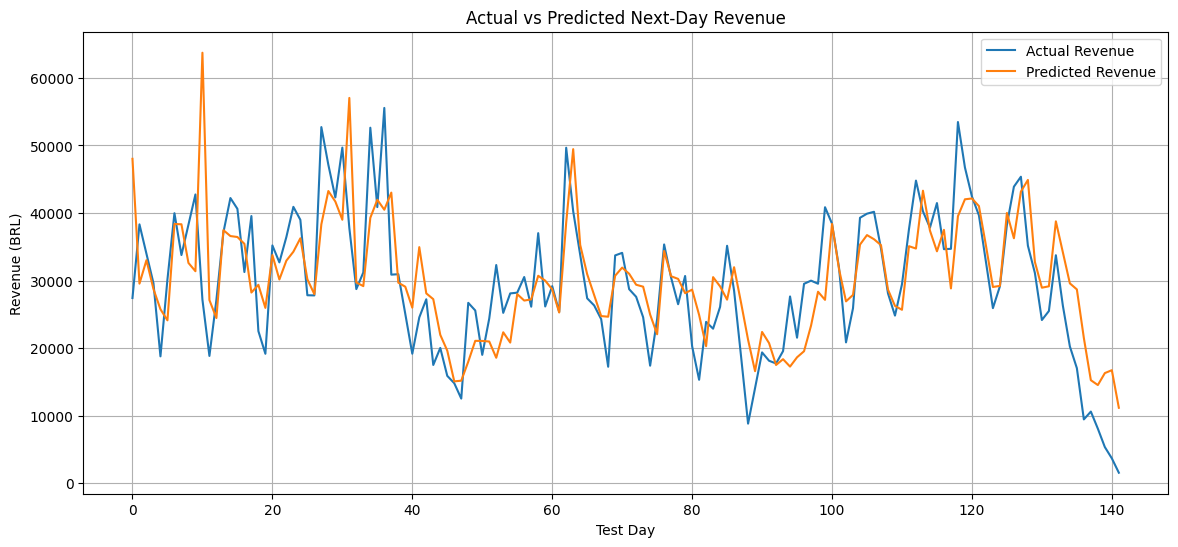

In [146]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.plot(
    y_test.values,
    label="Actual Revenue"
)

plt.plot(
    rf_daily_predictions,
    label="Predicted Revenue"
)

plt.title("Actual vs Predicted Next-Day Revenue")
plt.xlabel("Test Day")
plt.ylabel("Revenue (BRL)")
plt.legend()
plt.grid(True)

plt.show()

In [147]:
error_analysis = pd.DataFrame({
    "Actual_Revenue": y_test.values,
    "Predicted_Revenue": rf_daily_predictions
})

error_analysis["Error"] = (
    error_analysis["Actual_Revenue"]
    - error_analysis["Predicted_Revenue"]
)

error_analysis["Absolute_Error"] = (
    error_analysis["Error"].abs()
)

error_analysis["Percentage_Error"] = (
    error_analysis["Absolute_Error"]
    / np.where(
        error_analysis["Actual_Revenue"] == 0,
        1,
        error_analysis["Actual_Revenue"]
    )
) * 100

error_analysis.head(10)

,Actual_Revenue,Predicted_Revenue,Error,Absolute_Error,Percentage_Error
0,27416.11,48026.564318,-20610.454318,20610.454318,75.176436
1,38318.13,29542.088837,8776.041163,8776.041163,22.903104
2,33952.78,33023.330009,929.449991,929.449991,2.737478
3,29605.91,28745.689600,860.220400,860.220400,2.905570
4,18776.70,25753.082572,-6976.382572,6976.382572,37.154466
5,30171.31,24110.542655,6060.767345,6060.767345,20.087849
6,39973.23,38376.426309,1596.803691,1596.803691,3.994683
7,33777.37,38335.768996,-4558.398996,4558.398996,13.495423
8,38231.89,32613.964492,5617.925508,5617.925508,14.694344
9,42749.34,31382.878478,11366.461522,11366.461522,26.588625


In [148]:
top_errors = (
    error_analysis
    .sort_values("Absolute_Error", ascending=False)
    .head(10)
    .copy()
)

top_errors

,Actual_Revenue,Predicted_Revenue,Error,Absolute_Error,Percentage_Error
10,27176.04,63737.579691,-36561.539691,36561.539691,134.535936
0,27416.11,48026.564318,-20610.454318,20610.454318,75.176436
31,37785.29,57043.046537,-19257.756537,19257.756537,50.966280
36,55562.13,40488.494754,15073.635246,15073.635246,27.129333
27,52726.03,38328.701340,14397.328660,14397.328660,27.305922
118,53475.41,39528.062724,13947.347276,13947.347276,26.081796
52,32298.92,18568.995760,13729.924240,13729.924240,42.508927
99,40860.90,27144.339504,13716.560496,13716.560496,33.568914
34,52633.10,39290.948403,13342.151597,13342.151597,25.349355
140,3673.91,16729.064327,-13055.154327,13055.154327,355.347690


In [149]:
import joblib

joblib.dump(
    rf_daily_model,
    "../models/daily_revenue_forecast_model.pkl"
)

print("Model saved successfully!")

Model saved successfully!


In [150]:
business_data = sales_customer_data.merge(
    products[[
        "product_id",
        "product_category_name"
    ]],
    on="product_id",
    how="left"
)

print("Business Dataset Shape:", business_data.shape)

business_data.head()

Business Dataset Shape: (110197, 13)


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,order_status,order_purchase_timestamp,month,customer_id,customer_unique_id,product_category_name
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,delivered,2017-09-13 08:59:02,2017-09,3ce436f183e68e07877b285a838db11a,871766c5855e863f6eccc05f988b23cb,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,delivered,2017-04-26 10:53:06,2017-04,f6dd3ec061db4e3987629fe6b26e5cce,eb28e67c4c0b83846050ddfb8a35d051,pet_shop
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,delivered,2018-01-14 14:33:31,2018-01,6489ae5e4333f3693df5ad4372dab6d3,3818d81c6709e39d06b2738a8d3a2474,moveis_decoracao
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,delivered,2018-08-08 10:00:35,2018-08,d4eb9395c8c0431ee92fce09860c5a06,af861d436cfc08b2c2ddefd0ba074622,perfumaria
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,delivered,2017-02-04 13:57:51,2017-02,58dbd0b2d70206bf40e62cd34e84d795,64b576fb70d441e8f1b2d7d446e483c5,ferramentas_jardim


In [151]:
print("Missing Values:")
print(business_data.isnull().sum())

print("\nDuplicate Rows:")
print(business_data.duplicated().sum())

Missing Values:
order_id                       0
order_item_id                  0
product_id                     0
seller_id                      0
shipping_limit_date            0
price                          0
freight_value                  0
order_status                   0
order_purchase_timestamp       0
month                          0
customer_id                    0
customer_unique_id             0
product_category_name       1537
dtype: int64

Duplicate Rows:
0


In [152]:
business_data["product_category_name"] = (
    business_data["product_category_name"]
    .fillna("Unknown")
)

print("Missing Values After Cleaning:")
print(business_data["product_category_name"].isnull().sum())

print("\nCategory Counts:")
print(business_data["product_category_name"].value_counts().head(10))

Missing Values After Cleaning:
0

Category Counts:
product_category_name
cama_mesa_banho           10953
beleza_saude               9465
esporte_lazer              8431
moveis_decoracao           8160
informatica_acessorios     7644
utilidades_domesticas      6795
relogios_presentes         5859
telefonia                  4430
ferramentas_jardim         4268
automotivo                 4140
Name: count, dtype: int64


In [153]:
total_revenue = business_data["price"].sum()

total_orders = business_data["order_id"].nunique()

total_units = business_data["order_item_id"].count()

average_order_value = (
    total_revenue / total_orders
)

print("===== BUSINESS KPIs =====")
print("Total Revenue:", round(total_revenue, 2), "BRL")
print("Total Orders:", total_orders)
print("Total Units Sold:", total_units)
print("Average Order Value:", round(average_order_value, 2), "BRL")

===== BUSINESS KPIs =====
Total Revenue: 13221498.11 BRL
Total Orders: 96478
Total Units Sold: 110197
Average Order Value: 137.04 BRL


In [154]:
category_kpi = (
    business_data
    .groupby("product_category_name")
    .agg(
        revenue=("price", "sum"),
        units_sold=("order_item_id", "count"),
        orders=("order_id", "nunique")
    )
    .reset_index()
    .sort_values("revenue", ascending=False)
)

category_kpi.head(10)

,product_category_name,revenue,units_sold,orders
12,beleza_saude,1233131.72,9465,8647
67,relogios_presentes,1166176.98,5859,5495
14,cama_mesa_banho,1023434.76,10953,9272
33,esporte_lazer,954852.55,8431,7530
45,informatica_acessorios,888724.61,7644,6530
55,moveis_decoracao,711927.69,8160,6307
73,utilidades_domesticas,615628.69,6795,5743
27,cool_stuff,610204.10,3718,3559
9,automotivo,578966.65,4140,3810
13,brinquedos,471286.48,4030,3804


In [155]:
category_kpi["revenue_share_pct"] = (
    category_kpi["revenue"]
    / category_kpi["revenue"].sum()
) * 100

category_kpi = category_kpi.sort_values(
    "revenue",
    ascending=False
)

category_kpi.head(10)


,product_category_name,revenue,units_sold,orders,revenue_share_pct
12,beleza_saude,1233131.72,9465,8647,9.326717
67,relogios_presentes,1166176.98,5859,5495,8.820309
14,cama_mesa_banho,1023434.76,10953,9272,7.740687
33,esporte_lazer,954852.55,8431,7530,7.221969
45,informatica_acessorios,888724.61,7644,6530,6.721815
55,moveis_decoracao,711927.69,8160,6307,5.384622
73,utilidades_domesticas,615628.69,6795,5743,4.656270
27,cool_stuff,610204.10,3718,3559,4.615242
9,automotivo,578966.65,4140,3810,4.378979
13,brinquedos,471286.48,4030,3804,3.564547


In [156]:
monthly_business = (
    business_data
    .groupby(
        business_data["order_purchase_timestamp"].dt.to_period("M").astype(str)
    )
    .agg(
        revenue=("price", "sum"),
        units_sold=("order_item_id", "count"),
        orders=("order_id", "nunique")
    )
    .reset_index()
)

monthly_business.columns = [
    "month",
    "revenue",
    "units_sold",
    "orders"
]

monthly_business = monthly_business.sort_values("month")

monthly_business.head(10)

,month,revenue,units_sold,orders
0,2016-09,134.97,3,1
1,2016-10,40325.11,313,265
2,2016-12,10.90,1,1
3,2017-01,111798.36,913,750
4,2017-02,234223.40,1858,1653
5,2017-03,359198.85,2897,2546
6,2017-04,340669.68,2569,2303
7,2017-05,489338.25,4004,3546
8,2017-06,421923.37,3489,3135
9,2017-07,481604.52,4416,3872


In [157]:
monthly_business["revenue_growth_pct"] = (
    monthly_business["revenue"]
    .pct_change()
    .replace([float("inf"), -float("inf")], pd.NA)
    * 100
)

monthly_business.head(15)

,month,revenue,units_sold,orders,revenue_growth_pct
0,2016-09,134.97,3,1,NaN
1,2016-10,40325.11,313,265,2.977709e+04
2,2016-12,10.90,1,1,-9.997297e+01
3,2017-01,111798.36,913,750,1.025573e+06
4,2017-02,234223.40,1858,1653,1.095052e+02
5,2017-03,359198.85,2897,2546,5.335737e+01
6,2017-04,340669.68,2569,2303,-5.158471e+00
7,2017-05,489338.25,4004,3546,4.364009e+01
8,2017-06,421923.37,3489,3135,-1.377674e+01
9,2017-07,481604.52,4416,3872,1.414502e+01


In [158]:
monthly_business["month"] = pd.to_datetime(
    monthly_business["month"]
)

all_months = pd.date_range(
    start=monthly_business["month"].min(),
    end=monthly_business["month"].max(),
    freq="MS"
)

monthly_business = (
    monthly_business
    .set_index("month")
    .reindex(all_months)
    .reset_index()
)

monthly_business = monthly_business.rename(
    columns={"index": "month"}
)

monthly_business[
    ["revenue", "units_sold", "orders"]
] = monthly_business[
    ["revenue", "units_sold", "orders"]
].fillna(0)

print("Monthly Dataset Shape:", monthly_business.shape)

monthly_business.head(15)

Monthly Dataset Shape: (24, 5)


,month,revenue,units_sold,orders,revenue_growth_pct
0,2016-09-01,134.97,3.0,1.0,NaN
1,2016-10-01,40325.11,313.0,265.0,2.977709e+04
2,2016-11-01,0.00,0.0,0.0,NaN
3,2016-12-01,10.90,1.0,1.0,-9.997297e+01
4,2017-01-01,111798.36,913.0,750.0,1.025573e+06
5,2017-02-01,234223.40,1858.0,1653.0,1.095052e+02
6,2017-03-01,359198.85,2897.0,2546.0,5.335737e+01
7,2017-04-01,340669.68,2569.0,2303.0,-5.158471e+00
8,2017-05-01,489338.25,4004.0,3546.0,4.364009e+01
9,2017-06-01,421923.37,3489.0,3135.0,-1.377674e+01


In [159]:

id="correct_growth"

previous_revenue = monthly_business["revenue"].shift(1)

monthly_business["revenue_growth_pct"] = np.where(
    previous_revenue > 0,
    ((monthly_business["revenue"] - previous_revenue) / previous_revenue) * 100,
    np.nan
)

monthly_business[
    ["month", "revenue", "revenue_growth_pct"]
].head(15)

,month,revenue,revenue_growth_pct
0,2016-09-01,134.97,NaN
1,2016-10-01,40325.11,2.977709e+04
2,2016-11-01,0.00,-1.000000e+02
3,2016-12-01,10.90,NaN
4,2017-01-01,111798.36,1.025573e+06
5,2017-02-01,234223.40,1.095052e+02
6,2017-03-01,359198.85,5.335737e+01
7,2017-04-01,340669.68,-5.158471e+00
8,2017-05-01,489338.25,4.364009e+01
9,2017-06-01,421923.37,-1.377674e+01


In [160]:

stable_growth = monthly_business[
    monthly_business["month"] >= "2017-02-01"
].copy()

print("Stable Growth Analysis:")
print(stable_growth[
    ["month", "revenue", "revenue_growth_pct"]
].head(15))

Stable Growth Analysis:
        month    revenue  revenue_growth_pct
5  2017-02-01  234223.40          109.505220
6  2017-03-01  359198.85           53.357372
7  2017-04-01  340669.68           -5.158471
8  2017-05-01  489338.25           43.640094
9  2017-06-01  421923.37          -13.776744
10 2017-07-01  481604.52           14.145021
11 2017-08-01  554699.70           15.177428
12 2017-09-01  607399.67            9.500631
13 2017-10-01  648247.65            6.725058
14 2017-11-01  987765.37           52.374694
15 2017-12-01  726033.19          -26.497404
16 2018-01-01  924645.00           27.355748
17 2018-02-01  826437.13          -10.621143
18 2018-03-01  953356.25           15.357384
19 2018-04-01  973534.09            2.116506


In [161]:
def revenue_growth_insight(growth):
    if pd.isna(growth):
        return "Not enough data"

    elif growth > 10:
        return "Strong revenue growth"

    elif growth < -10:
        return "Significant revenue decline"

    else:
        return "Revenue remained relatively stable"


monthly_business["revenue_insight"] = (
    monthly_business["revenue_growth_pct"]
    .apply(revenue_growth_insight)
)

monthly_business[
    [
        "month",
        "revenue",
        "revenue_growth_pct",
        "revenue_insight"
    ]
].tail(15)

,month,revenue,revenue_growth_pct,revenue_insight
9,2017-06-01,421923.37,-13.776744,Significant revenue decline
10,2017-07-01,481604.52,14.145021,Strong revenue growth
11,2017-08-01,554699.70,15.177428,Strong revenue growth
12,2017-09-01,607399.67,9.500631,Revenue remained relatively stable
13,2017-10-01,648247.65,6.725058,Revenue remained relatively stable
14,2017-11-01,987765.37,52.374694,Strong revenue growth
15,2017-12-01,726033.19,-26.497404,Significant revenue decline
16,2018-01-01,924645.00,27.355748,Strong revenue growth
17,2018-02-01,826437.13,-10.621143,Significant revenue decline
18,2018-03-01,953356.25,15.357384,Strong revenue growth


In [162]:
monthly_business["previous_orders"] = (
    monthly_business["orders"].shift(1)
)

monthly_business["previous_units"] = (
    monthly_business["units_sold"].shift(1)
)

monthly_business["order_growth_pct"] = np.where(
    monthly_business["previous_orders"] > 0,
    (
        (monthly_business["orders"] - monthly_business["previous_orders"])
        / monthly_business["previous_orders"]
    ) * 100,
    np.nan
)

monthly_business["unit_growth_pct"] = np.where(
    monthly_business["previous_units"] > 0,
    (
        (monthly_business["units_sold"] - monthly_business["previous_units"])
        / monthly_business["previous_units"]
    ) * 100,
    np.nan
)

monthly_business[
    [
        "month",
        "revenue",
        "revenue_growth_pct",
        "orders",
        "order_growth_pct",
        "units_sold",
        "unit_growth_pct"
    ]
].tail(15)

,month,revenue,revenue_growth_pct,orders,order_growth_pct,units_sold,unit_growth_pct
9,2017-06-01,421923.37,-13.776744,3135.0,-11.590525,3489.0,-12.862138
10,2017-07-01,481604.52,14.145021,3872.0,23.508772,4416.0,26.569218
11,2017-08-01,554699.70,15.177428,4193.0,8.290289,4797.0,8.627717
12,2017-09-01,607399.67,9.500631,4150.0,-1.025519,4737.0,-1.250782
13,2017-10-01,648247.65,6.725058,4478.0,7.903614,5214.0,10.069664
14,2017-11-01,987765.37,52.374694,7289.0,62.773560,8475.0,62.543153
15,2017-12-01,726033.19,-26.497404,5513.0,-24.365482,6187.0,-26.997050
16,2018-01-01,924645.00,27.355748,7069.0,28.224197,8037.0,29.901406
17,2018-02-01,826437.13,-10.621143,6555.0,-7.271184,7518.0,-6.457633
18,2018-03-01,953356.25,15.357384,7003.0,6.834477,8017.0,6.637404


In [163]:
def generate_business_insight(row):

    revenue_growth = row["revenue_growth_pct"]
    order_growth = row["order_growth_pct"]
    unit_growth = row["unit_growth_pct"]

    if pd.isna(revenue_growth):
        return "Not enough data"

    if revenue_growth > 10 and order_growth > 10 and unit_growth > 10:
        return "Strong business growth: revenue, orders, and units all increased"

    elif revenue_growth < -10 and order_growth < -10 and unit_growth < -10:
        return "Significant business decline: revenue, orders, and units all decreased"

    elif revenue_growth > 10 and order_growth <= 0:
        return "Revenue increased despite flat or declining orders"

    elif revenue_growth < -10 and order_growth > 0:
        return "Revenue declined despite order growth"

    elif revenue_growth > 10:
        return "Revenue increased with positive business activity"

    elif revenue_growth < -10:
        return "Revenue declined and requires investigation"

    else:
        return "Business performance remained relatively stable"


monthly_business["business_insight"] = (
    monthly_business.apply(generate_business_insight, axis=1)
)

print(
    monthly_business[
        [
            "month",
            "revenue_growth_pct",
            "order_growth_pct",
            "unit_growth_pct",
            "business_insight"
        ]
    ].tail(15).to_string(index=False)
)

     month  revenue_growth_pct  order_growth_pct  unit_growth_pct                                                       business_insight
2017-06-01          -13.776744        -11.590525       -12.862138 Significant business decline: revenue, orders, and units all decreased
2017-07-01           14.145021         23.508772        26.569218       Strong business growth: revenue, orders, and units all increased
2017-08-01           15.177428          8.290289         8.627717                      Revenue increased with positive business activity
2017-09-01            9.500631         -1.025519        -1.250782                        Business performance remained relatively stable
2017-10-01            6.725058          7.903614        10.069664                        Business performance remained relatively stable
2017-11-01           52.374694         62.773560        62.543153       Strong business growth: revenue, orders, and units all increased
2017-12-01          -26.497404        -24

In [164]:
monthly_category_revenue = (
    business_data.groupby(
        [
            business_data["order_purchase_timestamp"].dt.to_period("M").astype(str),
            "product_category_name"
        ]
    )["price"]
    .sum()
    .reset_index()
)

monthly_category_revenue.columns = [
    "month",
    "category",
    "revenue"
]

monthly_category_revenue = (
    monthly_category_revenue
    .sort_values(["month", "revenue"], ascending=[True, False])
)

monthly_category_revenue.head(20)

,month,category,revenue
0,2016-09,beleza_saude,134.97
23,2016-10,moveis_decoracao,5690.52
25,2016-10,perfumaria,4829.10
7,2016-10,brinquedos,4106.50
10,2016-10,consoles_games,3619.36
6,2016-10,beleza_saude,3439.25
27,2016-10,relogios_presentes,2711.07
13,2016-10,esporte_lazer,2012.15
5,2016-10,bebes,1371.17
18,2016-10,ferramentas_jardim,1359.88


In [165]:
may_june = monthly_category_revenue[
    monthly_category_revenue["month"].isin(["2018-05", "2018-06"])
].copy()

category_comparison = (
    may_june
    .pivot(
        index="category",
        columns="month",
        values="revenue"
    )
    .fillna(0)
    .reset_index()
)

category_comparison["revenue_change"] = (
    category_comparison.get("2018-06", 0)
    - category_comparison.get("2018-05", 0)
)

category_comparison["revenue_change_pct"] = np.where(
    category_comparison["2018-05"] > 0,
    (
        category_comparison["revenue_change"]
        / category_comparison["2018-05"]
    ) * 100,
    np.nan
)

category_comparison = category_comparison.sort_values(
    "revenue_change"
)

category_comparison.head(15)

month,category,2018-05,2018-06,revenue_change,revenue_change_pct
61,relogios_presentes,119364.98,85027.57,-34337.41,-28.766737
38,ferramentas_jardim,37700.79,17948.72,-19752.07,-52.391661
32,esporte_lazer,59209.92,44916.01,-14293.91,-24.141073
50,moveis_decoracao,53706.45,42042.22,-11664.23,-21.718490
26,cool_stuff,29949.12,19316.37,-10632.75,-35.502713
13,brinquedos,31538.41,21094.95,-10443.46,-33.113464
42,informatica_acessorios,50631.83,41806.37,-8825.46,-17.430656
51,moveis_escritorio,20835.87,12125.58,-8710.29,-41.804302
66,utilidades_domesticas,62824.57,55912.61,-6911.96,-11.002001
59,portateis_casa_forno_e_cafe,10161.60,3499.00,-6662.60,-65.566446


In [166]:
def analyze_revenue_change(month, comparison_df):

    current = comparison_df[
        comparison_df["month"] == month
    ]

    if current.empty:
        return "Month not found"

    current_revenue = current["revenue"].sum()

    previous_month = (
        pd.to_datetime(month + "-01")
        - pd.DateOffset(months=1)
    ).strftime("%Y-%m")

    previous = comparison_df[
        comparison_df["month"] == previous_month
    ]

    if previous.empty:
        return "Previous month data not available"

    previous_revenue = previous["revenue"].sum()

    revenue_change = current_revenue - previous_revenue

    revenue_change_pct = (
        revenue_change / previous_revenue
    ) * 100 if previous_revenue > 0 else np.nan

    category_data = comparison_df[
        comparison_df["month"].isin([previous_month, month])
    ]

    comparison = (
        category_data
        .pivot(
            index="category",
            columns="month",
            values="revenue"
        )
        .fillna(0)
    )

    comparison["change"] = (
        comparison.get(month, 0)
        - comparison.get(previous_month, 0)
    )

    if revenue_change < 0:
        drivers = comparison.sort_values(
            "change"
        ).head(5)

        print(f"Revenue decreased by {abs(revenue_change_pct):.2f}%")
        print("Top revenue decline categories:")
        print(drivers["change"])

    else:
        drivers = comparison.sort_values(
            "change",
            ascending=False
        ).head(5)

        print(f"Revenue increased by {revenue_change_pct:.2f}%")
        print("Top revenue growth categories:")
        print(drivers["change"])

In [167]:
analyze_revenue_change(
    "2018-06",
    monthly_category_revenue
)

Revenue decreased by 12.43%
Top revenue decline categories:
category
relogios_presentes   -34337.41
ferramentas_jardim   -19752.07
esporte_lazer        -14293.91
moveis_decoracao     -11664.23
cool_stuff           -10632.75
Name: change, dtype: float64


In [168]:
def generate_revenue_explanation(month, comparison_df):

    current = comparison_df[
        comparison_df["month"] == month
    ]

    previous_month = (
        pd.to_datetime(month + "-01")
        - pd.DateOffset(months=1)
    ).strftime("%Y-%m")

    previous = comparison_df[
        comparison_df["month"] == previous_month
    ]

    if current.empty or previous.empty:
        return "Insufficient data for analysis."

    current_revenue = current["revenue"].sum()
    previous_revenue = previous["revenue"].sum()

    change_pct = (
        (current_revenue - previous_revenue)
        / previous_revenue
    ) * 100

    category_data = comparison_df[
        comparison_df["month"].isin([previous_month, month])
    ]

    comparison = (
        category_data
        .pivot(
            index="category",
            columns="month",
            values="revenue"
        )
        .fillna(0)
    )

    comparison["change"] = (
        comparison.get(month, 0)
        - comparison.get(previous_month, 0)
    )

    if change_pct < 0:

        top_categories = (
            comparison
            .sort_values("change")
            .head(3)
        )

        category_text = ", ".join(
            top_categories.index
        )

        return (
            f"Revenue decreased by {abs(change_pct):.2f}% "
            f"in {month}. The main decline contributors were "
            f"{category_text}."
        )

    else:

        top_categories = (
            comparison
            .sort_values("change", ascending=False)
            .head(3)
        )

        category_text = ", ".join(
            top_categories.index
        )

        return (
            f"Revenue increased by {change_pct:.2f}% "
            f"in {month}. The main growth contributors were "
            f"{category_text}."
        )

In [169]:
print(
    generate_revenue_explanation(
        "2018-06",
        monthly_category_revenue
    )
)

Revenue decreased by 12.43% in 2018-06. The main decline contributors were relogios_presentes, ferramentas_jardim, esporte_lazer.


In [170]:
monthly_customer = (
    business_data.groupby(
        business_data["order_purchase_timestamp"].dt.to_period("M").astype(str)
    )
    .agg(
        revenue=("price", "sum"),
        orders=("order_id", "nunique"),
        customers=("customer_unique_id", "nunique")
    )
    .reset_index()
)

monthly_customer.columns = [
    "month",
    "revenue",
    "orders",
    "customers"
]

monthly_customer = monthly_customer.sort_values("month")

monthly_customer["revenue_per_customer"] = (
    monthly_customer["revenue"]
    / monthly_customer["customers"]
)

monthly_customer.tail(15)

,month,revenue,orders,customers,revenue_per_customer
8,2017-06,421923.37,3135,3076,137.166245
9,2017-07,481604.52,3872,3802,126.671362
10,2017-08,554699.70,4193,4114,134.832207
11,2017-09,607399.67,4150,4083,148.763084
12,2017-10,648247.65,4478,4417,146.761976
13,2017-11,987765.37,7289,7183,137.514321
14,2017-12,726033.19,5513,5450,133.217099
15,2018-01,924645.00,7069,6974,132.584600
16,2018-02,826437.13,6555,6400,129.130802
17,2018-03,953356.25,7003,6914,137.887800


In [171]:
monthly_customer["previous_customers"] = (
    monthly_customer["customers"].shift(1)
)

monthly_customer["customer_growth_pct"] = np.where(
    monthly_customer["previous_customers"] > 0,
    (
        (monthly_customer["customers"] - monthly_customer["previous_customers"])
        / monthly_customer["previous_customers"]
    ) * 100,
    np.nan
)

monthly_customer["revenue_per_customer_growth_pct"] = (
    monthly_customer["revenue_per_customer"]
    .pct_change() * 100
)

monthly_customer[
    [
        "month",
        "revenue",
        "customers",
        "customer_growth_pct",
        "revenue_per_customer",
        "revenue_per_customer_growth_pct"
    ]
].tail(15)

,month,revenue,customers,customer_growth_pct,revenue_per_customer,revenue_per_customer_growth_pct
8,2017-06,421923.37,3076,-11.583788,137.166245,-2.480265
9,2017-07,481604.52,3802,23.602081,126.671362,-7.651214
10,2017-08,554699.70,4114,8.206207,134.832207,6.442533
11,2017-09,607399.67,4083,-0.753525,148.763084,10.332009
12,2017-10,648247.65,4417,8.180260,146.761976,-1.345164
13,2017-11,987765.37,7183,62.621689,137.514321,-6.301125
14,2017-12,726033.19,5450,-24.126410,133.217099,-3.124927
15,2018-01,924645.00,6974,27.963303,132.584600,-0.474788
16,2018-02,826437.13,6400,-8.230571,129.130802,-2.604977
17,2018-03,953356.25,6914,8.031250,137.887800,6.781495


In [172]:

def generate_business_diagnosis(month):

    # Overall business data
    business_row = monthly_business[
        monthly_business["month"] == pd.to_datetime(month + "-01")
    ]

    customer_row = monthly_customer[
        monthly_customer["month"] == month
    ]

    if business_row.empty or customer_row.empty:
        return "Data not available"

    revenue_growth = business_row["revenue_growth_pct"].iloc[0]
    customer_growth = customer_row["customer_growth_pct"].iloc[0]
    rpc_growth = customer_row[
        "revenue_per_customer_growth_pct"
    ].iloc[0]

    # Category comparison
    current_month = monthly_category_revenue[
        monthly_category_revenue["month"] == month
    ]

    previous_month = (
        pd.to_datetime(month + "-01")
        - pd.DateOffset(months=1)
    ).strftime("%Y-%m")

    previous_data = monthly_category_revenue[
        monthly_category_revenue["month"] == previous_month
    ]

    category_data = pd.concat(
        [previous_data, current_month]
    )

    comparison = (
        category_data
        .pivot(
            index="category",
            columns="month",
            values="revenue"
        )
        .fillna(0)
    )

    comparison["change"] = (
        comparison.get(month, 0)
        - comparison.get(previous_month, 0)
    )

    top_categories = (
        comparison
        .sort_values("change")
        .head(3)
        .index
        .tolist()
    )

    categories_text = ", ".join(top_categories)

    # Generate diagnosis
    if revenue_growth < -10:

        if customer_growth < 0 and rpc_growth < 0:

            diagnosis = (
                f"Revenue declined by {abs(revenue_growth):.2f}% in {month}. "
                f"Customer count decreased by {abs(customer_growth):.2f}% "
                f"and revenue per customer decreased by "
                f"{abs(rpc_growth):.2f}%. "
                f"The main category decline contributors were "
                f"{categories_text}."
            )

        elif customer_growth < 0:

            diagnosis = (
                f"Revenue declined by {abs(revenue_growth):.2f}% in {month}. "
                f"Customer activity decreased by {abs(customer_growth):.2f}%. "
                f"The main category decline contributors were "
                f"{categories_text}."
            )

        else:

            diagnosis = (
                f"Revenue declined by {abs(revenue_growth):.2f}% in {month}, "
                f"while customer activity increased. "
                f"The main category decline contributors were "
                f"{categories_text}."
            )

    else:

        diagnosis = (
            f"Revenue performance was positive in {month}, "
            f"with growth of {revenue_growth:.2f}%."
        )

    return diagnosis

In [173]:

print(
    generate_business_diagnosis("2018-06")
)

Revenue declined by 12.43% in 2018-06. Customer count decreased by 9.44% and revenue per customer decreased by 3.29%. The main category decline contributors were relogios_presentes, ferramentas_jardim, esporte_lazer.


In [174]:

def generate_business_recommendation(month):

    customer_row = monthly_customer[
        monthly_customer["month"] == month
    ]

    business_row = monthly_business[
        monthly_business["month"] == pd.to_datetime(month + "-01")
    ]

    if customer_row.empty or business_row.empty:
        return "Data not available"

    customer_growth = customer_row["customer_growth_pct"].iloc[0]
    rpc_growth = customer_row[
        "revenue_per_customer_growth_pct"
    ].iloc[0]
    revenue_growth = business_row[
        "revenue_growth_pct"
    ].iloc[0]

    recommendations = []

    if revenue_growth < -10:
        recommendations.append(
            "Investigate the main causes of the revenue decline."
        )

    if customer_growth < -5:
        recommendations.append(
            "Focus on customer acquisition and retention."
        )

    if rpc_growth < -5:
        recommendations.append(
            "Review product mix, pricing, and cross-selling opportunities "
            "to improve revenue per customer."
        )

    if revenue_growth > 10:
        recommendations.append(
            "Identify the products and categories driving growth "
            "and consider increasing their availability."
        )

    if not recommendations:
        recommendations.append(
            "Continue monitoring performance and identify emerging trends."
        )

    return " ".join(recommendations)

In [175]:

print(
    generate_business_recommendation("2018-06")
)

Investigate the main causes of the revenue decline. Focus on customer acquisition and retention.


In [176]:

def generate_copilot_response(month):

    diagnosis = generate_business_diagnosis(month)
    recommendation = generate_business_recommendation(month)

    return f"""
📊 Business Diagnosis — {month}

{diagnosis}

💡 Recommended Actions

{recommendation}
"""


print(generate_copilot_response("2018-06"))


📊 Business Diagnosis — 2018-06

Revenue declined by 12.43% in 2018-06. Customer count decreased by 9.44% and revenue per customer decreased by 3.29%. The main category decline contributors were relogios_presentes, ferramentas_jardim, esporte_lazer.

💡 Recommended Actions

Investigate the main causes of the revenue decline. Focus on customer acquisition and retention.



In [177]:

def get_top_categories(n=5):

    top_categories = (
        category_kpi
        .sort_values("revenue", ascending=False)
        .head(n)
    )

    result = []

    for _, row in top_categories.iterrows():

        result.append(
            f"{row['product_category_name']}: "
            f"{row['revenue']:,.2f} BRL"
        )

    return "\n".join(result)


print("🏆 Top 5 Revenue Categories\n")
print(get_top_categories())

🏆 Top 5 Revenue Categories

beleza_saude: 1,233,131.72 BRL
relogios_presentes: 1,166,176.98 BRL
cama_mesa_banho: 1,023,434.76 BRL
esporte_lazer: 954,852.55 BRL
informatica_acessorios: 888,724.61 BRL


In [178]:
def get_customer_segments():

    segment_summary = (
        customer_rfm
        .groupby("customer_segment")
        .size()
        .reset_index(name="customer_count")
        .sort_values("customer_count", ascending=False)
    )

    return segment_summary


print("👥 Customer Segments\n")
print(get_customer_segments())

👥 Customer Segments

  customer_segment  customer_count
3  Potential Loyal           38521
2            Loyal           31260
0          At Risk           12434
4              VIP            7894
1             Lost            3249


In [179]:
def get_risky_sellers(n=10):

    risky = (
        risk_sellers
        .sort_values("late_rate", ascending=False)
        .head(n)
    )

    result = []

    for _, row in risky.iterrows():

        result.append(
            f"Seller: {row['seller_id']} | "
            f"Revenue: {row['total_revenue']:,.2f} BRL | "
            f"Late Rate: {row['late_rate']:.2f}% | "
            f"Delivered Orders: {int(row['delivered_orders'])}"
        )

    return "\n".join(result)


print("⚠️ Risky Sellers\n")
print(get_risky_sellers())

⚠️ Risky Sellers

Seller: b1b3948701c5c72445495bd161b83a4c | Revenue: 24,699.19 BRL | Late Rate: 64.29% | Delivered Orders: 14
Seller: cb41bfbcbda0aea354a834ab222f9a59 | Revenue: 4,002.00 BRL | Late Rate: 36.36% | Delivered Orders: 11
Seller: 821fb029fc6e495ca4f08a35d51e53a5 | Revenue: 19,187.42 BRL | Late Rate: 33.33% | Delivered Orders: 24
Seller: b19f3ca2ea475913750f25a5c37c8d8f | Revenue: 6,202.91 BRL | Late Rate: 31.58% | Delivered Orders: 19
Seller: ad781527c93d00d89a11eecd9dcad7c1 | Revenue: 6,899.57 BRL | Late Rate: 31.58% | Delivered Orders: 38
Seller: 54965bbe3e4f07ae045b90b0b8541f52 | Revenue: 10,961.30 BRL | Late Rate: 30.14% | Delivered Orders: 73
Seller: 7f152321c60a266edc53af1925ef96c1 | Revenue: 3,919.80 BRL | Late Rate: 30.00% | Delivered Orders: 20
Seller: 054694fa03fe82cec4b7551487331d74 | Revenue: 9,983.10 BRL | Late Rate: 30.00% | Delivered Orders: 20
Seller: c4d51195486dc781531876a7d00453d8 | Revenue: 11,468.98 BRL | Late Rate: 29.41% | Delivered Orders: 17
Seller

In [180]:
def ask_business_copilot(question):

    question = question.lower()

    # Seller questions
    if (
        "seller" in question
        and (
            "risk" in question
            or "risky" in question
            or "late" in question
        )
    ):

        return (
            "⚠️ Top Risky Sellers\n\n"
            + get_risky_sellers()
        )

    # Customer questions
    elif (
        "customer" in question
        and (
            "segment" in question
            or "vip" in question
            or "loyal" in question
            or "at risk" in question
        )
    ):

        segments = get_customer_segments()

        return (
            "👥 Customer Intelligence\n\n"
            + segments.to_string(index=False)
        )

    # Category questions
    elif (
        "category" in question
        and (
            "most revenue" in question
            or "top category" in question
            or "highest revenue" in question
        )
    ):

        return (
            "🏆 Top 5 Revenue Categories\n\n"
            + get_top_categories()
        )

    # Revenue questions
    elif "revenue" in question:

        import re

        match = re.search(
            r"(20\d{2})[-/](\d{1,2})",
            question
        )

        if match:

            year = match.group(1)
            month = match.group(2).zfill(2)

            selected_month = f"{year}-{month}"

        else:

            return (
                "Please specify a month and year. "
                "Example: Why did revenue decline in February 2018?"
            )

        available_months = (
            monthly_business["month"]
            .dt.strftime("%Y-%m")
            .tolist()
        )

        if selected_month not in available_months:

            return f"No data available for {selected_month}."

        return generate_copilot_response(selected_month)

    else:

        return (
            "🤖 I can currently answer questions about "
            "revenue, categories, customers, and sellers."
        )


question = input("Ask your Business Copilot: ")

print("\n🤖 AI Business Copilot\n")
print(ask_business_copilot(question))


🤖 AI Business Copilot

🤖 I can currently answer questions about revenue, categories, customers, and sellers.


In [181]:
# ==========================================
# MASTER AI BUSINESS COPILOT
# ==========================================

def master_copilot(question):

    question = question.lower().strip()

    # 1. Seller Intelligence
    if "seller" in question and (
        "risk" in question
        or "risky" in question
        or "late" in question
    ):
        return (
            "⚠️ Top Risky Sellers\n\n"
            + get_risky_sellers()
        )

    # 2. Customer Intelligence
    elif "customer" in question and (
        "segment" in question
        or "vip" in question
        or "loyal" in question
        or "at risk" in question
    ):
        return (
            "👥 Customer Intelligence\n\n"
            + get_customer_segments().to_string(index=False)
        )

    # 3. Category Intelligence
    elif "category" in question and (
        "most revenue" in question
        or "top category" in question
        or "highest revenue" in question
    ):
        return (
            "🏆 Top 5 Revenue Categories\n\n"
            + get_top_categories()
        )

    # 4. Revenue Intelligence
    elif "revenue" in question:

        import re

        match = re.search(
            r"(20\d{2})[-/](\d{1,2})",
            question
        )

        if match:

            year = match.group(1)
            month = match.group(2).zfill(2)

            selected_month = f"{year}-{month}"

            available_months = (
                monthly_business["month"]
                .dt.strftime("%Y-%m")
                .tolist()
            )

            if selected_month not in available_months:
                return f"No data available for {selected_month}."

            return generate_copilot_response(selected_month)

        else:

            return (
                "Please specify month and year.\n"
                "Example: Why did revenue decline in February 2018?"
            )

    # 5. Unknown question
    else:

        return (
            "🤖 I can currently answer questions about:\n\n"
            "📉 Revenue\n"
            "🏆 Categories\n"
            "👥 Customers\n"
            "⚠️ Sellers"
        )

In [182]:
print(master_copilot("Which sellers are risky?"))

⚠️ Top Risky Sellers

Seller: b1b3948701c5c72445495bd161b83a4c | Revenue: 24,699.19 BRL | Late Rate: 64.29% | Delivered Orders: 14
Seller: cb41bfbcbda0aea354a834ab222f9a59 | Revenue: 4,002.00 BRL | Late Rate: 36.36% | Delivered Orders: 11
Seller: 821fb029fc6e495ca4f08a35d51e53a5 | Revenue: 19,187.42 BRL | Late Rate: 33.33% | Delivered Orders: 24
Seller: b19f3ca2ea475913750f25a5c37c8d8f | Revenue: 6,202.91 BRL | Late Rate: 31.58% | Delivered Orders: 19
Seller: ad781527c93d00d89a11eecd9dcad7c1 | Revenue: 6,899.57 BRL | Late Rate: 31.58% | Delivered Orders: 38
Seller: 54965bbe3e4f07ae045b90b0b8541f52 | Revenue: 10,961.30 BRL | Late Rate: 30.14% | Delivered Orders: 73
Seller: 7f152321c60a266edc53af1925ef96c1 | Revenue: 3,919.80 BRL | Late Rate: 30.00% | Delivered Orders: 20
Seller: 054694fa03fe82cec4b7551487331d74 | Revenue: 9,983.10 BRL | Late Rate: 30.00% | Delivered Orders: 20
Seller: c4d51195486dc781531876a7d00453d8 | Revenue: 11,468.98 BRL | Late Rate: 29.41% | Delivered Orders: 17
Se

In [183]:
print(master_copilot("Which category generated the most revenue?"))

🏆 Top 5 Revenue Categories

beleza_saude: 1,233,131.72 BRL
relogios_presentes: 1,166,176.98 BRL
cama_mesa_banho: 1,023,434.76 BRL
esporte_lazer: 954,852.55 BRL
informatica_acessorios: 888,724.61 BRL


In [184]:
print(master_copilot("How many VIP customers do we have?"))

👥 Customer Intelligence

customer_segment  customer_count
 Potential Loyal           38521
           Loyal           31260
         At Risk           12434
             VIP            7894
            Lost            3249


In [185]:
import joblib

# Load trained revenue forecasting model
forecast_model = joblib.load(
    "../models/daily_revenue_forecast_model.pkl"
)

print("✅ Revenue Forecasting Model Loaded")

✅ Revenue Forecasting Model Loaded


In [186]:

def predict_next_day_revenue():

    latest = daily_sales.iloc[-1]

    features = pd.DataFrame([{
        "revenue": latest["revenue"],
        "units": latest["units"],
        "orders": latest["orders"],
        "previous_day_revenue": latest["previous_day_revenue"],
        "previous_day_units": latest["previous_day_units"],
        "previous_day_orders": latest["previous_day_orders"],
        "previous_week_revenue": latest["previous_week_revenue"],
        "previous_week_units": latest["previous_week_units"],
        "previous_week_orders": latest["previous_week_orders"],
        "rolling_7d_revenue": latest["rolling_7d_revenue"],
        "rolling_7d_units": latest["rolling_7d_units"],
        "rolling_7d_orders": latest["rolling_7d_orders"],
        "day_of_week": latest["day_of_week"],
        "month": latest["month"],
        "year": latest["year"],
        "is_weekend": latest["is_weekend"]
    }])

    prediction = forecast_model.predict(features)[0]

    next_date = latest["date"] + pd.Timedelta(days=1)

    return (
        f"🔮 Forecast for {next_date.strftime('%Y-%m-%d')}\n\n"
        f"Predicted Revenue: {prediction:,.2f} BRL"
    )


print(predict_next_day_revenue())

🔮 Forecast for 2018-08-30

Predicted Revenue: 7,758.92 BRL


In [187]:

def master_copilot_v2(question):

    question = question.lower().strip()

    # 1. Forecasting
    if (
        "forecast" in question
        or "predict" in question
        or "future revenue" in question
        or "next day" in question
    ):
        return predict_next_day_revenue()

    # 2. Seller Intelligence
    elif "seller" in question and (
        "risk" in question
        or "risky" in question
        or "late" in question
    ):
        return (
            "⚠️ Top Risky Sellers\n\n"
            + get_risky_sellers()
        )

    # 3. Customer Intelligence
    elif "customer" in question and (
        "segment" in question
        or "vip" in question
        or "loyal" in question
        or "at risk" in question
    ):
        return (
            "👥 Customer Intelligence\n\n"
            + get_customer_segments().to_string(index=False)
        )

    # 4. Category Intelligence
    elif "category" in question and (
        "most revenue" in question
        or "top category" in question
        or "highest revenue" in question
    ):
        return (
            "🏆 Top 5 Revenue Categories\n\n"
            + get_top_categories()
        )

    # 5. Revenue Intelligence
    elif "revenue" in question:

        import re

        match = re.search(
            r"(20\d{2})[-/](\d{1,2})",
            question
        )

        if match:

            year = match.group(1)
            month = match.group(2).zfill(2)

            selected_month = f"{year}-{month}"

            available_months = (
                monthly_business["month"]
                .dt.strftime("%Y-%m")
                .tolist()
            )

            if selected_month not in available_months:
                return f"No data available for {selected_month}."

            return generate_copilot_response(selected_month)

        return (
            "Please specify month and year.\n"
            "Example: Why did revenue decline in February 2018?"
        )

    # 6. Unknown question
    else:

        return (
            "🤖 I can currently answer questions about:\n\n"
            "📉 Revenue\n"
            "🏆 Categories\n"
            "👥 Customers\n"
            "⚠️ Sellers\n"
            "🔮 Revenue Forecast"
        )

In [188]:
print(
    master_copilot_v2(
        "What is the next day revenue forecast?"
    )
)

🔮 Forecast for 2018-08-30

Predicted Revenue: 7,758.92 BRL


In [189]:

def get_top_products(n=10):

    top_products = (
        product_sales
        .sort_values("total_revenue", ascending=False)
        .head(n)
    )

    result = []

    for _, row in top_products.iterrows():

        result.append(
            f"Product: {row['product_id']} | "
            f"Revenue: {row['total_revenue']:,.2f} BRL | "
            f"Units Sold: {int(row['total_units'])} | "
            f"Avg Price: {row['avg_price']:,.2f} BRL"
        )

    return "\n".join(result)


print("📦 Top Products by Revenue\n")
print(get_top_products())

📦 Top Products by Revenue

Product: bb50f2e236e5eea0100680137654686c | Revenue: 63,560.00 BRL | Units Sold: 194 | Avg Price: 327.63 BRL
Product: 6cdd53843498f92890544667809f1595 | Revenue: 53,652.30 BRL | Units Sold: 153 | Avg Price: 350.67 BRL
Product: d6160fb7873f184099d9bc95e30376af | Revenue: 45,949.35 BRL | Units Sold: 33 | Avg Price: 1,392.40 BRL
Product: d1c427060a0f73f6b889a5c7c61f2ac4 | Revenue: 45,620.56 BRL | Units Sold: 332 | Avg Price: 137.41 BRL
Product: 99a4788cb24856965c36a24e339b6058 | Revenue: 42,049.66 BRL | Units Sold: 477 | Avg Price: 88.15 BRL
Product: 3dd2a17168ec895c781a9191c1e95ad7 | Revenue: 40,782.80 BRL | Units Sold: 272 | Avg Price: 149.94 BRL
Product: 25c38557cf793876c5abdd5931f922db | Revenue: 38,907.32 BRL | Units Sold: 38 | Avg Price: 1,023.88 BRL
Product: 5f504b3a1c75b73d6151be81eb05bdc9 | Revenue: 37,733.90 BRL | Units Sold: 63 | Avg Price: 598.95 BRL
Product: 53b36df67ebb7c41585e8d54d6772e08 | Revenue: 37,454.63 BRL | Units Sold: 321 | Avg Price: 116

In [190]:

def master_copilot_v3(question):

    question = question.lower().strip()

    # 1. Product Intelligence
    if "product" in question and (
        "top" in question
        or "highest" in question
        or "revenue" in question
        or "best" in question
    ):
        return (
            "📦 Top Products by Revenue\n\n"
            + get_top_products()
        )

    # 2. Forecasting
    elif (
        "forecast" in question
        or "predict" in question
        or "future revenue" in question
        or "next day" in question
    ):
        return predict_next_day_revenue()

    # 3. Seller Intelligence
    elif "seller" in question and (
        "risk" in question
        or "risky" in question
        or "late" in question
    ):
        return (
            "⚠️ Top Risky Sellers\n\n"
            + get_risky_sellers()
        )

    # 4. Customer Intelligence
    elif "customer" in question and (
        "segment" in question
        or "vip" in question
        or "loyal" in question
        or "at risk" in question
    ):
        return (
            "👥 Customer Intelligence\n\n"
            + get_customer_segments().to_string(index=False)
        )

    # 5. Category Intelligence
    elif "category" in question and (
        "most revenue" in question
        or "top category" in question
        or "highest revenue" in question
    ):
        return (
            "🏆 Top 5 Revenue Categories\n\n"
            + get_top_categories()
        )

    # 6. Revenue Intelligence
    elif "revenue" in question:

        import re

        match = re.search(
            r"(20\d{2})[-/](\d{1,2})",
            question
        )

        if match:

            year = match.group(1)
            month = match.group(2).zfill(2)

            selected_month = f"{year}-{month}"

            available_months = (
                monthly_business["month"]
                .dt.strftime("%Y-%m")
                .tolist()
            )

            if selected_month not in available_months:
                return f"No data available for {selected_month}."

            return generate_copilot_response(selected_month)

        return (
            "Please specify month and year.\n"
            "Example: Why did revenue decline in February 2018?"
        )

    # 7. Unknown question
    else:

        return (
            "🤖 I can currently answer questions about:\n\n"
            "📉 Revenue\n"
            "🏆 Categories\n"
            "📦 Products\n"
            "👥 Customers\n"
            "⚠️ Sellers\n"
            "🔮 Revenue Forecast"
        )

In [191]:
print(
    master_copilot_v3(
        "Which products generate the most revenue?"
    )
)

📦 Top Products by Revenue

Product: bb50f2e236e5eea0100680137654686c | Revenue: 63,560.00 BRL | Units Sold: 194 | Avg Price: 327.63 BRL
Product: 6cdd53843498f92890544667809f1595 | Revenue: 53,652.30 BRL | Units Sold: 153 | Avg Price: 350.67 BRL
Product: d6160fb7873f184099d9bc95e30376af | Revenue: 45,949.35 BRL | Units Sold: 33 | Avg Price: 1,392.40 BRL
Product: d1c427060a0f73f6b889a5c7c61f2ac4 | Revenue: 45,620.56 BRL | Units Sold: 332 | Avg Price: 137.41 BRL
Product: 99a4788cb24856965c36a24e339b6058 | Revenue: 42,049.66 BRL | Units Sold: 477 | Avg Price: 88.15 BRL
Product: 3dd2a17168ec895c781a9191c1e95ad7 | Revenue: 40,782.80 BRL | Units Sold: 272 | Avg Price: 149.94 BRL
Product: 25c38557cf793876c5abdd5931f922db | Revenue: 38,907.32 BRL | Units Sold: 38 | Avg Price: 1,023.88 BRL
Product: 5f504b3a1c75b73d6151be81eb05bdc9 | Revenue: 37,733.90 BRL | Units Sold: 63 | Avg Price: 598.95 BRL
Product: 53b36df67ebb7c41585e8d54d6772e08 | Revenue: 37,454.63 BRL | Units Sold: 321 | Avg Price: 116

In [192]:
def get_product_insights(n=10):

    top_products = (
        product_sales
        .sort_values("total_revenue", ascending=False)
        .head(n)
    )

    result = []

    for i, (_, row) in enumerate(top_products.iterrows(), start=1):

        result.append(
            f"#{i} Product {row['product_id']}\n"
            f"   Revenue: {row['total_revenue']:,.2f} BRL\n"
            f"   Units Sold: {int(row['total_units'])}\n"
            f"   Average Price: {row['avg_price']:,.2f} BRL"
        )

    return "\n\n".join(result)


print("📦 Product Business Insights\n")
print(get_product_insights())

📦 Product Business Insights

#1 Product bb50f2e236e5eea0100680137654686c
   Revenue: 63,560.00 BRL
   Units Sold: 194
   Average Price: 327.63 BRL

#2 Product 6cdd53843498f92890544667809f1595
   Revenue: 53,652.30 BRL
   Units Sold: 153
   Average Price: 350.67 BRL

#3 Product d6160fb7873f184099d9bc95e30376af
   Revenue: 45,949.35 BRL
   Units Sold: 33
   Average Price: 1,392.40 BRL

#4 Product d1c427060a0f73f6b889a5c7c61f2ac4
   Revenue: 45,620.56 BRL
   Units Sold: 332
   Average Price: 137.41 BRL

#5 Product 99a4788cb24856965c36a24e339b6058
   Revenue: 42,049.66 BRL
   Units Sold: 477
   Average Price: 88.15 BRL

#6 Product 3dd2a17168ec895c781a9191c1e95ad7
   Revenue: 40,782.80 BRL
   Units Sold: 272
   Average Price: 149.94 BRL

#7 Product 25c38557cf793876c5abdd5931f922db
   Revenue: 38,907.32 BRL
   Units Sold: 38
   Average Price: 1,023.88 BRL

#8 Product 5f504b3a1c75b73d6151be81eb05bdc9
   Revenue: 37,733.90 BRL
   Units Sold: 63
   Average Price: 598.95 BRL

#9 Product 53b36df6

In [193]:
def get_product_category_insights(n=10):

    top_products = (
        product_sales_category
        .sort_values("total_revenue", ascending=False)
        .head(n)
    )

    result = []

    for i, (_, row) in enumerate(top_products.iterrows(), start=1):

        category = row["product_category_name"]

        if pd.isna(category):
            category = "Unknown"

        result.append(
            f"#{i} Product: {row['product_id']}\n"
            f"   Category: {category}\n"
            f"   Revenue: {row['total_revenue']:,.2f} BRL\n"
            f"   Units Sold: {int(row['total_units'])}\n"
            f"   Average Price: {row['avg_price']:,.2f} BRL"
        )

    return "\n\n".join(result)


print("📦 Product + Category Intelligence\n")
print(get_product_category_insights())

📦 Product + Category Intelligence

#1 Product: bb50f2e236e5eea0100680137654686c
   Category: beleza_saude
   Revenue: 63,560.00 BRL
   Units Sold: 194
   Average Price: 327.63 BRL

#2 Product: 6cdd53843498f92890544667809f1595
   Category: beleza_saude
   Revenue: 53,652.30 BRL
   Units Sold: 153
   Average Price: 350.67 BRL

#3 Product: d6160fb7873f184099d9bc95e30376af
   Category: pcs
   Revenue: 45,949.35 BRL
   Units Sold: 33
   Average Price: 1,392.40 BRL

#4 Product: d1c427060a0f73f6b889a5c7c61f2ac4
   Category: informatica_acessorios
   Revenue: 45,620.56 BRL
   Units Sold: 332
   Average Price: 137.41 BRL

#5 Product: 99a4788cb24856965c36a24e339b6058
   Category: cama_mesa_banho
   Revenue: 42,049.66 BRL
   Units Sold: 477
   Average Price: 88.15 BRL

#6 Product: 3dd2a17168ec895c781a9191c1e95ad7
   Category: informatica_acessorios
   Revenue: 40,782.80 BRL
   Units Sold: 272
   Average Price: 149.94 BRL

#7 Product: 25c38557cf793876c5abdd5931f922db
   Category: bebes
   Revenue:

In [194]:
def master_copilot_v4(question):

    question = question.lower().strip()

    # 1. Product Intelligence
    if "product" in question and (
        "top" in question
        or "highest" in question
        or "best" in question
        or "revenue" in question
    ):
        return (
            "📦 Product + Category Intelligence\n\n"
            + get_product_category_insights()
        )

    # 2. Forecasting
    elif (
        "forecast" in question
        or "predict" in question
        or "future revenue" in question
        or "next day" in question
    ):
        return predict_next_day_revenue()

    # 3. Seller Intelligence
    elif "seller" in question and (
        "risk" in question
        or "risky" in question
        or "late" in question
    ):
        return (
            "⚠️ Top Risky Sellers\n\n"
            + get_risky_sellers()
        )

    # 4. Customer Intelligence
    elif "customer" in question and (
        "segment" in question
        or "vip" in question
        or "loyal" in question
        or "at risk" in question
    ):
        return (
            "👥 Customer Intelligence\n\n"
            + get_customer_segments().to_string(index=False)
        )

    # 5. Category Intelligence
    elif "category" in question and (
        "most revenue" in question
        or "top category" in question
        or "highest revenue" in question
    ):
        return (
            "🏆 Top 5 Revenue Categories\n\n"
            + get_top_categories()
        )

    # 6. Revenue Intelligence
    elif "revenue" in question:

        import re

        match = re.search(
            r"(20\d{2})[-/](\d{1,2})",
            question
        )

        if match:

            year = match.group(1)
            month = match.group(2).zfill(2)

            selected_month = f"{year}-{month}"

            available_months = (
                monthly_business["month"]
                .dt.strftime("%Y-%m")
                .tolist()
            )

            if selected_month not in available_months:
                return f"No data available for {selected_month}."

            return generate_copilot_response(selected_month)

        return (
            "Please specify month and year.\n"
            "Example: Why did revenue decline in February 2018?"
        )

    # 7. Unknown question
    else:

        return (
            "🤖 I can currently answer questions about:\n\n"
            "📉 Revenue\n"
            "🏆 Categories\n"
            "📦 Products\n"
            "👥 Customers\n"
            "⚠️ Sellers\n"
            "🔮 Revenue Forecast"
        )

In [195]:
print(
    master_copilot_v4(
        "Which products generate the most revenue?"
    )
)

📦 Product + Category Intelligence

#1 Product: bb50f2e236e5eea0100680137654686c
   Category: beleza_saude
   Revenue: 63,560.00 BRL
   Units Sold: 194
   Average Price: 327.63 BRL

#2 Product: 6cdd53843498f92890544667809f1595
   Category: beleza_saude
   Revenue: 53,652.30 BRL
   Units Sold: 153
   Average Price: 350.67 BRL

#3 Product: d6160fb7873f184099d9bc95e30376af
   Category: pcs
   Revenue: 45,949.35 BRL
   Units Sold: 33
   Average Price: 1,392.40 BRL

#4 Product: d1c427060a0f73f6b889a5c7c61f2ac4
   Category: informatica_acessorios
   Revenue: 45,620.56 BRL
   Units Sold: 332
   Average Price: 137.41 BRL

#5 Product: 99a4788cb24856965c36a24e339b6058
   Category: cama_mesa_banho
   Revenue: 42,049.66 BRL
   Units Sold: 477
   Average Price: 88.15 BRL

#6 Product: 3dd2a17168ec895c781a9191c1e95ad7
   Category: informatica_acessorios
   Revenue: 40,782.80 BRL
   Units Sold: 272
   Average Price: 149.94 BRL

#7 Product: 25c38557cf793876c5abdd5931f922db
   Category: bebes
   Revenue:

In [196]:
def analyze_product_performance():

    products_analysis = product_sales.copy()

    results = []

    for _, row in products_analysis.iterrows():

        revenue = row["total_revenue"]
        units = row["total_units"]

        if revenue >= 1000 and units >= 10:
            performance = "Business Winner"
            explanation = (
                "High revenue and strong sales volume. "
                "This product has both commercial value and demand."
            )

        elif revenue >= 1000 and units < 10:
            performance = "Premium Product"
            explanation = (
                "High revenue with lower sales volume. "
                "The product likely generates value through higher pricing."
            )

        elif revenue < 1000 and units >= 10:
            performance = "High Demand - Low Value"
            explanation = (
                "Strong sales volume but lower revenue. "
                "Pricing or upselling could be explored."
            )

        else:
            performance = "Low Performer"
            explanation = (
                "Low revenue and low sales volume. "
                "Further investigation may be required."
            )

        results.append({
            "product_id": row["product_id"],
            "revenue": revenue,
            "units": units,
            "performance": performance,
            "explanation": explanation
        })

    return pd.DataFrame(results)


product_performance = analyze_product_performance()

print(
    product_performance
    .sort_values("revenue", ascending=False)
    .head(10)
    .to_string(index=False)
)

                      product_id  revenue  units     performance                                                                              explanation
bb50f2e236e5eea0100680137654686c 63560.00    194 Business Winner High revenue and strong sales volume. This product has both commercial value and demand.
6cdd53843498f92890544667809f1595 53652.30    153 Business Winner High revenue and strong sales volume. This product has both commercial value and demand.
d6160fb7873f184099d9bc95e30376af 45949.35     33 Business Winner High revenue and strong sales volume. This product has both commercial value and demand.
d1c427060a0f73f6b889a5c7c61f2ac4 45620.56    332 Business Winner High revenue and strong sales volume. This product has both commercial value and demand.
99a4788cb24856965c36a24e339b6058 42049.66    477 Business Winner High revenue and strong sales volume. This product has both commercial value and demand.
3dd2a17168ec895c781a9191c1e95ad7 40782.80    272 Business Winner High revenu

In [197]:
def get_business_winner_products(n=10):

    winners = (
        product_performance[
            product_performance["performance"] == "Business Winner"
        ]
        .sort_values("revenue", ascending=False)
        .head(n)
    )

    result = []

    for i, (_, row) in enumerate(winners.iterrows(), start=1):

        result.append(
            f"#{i} Product: {row['product_id']}\n"
            f"   Revenue: {row['revenue']:,.2f} BRL\n"
            f"   Units Sold: {int(row['units'])}\n"
            f"   Performance: {row['performance']}\n"
            f"   Insight: {row['explanation']}"
        )

    return "\n\n".join(result)


print("🏆 Business Winner Products\n")
print(get_business_winner_products())

🏆 Business Winner Products

#1 Product: bb50f2e236e5eea0100680137654686c
   Revenue: 63,560.00 BRL
   Units Sold: 194
   Performance: Business Winner
   Insight: High revenue and strong sales volume. This product has both commercial value and demand.

#2 Product: 6cdd53843498f92890544667809f1595
   Revenue: 53,652.30 BRL
   Units Sold: 153
   Performance: Business Winner
   Insight: High revenue and strong sales volume. This product has both commercial value and demand.

#3 Product: d6160fb7873f184099d9bc95e30376af
   Revenue: 45,949.35 BRL
   Units Sold: 33
   Performance: Business Winner
   Insight: High revenue and strong sales volume. This product has both commercial value and demand.

#4 Product: d1c427060a0f73f6b889a5c7c61f2ac4
   Revenue: 45,620.56 BRL
   Units Sold: 332
   Performance: Business Winner
   Insight: High revenue and strong sales volume. This product has both commercial value and demand.

#5 Product: 99a4788cb24856965c36a24e339b6058
   Revenue: 42,049.66 BRL
   Uni

In [198]:
def master_copilot_v5(question):

    question = question.lower().strip()

    # 1. Business Winner Products
    if "product" in question and (
        "business winner" in question
        or "winner" in question
        or "successful" in question
    ):
        return (
            "🏆 Business Winner Products\n\n"
            + get_business_winner_products()
        )

    # 2. Product Intelligence
    elif "product" in question and (
        "top" in question
        or "highest" in question
        or "best" in question
        or "revenue" in question
    ):
        return (
            "📦 Product + Category Intelligence\n\n"
            + get_product_category_insights()
        )

    # 3. Forecasting
    elif (
        "forecast" in question
        or "predict" in question
        or "future revenue" in question
        or "next day" in question
    ):
        return predict_next_day_revenue()

    # 4. Seller Intelligence
    elif "seller" in question and (
        "risk" in question
        or "risky" in question
        or "late" in question
    ):
        return (
            "⚠️ Top Risky Sellers\n\n"
            + get_risky_sellers()
        )

    # 5. Customer Intelligence
    elif "customer" in question and (
        "segment" in question
        or "vip" in question
        or "loyal" in question
        or "at risk" in question
    ):
        return (
            "👥 Customer Intelligence\n\n"
            + get_customer_segments().to_string(index=False)
        )

    # 6. Category Intelligence
    elif "category" in question and (
        "most revenue" in question
        or "top category" in question
        or "highest revenue" in question
    ):
        return (
            "🏆 Top 5 Revenue Categories\n\n"
            + get_top_categories()
        )

    # 7. Revenue Intelligence
    elif "revenue" in question:

        import re

        match = re.search(
            r"(20\d{2})[-/](\d{1,2})",
            question
        )

        if match:

            year = match.group(1)
            month = match.group(2).zfill(2)

            selected_month = f"{year}-{month}"

            available_months = (
                monthly_business["month"]
                .dt.strftime("%Y-%m")
                .tolist()
            )

            if selected_month not in available_months:
                return f"No data available for {selected_month}."

            return generate_copilot_response(selected_month)

        return (
            "Please specify month and year.\n"
            "Example: Why did revenue decline in February 2018?"
        )

    # 8. Unknown Question
    else:

        return (
            "🤖 I can currently answer questions about:\n\n"
            "📉 Revenue\n"
            "🏆 Categories\n"
            "📦 Products\n"
            "🏆 Business Winner Products\n"
            "👥 Customers\n"
            "⚠️ Sellers\n"
            "🔮 Revenue Forecast"
        )

In [199]:
print(
    master_copilot_v5(
        "Which products are business winners?"
    )
)

🏆 Business Winner Products

#1 Product: bb50f2e236e5eea0100680137654686c
   Revenue: 63,560.00 BRL
   Units Sold: 194
   Performance: Business Winner
   Insight: High revenue and strong sales volume. This product has both commercial value and demand.

#2 Product: 6cdd53843498f92890544667809f1595
   Revenue: 53,652.30 BRL
   Units Sold: 153
   Performance: Business Winner
   Insight: High revenue and strong sales volume. This product has both commercial value and demand.

#3 Product: d6160fb7873f184099d9bc95e30376af
   Revenue: 45,949.35 BRL
   Units Sold: 33
   Performance: Business Winner
   Insight: High revenue and strong sales volume. This product has both commercial value and demand.

#4 Product: d1c427060a0f73f6b889a5c7c61f2ac4
   Revenue: 45,620.56 BRL
   Units Sold: 332
   Performance: Business Winner
   Insight: High revenue and strong sales volume. This product has both commercial value and demand.

#5 Product: 99a4788cb24856965c36a24e339b6058
   Revenue: 42,049.66 BRL
   Uni

In [200]:
print("🏆 Top Categories\n")
print(get_top_categories(category_kpi))

print("\n👥 Customer Segments\n")
print(get_customer_segments(customer_rfm))

print("\n📦 Top Products\n")
print(get_top_products(product_sales_category))

🏆 Top Categories



TypeError: cannot do positional indexing on Index with these indexers [            product_category_name     revenue  units_sold  orders  \
12                   beleza_saude  1233131.72        9465    8647   
67             relogios_presentes  1166176.98        5859    5495   
14                cama_mesa_banho  1023434.76       10953    9272   
33                  esporte_lazer   954852.55        8431    7530   
45         informatica_acessorios   888724.61        7644    6530   
..                            ...         ...         ...     ...   
42                         flores     1110.04          33      29   
16                casa_conforto_2      760.27          30      24   
18              cds_dvds_musicais      730.00          14      12   
38  fashion_roupa_infanto_juvenil      519.95           7       7   
68             seguros_e_servicos      283.29           2       2   

    revenue_share_pct  
12           9.326717  
67           8.820309  
14           7.740687  
33  

In [ ]:
print("⚠️ Risky Sellers\n")
print(get_risky_sellers(risk_sellers))

⚠️ Risky Sellers



TypeError: cannot do positional indexing on Index with these indexers [                            seller_id  total_revenue  total_orders  \
13   4869f7a5dfa277a7dca6462dcf3b52b2      229472.63          1132   
20   7d13fca15225358621be4086e1eb0964      113628.97           565   
7    f7ba60f8c3f99e7ee4042fdef03b70c4       68395.00           219   
100  8160255418d5aaa7dbdc9f4c64ebda44       47017.69           385   
17   b33e7c55446eabf8fe1a42d037ac7d6d       44985.17           152   
..                                ...            ...           ...   
629  218f991754f360af9c2daa5e0b8e990c        3554.32            14   
729  71039d19d4303bf9054d69e9a9236699        3537.20            35   
641  bce6a5ecf98e99fd2a8868b15c51f04b        3464.90            14   
732  070d165398b553f3b4b851c216b8a358        3393.16            32   
663  54c04bdb5ec46762f8f08c7e8f86ed4a        3281.66            18   

     total_items            seller_city seller_state  avg_order_value  \
13          115

In [ ]:
import importlib
import business_engine

importlib.reload(business_engine)

from business_engine import (
    get_top_categories,
    get_customer_segments,
    get_top_products,
    get_risky_sellers,
    generate_revenue_diagnosis
)

print("✅ Revenue Diagnosis function imported successfully")

ModuleNotFoundError: No module named 'business_engine'

In [ ]:
print(
    generate_revenue_diagnosis(
        "2018-06",
        monthly_business,
        monthly_customer,
        category_kpi
    )
)

NameError: name 'generate_revenue_diagnosis' is not defined

In [ ]:
import importlib
import business_engine

importlib.reload(business_engine)

from business_engine import (
    get_top_categories,
    get_customer_segments,
    get_top_products,
    get_risky_sellers,
    generate_revenue_diagnosis,
    get_declining_categories
)

print("✅ Category decline function imported")

ModuleNotFoundError: No module named 'business_engine'

In [ ]:
print(monthly_business.columns.tolist())
print()
print(category_sales.columns.tolist())

['month', 'revenue', 'units_sold', 'orders', 'revenue_growth_pct', 'revenue_insight', 'previous_orders', 'previous_units', 'order_growth_pct', 'unit_growth_pct', 'business_insight']

['product_category_name', 'total_revenue', 'total_units', 'avg_price', 'revenue_score', 'volume_score', 'price_score', 'performance_score', 'category_performance']


In [ ]:
monthly_category = (
    sales_data.groupby([
        "month",
        "product_category_name"
    ])
    .agg(
        revenue=("price", "sum"),
        units=("order_item_id", "count")
    )
    .reset_index()
)

monthly_category["month"] = pd.to_datetime(
    monthly_category["month"] + "-01"
)

monthly_category = monthly_category.sort_values(
    ["product_category_name", "month"]
)

monthly_category["previous_revenue"] = (
    monthly_category
    .groupby("product_category_name")["revenue"]
    .shift(1)
)

monthly_category["revenue_growth"] = (
    (
        monthly_category["revenue"]
        - monthly_category["previous_revenue"]
    )
    / monthly_category["previous_revenue"]
) * 100

print(monthly_category.head())

KeyError: 'product_category_name'

In [ ]:
sales_category_data = sales_data.merge(
    products[
        ["product_id", "product_category_name"]
    ],
    on="product_id",
    how="left"
)

print(sales_category_data.columns.tolist())

['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'order_status', 'order_purchase_timestamp', 'month', 'product_category_name']


In [ ]:
monthly_category = (
    sales_category_data.groupby([
        "month",
        "product_category_name"
    ])
    .agg(
        revenue=("price", "sum"),
        units=("order_item_id", "count")
    )
    .reset_index()
)

monthly_category["month"] = pd.to_datetime(
    monthly_category["month"] + "-01"
)

monthly_category = monthly_category.sort_values(
    ["product_category_name", "month"]
)

monthly_category["previous_revenue"] = (
    monthly_category
    .groupby("product_category_name")["revenue"]
    .shift(1)
)

monthly_category["revenue_growth"] = (
    (
        monthly_category["revenue"]
        - monthly_category["previous_revenue"]
    )
    / monthly_category["previous_revenue"]
) * 100

print(monthly_category.head())

         month      product_category_name  revenue  units  previous_revenue  \
31  2017-01-01  agro_industria_e_comercio    65.97      3               NaN   
73  2017-02-01  agro_industria_e_comercio   224.84      7             65.97   
123 2017-03-01  agro_industria_e_comercio    81.99      2            224.84   
232 2017-05-01  agro_industria_e_comercio  1579.94      4             81.99   
291 2017-06-01  agro_industria_e_comercio  1390.00      1           1579.94   

     revenue_growth  
31              NaN  
73       240.821586  
123      -63.534069  
232     1826.991096  
291      -12.021976  


In [ ]:
print(
    get_declining_categories(
        monthly_category,
        "2018-06"
    )
)

NameError: name 'get_declining_categories' is not defined

In [ ]:
import importlib
import business_engine

importlib.reload(business_engine)

from business_engine import (
    get_top_categories,
    get_customer_segments,
    get_top_products,
    get_risky_sellers,
    generate_revenue_diagnosis,
    get_declining_categories,
    generate_full_revenue_diagnosis
)

print("✅ Full Revenue Diagnosis imported")

ModuleNotFoundError: No module named 'business_engine'

In [ ]:
print(
    generate_full_revenue_diagnosis(
        "2018-06",
        monthly_business,
        monthly_customer,
        monthly_category
    )
)

NameError: name 'generate_full_revenue_diagnosis' is not defined

In [201]:
def master_copilot_v6(question):

    question = question.lower().strip()

    # 1. Business Winner Products
    if "product" in question and (
        "business winner" in question
        or "winner" in question
        or "successful" in question
    ):
        return (
            "🏆 Business Winner Products\n\n"
            + get_business_winner_products()
        )

    # 2. Product Intelligence
    elif "product" in question and (
        "top" in question
        or "highest" in question
        or "best" in question
        or "revenue" in question
    ):
        return (
            "📦 Product + Category Intelligence\n\n"
            + get_product_category_insights()
        )

    # 3. Forecasting
    elif (
        "forecast" in question
        or "predict" in question
        or "future revenue" in question
        or "next day" in question
    ):
        return predict_next_day_revenue()

    # 4. Seller Intelligence
    elif "seller" in question and (
        "risk" in question
        or "risky" in question
        or "late" in question
    ):
        return (
            "⚠️ Top Risky Sellers\n\n"
            + get_risky_sellers()
        )

    # 5. Customer Intelligence
    elif "customer" in question and (
        "segment" in question
        or "vip" in question
        or "loyal" in question
        or "at risk" in question
    ):
        return (
            "👥 Customer Intelligence\n\n"
            + get_customer_segments().to_string(index=False)
        )

    # 6. Category Intelligence
    elif "category" in question and (
        "most revenue" in question
        or "top category" in question
        or "highest revenue" in question
    ):
        return (
            "🏆 Top 5 Revenue Categories\n\n"
            + get_top_categories()
        )

    # 7. Revenue Intelligence
    elif "revenue" in question:

        import re

        match = re.search(
            r"(20\d{2})[-/](\d{1,2})",
            question
        )

        if match:

            year = match.group(1)
            month = match.group(2).zfill(2)

            selected_month = f"{year}-{month}"

            available_months = (
                monthly_business["month"]
                .dt.strftime("%Y-%m")
                .tolist()
            )

            if selected_month not in available_months:
                return f"No data available for {selected_month}."

            return generate_full_revenue_diagnosis(
                selected_month,
                monthly_business,
                monthly_customer,
                monthly_category
            )

        return (
            "Please specify month and year.\n"
            "Example: Why did revenue decline in February 2018?"
        )

    # 8. Unknown Question
    else:

        return (
            "🤖 I can currently answer questions about:\n\n"
            "📉 Revenue\n"
            "🏆 Categories\n"
            "📦 Products\n"
            "🏆 Business Winner Products\n"
            "👥 Customers\n"
            "⚠️ Sellers\n"
            "🔮 Revenue Forecast"
        )

In [202]:
print(
    master_copilot_v6(
        "Why did revenue decline in June 2018?"
    )
)

Please specify month and year.
Example: Why did revenue decline in February 2018?


In [203]:
import re

def extract_month(question):

    question = question.lower()

    month_map = {
        "january": "01",
        "february": "02",
        "march": "03",
        "april": "04",
        "may": "05",
        "june": "06",
        "july": "07",
        "august": "08",
        "september": "09",
        "october": "10",
        "november": "11",
        "december": "12"
    }

    # Format: 2018-06 or 2018/06
    match = re.search(
        r"(20\d{2})[-/](\d{1,2})",
        question
    )

    if match:
        return f"{match.group(1)}-{match.group(2).zfill(2)}"

    # Format: June 2018
    for month_name, month_number in month_map.items():

        if month_name in question:

            year_match = re.search(
                r"(20\d{2})",
                question
            )

            if year_match:
                return f"{year_match.group(1)}-{month_number}"

    return None


print(extract_month("Why did revenue decline in June 2018?"))

2018-06


In [204]:
def master_copilot_v7(question):

    question = question.lower().strip()

    # 1. Business Winner Products
    if "product" in question and (
        "business winner" in question
        or "winner" in question
        or "successful" in question
    ):
        return (
            "🏆 Business Winner Products\n\n"
            + get_business_winner_products()
        )

    # 2. Product Intelligence
    elif "product" in question and (
        "top" in question
        or "highest" in question
        or "best" in question
        or "revenue" in question
    ):
        return (
            "📦 Product + Category Intelligence\n\n"
            + get_product_category_insights()
        )

    # 3. Forecasting
    elif (
        "forecast" in question
        or "predict" in question
        or "future revenue" in question
        or "next day" in question
    ):
        return predict_next_day_revenue()

    # 4. Seller Intelligence
    elif "seller" in question and (
        "risk" in question
        or "risky" in question
        or "late" in question
    ):
        return (
            "⚠️ Top Risky Sellers\n\n"
            + get_risky_sellers()
        )

    # 5. Customer Intelligence
    elif "customer" in question and (
        "segment" in question
        or "vip" in question
        or "loyal" in question
        or "at risk" in question
    ):
        return (
            "👥 Customer Intelligence\n\n"
            + get_customer_segments().to_string(index=False)
        )

    # 6. Category Intelligence
    elif "category" in question and (
        "most revenue" in question
        or "top category" in question
        or "highest revenue" in question
    ):
        return (
            "🏆 Top 5 Revenue Categories\n\n"
            + get_top_categories()
        )

    # 7. Revenue Intelligence
    elif "revenue" in question:

        selected_month = extract_month(question)

        if selected_month is None:
            return (
                "Please specify month and year.\n"
                "Example: Why did revenue decline in February 2018?"
            )

        available_months = (
            monthly_business["month"]
            .dt.strftime("%Y-%m")
            .tolist()
        )

        if selected_month not in available_months:
            return f"No data available for {selected_month}."

        return generate_full_revenue_diagnosis(
            selected_month,
            monthly_business,
            monthly_customer,
            monthly_category
        )

    # 8. Unknown Question
    else:

        return (
            "🤖 I can currently answer questions about:\n\n"
            "📉 Revenue\n"
            "🏆 Categories\n"
            "📦 Products\n"
            "🏆 Business Winner Products\n"
            "👥 Customers\n"
            "⚠️ Sellers\n"
            "🔮 Revenue Forecast"
        )

In [ ]:
print(
    master_copilot_v7(
        "Why did revenue decline in June 2018?"
    )
)

NameError: name 'generate_full_revenue_diagnosis' is not defined

In [205]:
import importlib
import business_engine

importlib.reload(business_engine)

from business_engine import (
    get_top_categories,
    get_customer_segments,
    get_top_products,
    get_risky_sellers,
    generate_revenue_diagnosis,
    get_declining_categories,
    generate_full_revenue_diagnosis,
    generate_business_recommendation
)

print("✅ Recommendation Engine imported")

ModuleNotFoundError: No module named 'business_engine'

In [206]:
print(
    generate_business_recommendation(
        "2018-06",
        monthly_business,
        monthly_customer
    )
)

TypeError: generate_business_recommendation() takes 1 positional argument but 3 were given

In [207]:
import importlib
import business_engine

importlib.reload(business_engine)

from business_engine import (
    generate_copilot_business_response
)

print("✅ Combined Copilot Response imported")

ModuleNotFoundError: No module named 'business_engine'

In [208]:
print(
    generate_copilot_business_response(
        "2018-06",
        monthly_business,
        monthly_customer,
        monthly_category
    )
)

NameError: name 'generate_copilot_business_response' is not defined

In [209]:
import importlib
import business_engine

importlib.reload(business_engine)

from business_engine import extract_month

print(extract_month("Why did revenue decline in June 2018?"))
print(extract_month("Show revenue for 2018-06"))
print(extract_month("Revenue in February 2018"))

ModuleNotFoundError: No module named 'business_engine'

In [210]:
def master_copilot_v8(question):

    question = question.lower().strip()

    # 1. Business Winner Products
    if "product" in question and (
        "business winner" in question
        or "winner" in question
        or "successful" in question
    ):
        return (
            "🏆 Business Winner Products\n\n"
            + get_business_winner_products()
        )

    # 2. Product Intelligence
    elif "product" in question and (
        "top" in question
        or "highest" in question
        or "best" in question
        or "revenue" in question
    ):
        return (
            "📦 Product + Category Intelligence\n\n"
            + get_product_category_insights()
        )

    # 3. Forecasting
    elif (
        "forecast" in question
        or "predict" in question
        or "future revenue" in question
        or "next day" in question
    ):
        return predict_next_day_revenue()

    # 4. Seller Intelligence
    elif "seller" in question and (
        "risk" in question
        or "risky" in question
        or "late" in question
    ):
        return (
            "⚠️ Top Risky Sellers\n\n"
            + get_risky_sellers()
        )

    # 5. Customer Intelligence
    elif "customer" in question and (
        "segment" in question
        or "vip" in question
        or "loyal" in question
        or "at risk" in question
    ):
        return (
            "👥 Customer Intelligence\n\n"
            + get_customer_segments().to_string(index=False)
        )

    # 6. Category Intelligence
    elif "category" in question and (
        "most revenue" in question
        or "top category" in question
        or "highest revenue" in question
    ):
        return (
            "🏆 Top 5 Revenue Categories\n\n"
            + get_top_categories()
        )

    # 7. Revenue Intelligence
    elif "revenue" in question:

        selected_month = extract_month(question)

        if selected_month is None:
            return (
                "Please specify month and year.\n"
                "Example: Why did revenue decline in June 2018?"
            )

        available_months = (
            monthly_business["month"]
            .dt.strftime("%Y-%m")
            .tolist()
        )

        if selected_month not in available_months:
            return f"No data available for {selected_month}."

        return generate_copilot_business_response(
            selected_month,
            monthly_business,
            monthly_customer,
            monthly_category
        )

    # 8. Unknown Question
    else:

        return (
            "🤖 I can currently answer questions about:\n\n"
            "📉 Revenue\n"
            "🏆 Categories\n"
            "📦 Products\n"
            "🏆 Business Winner Products\n"
            "👥 Customers\n"
            "⚠️ Sellers\n"
            "🔮 Revenue Forecast"
        )

In [211]:
print(
    master_copilot_v8(
        "Why did revenue decline in June 2018?"
    )
)

NameError: name 'generate_copilot_business_response' is not defined

In [212]:
print(
    master_copilot_v8(
        "Why did revenue decline in February 2018?"
    )
)

NameError: name 'generate_copilot_business_response' is not defined

In [213]:
customer_segment_summary = (
    customer_rfm
    .groupby("customer_segment")
    .agg(
        customer_count=("customer_unique_id", "nunique"),
        total_revenue=("monetary", "sum"),
        average_revenue=("monetary", "mean")
    )
    .reset_index()
    .sort_values("total_revenue", ascending=False)
)

customer_segment_summary

,customer_segment,customer_count,total_revenue,average_revenue
2,Loyal,31260,5894272.25,188.556374
3,Potential Loyal,38521,4204043.36,109.136402
4,VIP,7894,2356050.13,298.460873
0,At Risk,12434,658202.27,52.935682
1,Lost,3249,108930.10,33.527270


In [214]:
def generate_customer_segment_insight(customer_segment_summary):

    top_segment = customer_segment_summary.iloc[0]

    highest_value_segment = customer_segment_summary.loc[
        customer_segment_summary["average_revenue"].idxmax()
    ]

    insight = (
        f"The {top_segment['customer_segment']} segment "
        f"generates the highest total revenue of "
        f"{top_segment['total_revenue']:,.2f} BRL. "
        f"The {highest_value_segment['customer_segment']} segment "
        f"has the highest average revenue per customer at "
        f"{highest_value_segment['average_revenue']:,.2f} BRL."
    )

    return insight


print(
    generate_customer_segment_insight(
        customer_segment_summary
    )
)

The Loyal segment generates the highest total revenue of 5,894,272.25 BRL. The VIP segment has the highest average revenue per customer at 298.46 BRL.


In [215]:
import importlib
import business_engine

importlib.reload(business_engine)

from business_engine import generate_customer_segment_insight

print(
    generate_customer_segment_insight(
        customer_segment_summary
    )
)

ModuleNotFoundError: No module named 'business_engine'

In [216]:
def master_copilot_v9(question):

    question = question.lower().strip()

    # 1. Customer Intelligence
    if "customer" in question and (
        "segment" in question
        or "vip" in question
        or "loyal" in question
        or "at risk" in question
    ):
        return (
            "👥 Customer Intelligence\n\n"
            + generate_customer_segment_insight(
                customer_segment_summary
            )
        )

    # 2. Revenue Intelligence
    elif "revenue" in question:

        selected_month = extract_month(question)

        if selected_month is None:
            return (
                "Please specify month and year.\n"
                "Example: Why did revenue decline in June 2018?"
            )

        available_months = (
            monthly_business["month"]
            .dt.strftime("%Y-%m")
            .tolist()
        )

        if selected_month not in available_months:
            return f"No data available for {selected_month}."

        return generate_copilot_business_response(
            selected_month,
            monthly_business,
            monthly_customer,
            monthly_category
        )

    # 3. Unknown Question
    else:

        return (
            "🤖 I can currently answer questions about:\n\n"
            "📉 Revenue\n"
            "👥 Customers"
        )

In [217]:
print(
    master_copilot_v9(
        "Which customer segment generates the most revenue?"
    )
)

👥 Customer Intelligence

The Loyal segment generates the highest total revenue of 5,894,272.25 BRL. The VIP segment has the highest average revenue per customer at 298.46 BRL.


In [218]:
def get_customer_attention_insight(customer_segment_summary):

    at_risk = customer_segment_summary[
        customer_segment_summary["customer_segment"] == "At Risk"
    ]

    lost = customer_segment_summary[
        customer_segment_summary["customer_segment"] == "Lost"
    ]

    vip = customer_segment_summary[
        customer_segment_summary["customer_segment"] == "VIP"
    ]

    result = []

    if not at_risk.empty:
        result.append(
            f"At Risk customers: "
            f"{int(at_risk['customer_count'].iloc[0])}"
        )

    if not lost.empty:
        result.append(
            f"Lost customers: "
            f"{int(lost['customer_count'].iloc[0])}"
        )

    if not vip.empty:
        result.append(
            f"VIP customers: "
            f"{int(vip['customer_count'].iloc[0])}"
        )

    result.append(
        "Priority: Focus on retaining At Risk customers, "
        "reactivating Lost customers, and protecting VIP customers."
    )

    return "\n".join(result)


print(
    get_customer_attention_insight(
        customer_segment_summary
    )
)

At Risk customers: 12434
Lost customers: 3249
VIP customers: 7894
Priority: Focus on retaining At Risk customers, reactivating Lost customers, and protecting VIP customers.


In [219]:
import importlib
import business_engine

importlib.reload(business_engine)

ModuleNotFoundError: No module named 'business_engine'

In [220]:
print(
    business_engine.get_customer_attention_insight(
        customer_segment_summary
    )
)

NameError: name 'business_engine' is not defined

In [221]:
def master_copilot_v9(question):

    question = question.lower().strip()

    # =========================================================
    # 1. CUSTOMER INTELLIGENCE
    # =========================================================

    if "customer" in question and (
        "segment" in question
        or "vip" in question
        or "loyal" in question
        or "at risk" in question
        or "attention" in question
        or "lost" in question
        or "retention" in question
    ):

        # -----------------------------------------------------
        # Customer Retention Intelligence
        # -----------------------------------------------------

        if (
            "retention" in question
            or "need retention" in question
        ):

            return (
                "🎯 Customer Retention Intelligence\n\n"
                + business_engine.get_customer_retention_insight(
                    customer_rfm
                )
            )

        # -----------------------------------------------------
        # Detailed VIP Customer Insight
        # -----------------------------------------------------

        if "vip" in question and (
            "tell me" in question
            or "about" in question
            or "insight" in question
            or "detail" in question
        ):

            return (
                "👑 VIP Customer Intelligence\n\n"
                + business_engine.get_vip_customer_insight(
                    customer_rfm
                )
            )

        # -----------------------------------------------------
        # Detailed At Risk Customer Insight
        # -----------------------------------------------------

        if "at risk" in question and (
            "tell me" in question
            or "about" in question
            or "insight" in question
            or "detail" in question
        ):

            return (
                "⚠️ At Risk Customer Intelligence\n\n"
                + business_engine.get_at_risk_customer_insight(
                    customer_rfm
                )
            )

        # -----------------------------------------------------
        # Individual Customer Segment Count
        # -----------------------------------------------------

        if any(
            segment in question
            for segment in [
                "vip",
                "loyal",
                "at risk",
                "lost"
            ]
        ):

            segment_map = {
                "vip": "VIP",
                "loyal": "Loyal",
                "at risk": "At Risk",
                "lost": "Lost"
            }

            for segment in [
                "vip",
                "loyal",
                "at risk",
                "lost"
            ]:

                if segment in question:

                    segment_name = segment_map[segment]

                    count = customer_rfm[
                        customer_rfm["customer_segment"]
                        == segment_name
                    ].shape[0]

                    return (
                        "👥 Customer Intelligence\n\n"
                        f"{segment_name} Customers: {count:,}"
                    )

        # -----------------------------------------------------
        # Customer Attention Intelligence
        # -----------------------------------------------------

        if (
            "attention" in question
            or "at risk" in question
            or "lost" in question
        ):

            return (
                "⚠️ Customer Attention Intelligence\n\n"
                + business_engine.get_customer_attention_insight(
                    customer_segment_summary
                )
            )

        # -----------------------------------------------------
        # General Customer Intelligence
        # -----------------------------------------------------

        return (
            "👥 Customer Intelligence\n\n"
            + business_engine.generate_customer_segment_insight(
                customer_segment_summary
            )
        )

    # =========================================================
    # 2. SELLER INTELLIGENCE
    # =========================================================

    elif "seller" in question and (
        "risk" in question
        or "risky" in question
        or "late" in question
    ):

        return (
            "⚠️ Seller Risk Intelligence\n\n"
            + business_engine.get_risky_sellers(
                risk_sellers,
                extract_number(question)
            )
        )

    # =========================================================
    # 3. BUSINESS WINNER PRODUCTS
    # =========================================================

    elif "product" in question and (
        "winner" in question
        or "successful" in question
        or "business winner" in question
    ):

        return (
            "🏆 Business Winner Products\n\n"
            + get_business_winner_products(
                extract_number(question)
            )
        )

    # =========================================================
    # 4. PRODUCT INTELLIGENCE
    # =========================================================

    elif "product" in question and (
        "top" in question
        or "best" in question
        or "highest" in question
        or "revenue" in question
    ):

        return (
            "📦 Product Intelligence\n\n"
            + get_product_category_insights(
                extract_number(question)
            )
        )

    # =========================================================
    # 5. REVENUE FORECASTING
    # =========================================================

    elif (
        "forecast" in question
        or "predict" in question
        or "future revenue" in question
        or "next day" in question
    ):

        return predict_next_day_revenue()

    # =========================================================
    # 6. CATEGORY INTELLIGENCE
    # =========================================================

    elif (
        ("category" in question or "categories" in question)
        and (
            "top" in question
            or "highest" in question
            or "most revenue" in question
            or "best" in question
        )
    ):

        return (
            "🏆 Category Intelligence\n\n"
            + business_engine.get_top_categories(
                category_kpi,
                extract_number(question)
            )
        )

    # =========================================================
    # 7. REVENUE INTELLIGENCE
    # =========================================================

    elif "revenue" in question:

        selected_month = extract_month(question)

        if selected_month is None:

            return (
                "Please specify month and year.\n"
                "Example: Why did revenue decline in June 2018?"
            )

        available_months = (
            monthly_business["month"]
            .dt.strftime("%Y-%m")
            .tolist()
        )

        if selected_month not in available_months:

            return (
                f"No data available for {selected_month}."
            )

        return (
            business_engine.generate_copilot_business_response(
                selected_month,
                monthly_business,
                monthly_customer,
                monthly_category
            )
        )

    # =========================================================
    # 8. UNKNOWN QUESTION
    # =========================================================

    else:

        return (
            "🤖 I can currently answer questions about:\n\n"
            "📉 Revenue\n"
            "👥 Customers\n"
            "⚠️ Sellers\n"
            "📦 Products\n"
            "🏆 Categories\n"
            "🔮 Revenue Forecast"
        )

    

In [222]:
print(
    master_copilot_v9(
        "Which customers need retention?"
    )
)

NameError: name 'business_engine' is not defined

In [223]:
print(
    master_copilot_v9(
        "Tell me about At Risk customers"
    )
)

NameError: name 'business_engine' is not defined

In [224]:
print(
    master_copilot_v9(
        "How many VIP customers are there?"
    )
)

👥 Customer Intelligence

VIP Customers: 7,894


In [225]:
print(
    master_copilot_v9(
        "How many Loyal customers are there?"
    )
)

print(
    master_copilot_v9(
        "How many At Risk customers are there?"
    )
)

print(
    master_copilot_v9(
        "How many Lost customers are there?"
    )
)

👥 Customer Intelligence

Loyal Customers: 31,260
👥 Customer Intelligence

At Risk Customers: 12,434
👥 Customer Intelligence

Lost Customers: 3,249


In [226]:
print(
    master_copilot_v9(
        "How many VIP customers are there?"
    )
)

👥 Customer Intelligence

VIP Customers: 7,894


In [227]:
print(
    master_copilot_v9(
        "Which sellers are risky?"
    )
)

NameError: name 'business_engine' is not defined

In [228]:
print(
    master_copilot_v9(
        "Which products are performing best?"
    )
)

NameError: name 'extract_number' is not defined

In [229]:
print(
    master_copilot_v9(
        "What is the next day revenue forecast?"
    )
)

🔮 Forecast for 2018-08-30

Predicted Revenue: 7,758.92 BRL


In [230]:
print(
    master_copilot_v9(
        "Which category generates the most revenue?"
    )
)

NameError: name 'business_engine' is not defined

In [231]:
print(
    master_copilot_v9(
        "Hello"
    )
)

🤖 I can currently answer questions about:

📉 Revenue
👥 Customers
⚠️ Sellers
📦 Products
🏆 Categories
🔮 Revenue Forecast


In [232]:
import re

def extract_number(question, default=5):

    match = re.search(r"\b(\d+)\b", question)

    if match:
        return int(match.group(1))

    return default

In [233]:
print(extract_number("Show me top 5 categories"))
print(extract_number("Show me top categories"))

5
5


In [234]:
import importlib
import business_engine

importlib.reload(business_engine)

ModuleNotFoundError: No module named 'business_engine'

In [235]:
print(
    business_engine.extract_number(
        "Show me top 10 categories"
    )
)

NameError: name 'business_engine' is not defined

In [236]:
print(
    master_copilot_v9(
        "Show me top 3 categories"
    )
)

NameError: name 'business_engine' is not defined

In [237]:
question = "Show me top 3 categories".lower().strip()

print("category" in question)
print("top" in question)

print(
    "category" in question and (
        "top" in question
        or "highest" in question
        or "most revenue" in question
        or "best" in question
    )
)

False
True
False


In [238]:
print(
    master_copilot_v9(
        "Show me top 3 categories"
    )
)

NameError: name 'business_engine' is not defined

In [239]:
print(
    master_copilot_v9(
        "Show me top 3 products"
    )
)

📦 Product Intelligence

#1 Product: bb50f2e236e5eea0100680137654686c
   Category: beleza_saude
   Revenue: 63,560.00 BRL
   Units Sold: 194
   Average Price: 327.63 BRL

#2 Product: 6cdd53843498f92890544667809f1595
   Category: beleza_saude
   Revenue: 53,652.30 BRL
   Units Sold: 153
   Average Price: 350.67 BRL

#3 Product: d6160fb7873f184099d9bc95e30376af
   Category: pcs
   Revenue: 45,949.35 BRL
   Units Sold: 33
   Average Price: 1,392.40 BRL


In [240]:
import importlib
import business_engine

importlib.reload(business_engine)

print(
    hasattr(
        business_engine,
        "get_vip_customer_insight"
    )
)

ModuleNotFoundError: No module named 'business_engine'

In [241]:
print(
    master_copilot_v9(
        "Tell me about VIP customers"
    )
)

NameError: name 'business_engine' is not defined

In [242]:
import importlib
import business_engine

importlib.reload(business_engine)

ModuleNotFoundError: No module named 'business_engine'

In [243]:
import importlib
import business_engine

importlib.reload(business_engine)

print(
    hasattr(
        business_engine,
        "get_customer_priority_insight"
    )
)

ModuleNotFoundError: No module named 'business_engine'

In [244]:
def master_copilot_v10(question):

    question = question.lower().strip()

    # =========================================================
    # 1. DATA QUALITY INTELLIGENCE
    # =========================================================

    if (
        "which columns" in question
        or "column quality" in question
        or "column issues" in question
        or "columns have" in question
        or "missing columns" in question
    ):

        return (
            business_engine
            .generate_column_quality_copilot_response(
                column_quality
            )
        )

    elif (
        "data quality" in question
        or "data quality status" in question
        or "data quality issue" in question
        or "data quality issues" in question
        or "data issue" in question
        or "data issues" in question
        or "missing values" in question
        or "duplicate rows" in question
    ):

        return (
            business_engine
            .generate_data_quality_copilot_response(
                quality_report,
                data_quality_engine
            )
        )

    # =========================================================
    # 2. CUSTOMER INTELLIGENCE
    # =========================================================

    if "customer" in question and (
        "segment" in question
        or "vip" in question
        or "loyal" in question
        or "at risk" in question
        or "attention" in question
        or "lost" in question
        or "retention" in question
        or "priority" in question
        or "prioritize" in question
    ):

        if (
            "priority" in question
            or "prioritize" in question
        ):

            return (
                "🎯 Customer Retention Priority\n\n"
                + business_engine.get_customer_priority_insight(
                    customer_rfm,
                    extract_number(question)
                )
            )

        if "retention" in question:

            return (
                "🎯 Customer Retention Intelligence\n\n"
                + business_engine.get_customer_retention_insight(
                    customer_rfm
                )
            )

        if "vip" in question and (
            "tell me" in question
            or "about" in question
            or "insight" in question
            or "detail" in question
        ):

            return (
                "👑 VIP Customer Intelligence\n\n"
                + business_engine.get_vip_customer_insight(
                    customer_rfm
                )
            )

        if "at risk" in question and (
            "tell me" in question
            or "about" in question
            or "insight" in question
            or "detail" in question
        ):

            return (
                "⚠️ At Risk Customer Intelligence\n\n"
                + business_engine.get_at_risk_customer_insight(
                    customer_rfm
                )
            )

        if "attention" in question:

            return (
                "⚠️ Customer Attention Intelligence\n\n"
                + business_engine.get_customer_attention_insight(
                    customer_segment_summary
                )
            )

        segment_map = {
            "vip": "VIP",
            "loyal": "Loyal",
            "at risk": "At Risk",
            "lost": "Lost"
        }

        for segment in [
            "vip",
            "loyal",
            "at risk",
            "lost"
        ]:

            if segment in question:

                segment_name = segment_map[segment]

                count = customer_rfm[
                    customer_rfm["customer_segment"]
                    == segment_name
                ].shape[0]

                return (
                    "👥 Customer Intelligence\n\n"
                    f"{segment_name} Customers: {count:,}"
                )

        return (
            "👥 Customer Intelligence\n\n"
            + business_engine.generate_customer_segment_insight(
                customer_segment_summary
            )
        )

    # =========================================================
    # 3. SELLER INTELLIGENCE
    # =========================================================

    elif "seller" in question and (
        "risk" in question
        or "risky" in question
        or "late" in question
    ):

        return (
            "⚠️ Seller Risk Intelligence\n\n"
            + business_engine.get_risky_sellers(
                risk_sellers,
                extract_number(question)
            )
        )

    # =========================================================
    # 4. BUSINESS WINNER PRODUCTS
    # =========================================================

    elif "product" in question and (
        "winner" in question
        or "successful" in question
        or "business winner" in question
    ):

        return (
            "🏆 Business Winner Products\n\n"
            + get_business_winner_products(
                extract_number(question)
            )
        )

    # =========================================================
    # 5. PRODUCT INTELLIGENCE
    # =========================================================

    elif "product" in question and (
        "top" in question
        or "best" in question
        or "highest" in question
        or "revenue" in question
        or "performing" in question
    ):

        return (
            "📦 Product Intelligence\n\n"
            + get_product_category_insights(
                extract_number(question)
            )
        )

    # =========================================================
    # 6. REVENUE FORECASTING
    # =========================================================

    elif (
        "forecast" in question
        or "predict" in question
        or "future revenue" in question
        or "next day" in question
    ):

        return predict_next_day_revenue()

    # =========================================================
    # 7. CATEGORY INTELLIGENCE
    # =========================================================

    elif (
        ("category" in question or "categories" in question)
        and (
            "top" in question
            or "highest" in question
            or "most revenue" in question
            or "best" in question
            or "performing" in question
        )
    ):

        return (
            "🏆 Category Intelligence\n\n"
            + business_engine.get_top_categories(
                category_kpi,
                extract_number(question)
            )
        )

    # =========================================================
    # 8. REVENUE INTELLIGENCE
    # =========================================================

    elif "revenue" in question:

        selected_month = extract_month(question)

        if selected_month is None:

            return (
                "Please specify month and year.\n"
                "Example: Why did revenue decline in June 2018?"
            )

        available_months = (
            monthly_business["month"]
            .dt.strftime("%Y-%m")
            .tolist()
        )

        if selected_month not in available_months:

            return (
                f"No data available for {selected_month}."
            )

        return (
            business_engine.generate_copilot_business_response(
                selected_month,
                monthly_business,
                monthly_customer,
                monthly_category
            )
        )

    # =========================================================
    # 9. UNKNOWN QUESTION
    # =========================================================

    else:

        return (
            "🤖 I can currently answer questions about:\n\n"
            "📉 Revenue\n"
            "👥 Customers\n"
            "⚠️ Sellers\n"
            "📦 Products\n"
            "🏆 Categories\n"
            "🔮 Revenue Forecast\n"
            "🛡️ Data Quality"
        )

In [245]:
print(
    master_copilot_v10(
        "Which customers should we prioritize for retention?"
    )
)

NameError: name 'business_engine' is not defined

In [246]:
import sys

sys.path.append("../src")

import data_quality_engine

In [247]:
import pandas as pd

customers = pd.read_csv("../data/olist_customers_dataset.csv")
orders = pd.read_csv("../data/olist_orders_dataset.csv")
order_items = pd.read_csv("../data/olist_order_items_dataset.csv")
order_payments = pd.read_csv("../data/olist_order_payments_dataset.csv")
order_reviews = pd.read_csv("../data/olist_order_reviews_dataset.csv")
products = pd.read_csv("../data/olist_products_dataset.csv")
sellers = pd.read_csv("../data/olist_sellers_dataset.csv")

print("All datasets loaded successfully!")

All datasets loaded successfully!


In [248]:
datasets = {
    "Customers": customers,
    "Orders": orders,
    "Order Items": order_items,
    "Order Payments": order_payments,
    "Order Reviews": order_reviews,
    "Products": products,
    "Sellers": sellers
}

print(datasets.keys())

dict_keys(['Customers', 'Orders', 'Order Items', 'Order Payments', 'Order Reviews', 'Products', 'Sellers'])


In [ ]:
quality_report = data_quality_engine.generate_data_quality_report(
    datasets
)

quality_report

,dataset,rows,columns,missing_values,missing_percentage,duplicate_rows,status
0,Customers,99441,5,0,0.000000,0,GOOD
1,Orders,99441,8,4908,0.616949,0,WARNING
2,Order Items,112650,7,0,0.000000,0,GOOD
3,Order Payments,103886,5,0,0.000000,0,GOOD
4,Order Reviews,99224,7,145903,21.006295,0,CRITICAL
5,Products,32951,9,2448,0.825468,0,WARNING
6,Sellers,3095,4,0,0.000000,0,GOOD


In [250]:
data_quality_engine.generate_data_quality_insight(
    quality_report
)

NameError: name 'quality_report' is not defined

In [249]:
def get_column_quality_report(df, dataset_name):
    """
    Show missing values at column level.
    """

    results = []

    for column in df.columns:

        missing = int(df[column].isnull().sum())

        missing_percentage = (
            (missing / len(df)) * 100
            if len(df) > 0
            else 0
        )

        results.append({
            "dataset": dataset_name,
            "column": column,
            "missing_values": missing,
            "missing_percentage": missing_percentage
        })

    return pd.DataFrame(results)

In [251]:
column_quality = get_column_quality_report(
    order_reviews,
    "Order Reviews"
)

column_quality

,dataset,column,missing_values,missing_percentage
0,Order Reviews,review_id,0,0.000000
1,Order Reviews,order_id,0,0.000000
2,Order Reviews,review_score,0,0.000000
3,Order Reviews,review_comment_title,87656,88.341530
4,Order Reviews,review_comment_message,58247,58.702532
5,Order Reviews,review_creation_date,0,0.000000
6,Order Reviews,review_answer_timestamp,0,0.000000


In [252]:
def interpret_missing_values(df, dataset_name):
    """
    Explain missing values at column level.
    """

    results = []

    for column in df.columns:

        missing = int(df[column].isnull().sum())

        if missing == 0:
            continue

        percentage = (missing / len(df)) * 100

        results.append({
            "dataset": dataset_name,
            "column": column,
            "missing_values": missing,
            "missing_percentage": percentage,
            "interpretation": (
                "High missing values - review column importance"
                if percentage >= 50
                else "Moderate missing values - review before analysis"
            )
        })

    if not results:
        return pd.DataFrame(
            columns=[
                "dataset",
                "column",
                "missing_values",
                "missing_percentage",
                "interpretation"
            ]
        )

    return pd.DataFrame(results)

In [253]:
missing_interpretation = interpret_missing_values(
    order_reviews,
    "Order Reviews"
)

missing_interpretation

,dataset,column,missing_values,missing_percentage,interpretation
0,Order Reviews,review_comment_title,87656,88.341530,High missing values - review column importance
1,Order Reviews,review_comment_message,58247,58.702532,High missing values - review column importance


In [255]:
import importlib
import business_engine

importlib.reload(business_engine)

print("business_engine reloaded successfully!")

ModuleNotFoundError: No module named 'src'

In [256]:
business_engine.generate_data_quality_copilot_response(
    quality_report,
    data_quality_engine
)

NameError: name 'business_engine' is not defined

In [257]:
print("Quality report available:", not quality_report.empty)
print("Data quality engine loaded:", data_quality_engine is not None)

NameError: name 'quality_report' is not defined

In [258]:
master_copilot_v10(
    "What is the data quality status?"
)

NameError: name 'business_engine' is not defined

In [259]:
column_quality

,dataset,column,missing_values,missing_percentage
0,Order Reviews,review_id,0,0.000000
1,Order Reviews,order_id,0,0.000000
2,Order Reviews,review_score,0,0.000000
3,Order Reviews,review_comment_title,87656,88.341530
4,Order Reviews,review_comment_message,58247,58.702532
5,Order Reviews,review_creation_date,0,0.000000
6,Order Reviews,review_answer_timestamp,0,0.000000


In [260]:
column_quality[
    column_quality["missing_values"] > 0
]

,dataset,column,missing_values,missing_percentage
3,Order Reviews,review_comment_title,87656,88.341530
4,Order Reviews,review_comment_message,58247,58.702532


In [261]:


import importlib
import business_engine

importlib.reload(business_engine)

ModuleNotFoundError: No module named 'src'

In [262]:
business_engine.generate_column_quality_copilot_response(
    column_quality
)

NameError: name 'business_engine' is not defined

In [263]:
print(column_quality is not None)

True


In [ ]:
master_copilot_v10(
    "Which columns have data quality issues?"
)

'🛡️ Data Quality Column Analysis\n\nColumns with Missing Values:\n\n🔴 Order Reviews → review_comment_title\nMissing Values: 87,656\nMissing Percentage: 88.34%\n\n🔴 Order Reviews → review_comment_message\nMissing Values: 58,247\nMissing Percentage: 58.70%\n\n💡 Insight:\nMissing values are concentrated in specific columns. These columns should be reviewed based on their business importance before analysis.'

In [264]:
import importlib
import data_quality_engine

importlib.reload(data_quality_engine)

<module 'data_quality_engine' from 'c:\\Users\\HP\\OneDrive\\Desktop\\AI-Business-Intelligence-Copilot\\notebooks\\../src\\data_quality_engine.py'>

In [265]:
duplicate_key_datasets = [
    ("Customers", customers, ["customer_id", "customer_unique_id"]),
    ("Orders", orders, ["order_id", "customer_id"]),
    ("Order Items", order_items, ["order_id", "order_item_id"]),
    ("Products", products, ["product_id"]),
    ("Sellers", sellers, ["seller_id"])
]

duplicate_key_report = (
    data_quality_engine
    .generate_duplicate_key_report(
        duplicate_key_datasets
    )
)

duplicate_key_report

,dataset,key,total_rows,duplicate_rows,duplicate_percentage,status
0,Customers,customer_id,99441,0,0.000000,GOOD
1,Customers,customer_unique_id,99441,6342,6.377651,CRITICAL
2,Orders,order_id,99441,0,0.000000,GOOD
3,Orders,customer_id,99441,0,0.000000,GOOD
4,Order Items,order_id,112650,23787,21.115846,CRITICAL
5,Order Items,order_item_id,112650,112649,99.999112,CRITICAL
6,Products,product_id,32951,0,0.000000,GOOD
7,Sellers,seller_id,3095,0,0.000000,GOOD


In [266]:
orders_datatype_report = data_quality_engine.check_column_datatypes(
    orders,
    "Orders",
    {
        "order_id": "string",
        "customer_id": "string",
        "order_purchase_timestamp": "datetime",
        "order_approved_at": "datetime",
        "order_delivered_carrier_date": "datetime",
        "order_delivered_customer_date": "datetime",
        "order_estimated_delivery_date": "datetime"
    }
)

orders_datatype_report

,dataset,column,expected_type,actual_type,invalid_values,status
0,Orders,order_id,string,object,0,GOOD
1,Orders,customer_id,string,object,0,GOOD
2,Orders,order_purchase_timestamp,datetime,object,0,GOOD
3,Orders,order_approved_at,datetime,object,0,GOOD
4,Orders,order_delivered_carrier_date,datetime,object,0,GOOD
5,Orders,order_delivered_customer_date,datetime,object,0,GOOD
6,Orders,order_estimated_delivery_date,datetime,object,0,GOOD


In [267]:
date_logic_result = data_quality_engine.check_date_logic(
    orders,
    "Orders",
    "order_purchase_timestamp",
    "order_delivered_customer_date"
)

date_logic_result

{'dataset': 'Orders',
 'start_column': 'order_purchase_timestamp',
 'end_column': 'order_delivered_customer_date',
 'invalid_date_rows': 0,
 'status': 'GOOD'}

In [268]:
price_outliers = data_quality_engine.detect_iqr_outliers(
    order_items,
    "Order Items",
    "price"
)

price_outliers

{'dataset': 'Order Items',
 'column': 'price',
 'q1': np.float64(39.9),
 'q3': np.float64(134.9),
 'iqr': np.float64(95.0),
 'lower_bound': np.float64(-102.6),
 'upper_bound': np.float64(277.4),
 'outlier_count': 8427,
 'outlier_percentage': 7.480692410119841,
 'status': 'CRITICAL'}

In [269]:
freight_outliers = data_quality_engine.detect_iqr_outliers(
    order_items,
    "Order Items",
    "freight_value"
)

freight_outliers

{'dataset': 'Order Items',
 'column': 'freight_value',
 'q1': np.float64(13.08),
 'q3': np.float64(21.15),
 'iqr': np.float64(8.069999999999999),
 'lower_bound': np.float64(0.9750000000000032),
 'upper_bound': np.float64(33.254999999999995),
 'outlier_count': 12134,
 'outlier_percentage': 10.771415889924544,
 'status': 'CRITICAL'}

In [270]:
datatype_checks = [
    orders_datatype_report
]

duplicate_key_checks = [
    duplicate_key_report
]

outlier_checks = [
    price_outliers,
    freight_outliers
]

date_logic_checks = [
    date_logic_result
]

In [271]:
master_quality_report = (
    data_quality_engine
    .generate_master_quality_report(
        datasets=datasets,
        datatype_checks=datatype_checks,
        duplicate_key_checks=duplicate_key_checks,
        outlier_checks=outlier_checks,
        date_logic_checks=date_logic_checks
    )
)

master_quality_report

,dataset,check_type,check_name,issue_count,status
0,Customers,Basic Quality,Missing & Duplicate Rows,0,GOOD
1,Orders,Basic Quality,Missing & Duplicate Rows,4908,WARNING
2,Order Items,Basic Quality,Missing & Duplicate Rows,0,GOOD
3,Order Payments,Basic Quality,Missing & Duplicate Rows,0,GOOD
4,Order Reviews,Basic Quality,Missing & Duplicate Rows,145903,CRITICAL
5,Products,Basic Quality,Missing & Duplicate Rows,2448,WARNING
6,Sellers,Basic Quality,Missing & Duplicate Rows,0,GOOD
7,Orders,Datatype,order_id,0,GOOD
8,Orders,Datatype,customer_id,0,GOOD
9,Orders,Datatype,order_purchase_timestamp,0,GOOD


In [272]:
interpretation_1 = (
    data_quality_engine
    .interpret_business_key_issue(
        "Customers",
        "customer_unique_id",
        6342
    )
)

interpretation_1

{'classification': 'EXPECTED',
 'severity': 'INFO',
 'explanation': 'Repeated customer_unique_id values can be legitimate because the same real customer may be associated with multiple customer records.'}

In [273]:
interpretation_2 = (
    data_quality_engine
    .interpret_business_key_issue(
        "Order Items",
        "order_id",
        23787
    )
)

interpretation_2

{'classification': 'EXPECTED',
 'severity': 'INFO',
 'explanation': 'An order can contain multiple items, so the same order_id can legitimately appear multiple times.'}

In [274]:
interpretation_3 = (
    data_quality_engine
    .interpret_business_key_issue(
        "Order Items",
        "order_item_id",
        112649
    )
)

interpretation_3

{'classification': 'EXPECTED',
 'severity': 'INFO',
 'explanation': 'order_item_id is an item sequence within an order and should not be treated as a globally unique identifier.'}

In [275]:
import importlib
import business_engine

importlib.reload(business_engine)

print(hasattr(
    business_engine,
    "generate_master_quality_copilot_response"
))

ModuleNotFoundError: No module named 'src'

In [276]:
print(
    business_engine.generate_master_quality_copilot_response(
        master_quality_report,
        data_quality_engine
    )
)

NameError: name 'business_engine' is not defined

In [277]:
master_quality_report.to_csv(
    "../data/master_quality_report.csv",
    index=False
)

print("Master quality report exported successfully.")

Master quality report exported successfully.


In [278]:
import importlib
import data_quality_engine

importlib.reload(data_quality_engine)

print(
    hasattr(
        data_quality_engine,
        "add_business_interpretation"
    )
)

True


In [279]:
import importlib
import data_quality_engine

# Reload the updated data quality engine
importlib.reload(data_quality_engine)

# Apply updated business interpretation logic
master_quality_report_final = (
    data_quality_engine.add_business_interpretation(
        master_quality_report
    )
)

# Preview
master_quality_report_final[
    [
        "dataset",
        "check_type",
        "check_name",
        "issue_count",
        "status",
        "business_interpretation"
    ]
].head(20)

,dataset,check_type,check_name,issue_count,status,business_interpretation
0,Customers,Basic Quality,Missing & Duplicate Rows,0,GOOD,VALID
1,Orders,Basic Quality,Missing & Duplicate Rows,4908,WARNING,POTENTIAL
2,Order Items,Basic Quality,Missing & Duplicate Rows,0,GOOD,VALID
3,Order Payments,Basic Quality,Missing & Duplicate Rows,0,GOOD,VALID
4,Order Reviews,Basic Quality,Missing & Duplicate Rows,145903,CRITICAL,INVALID
5,Products,Basic Quality,Missing & Duplicate Rows,2448,WARNING,POTENTIAL
6,Sellers,Basic Quality,Missing & Duplicate Rows,0,GOOD,VALID
7,Orders,Datatype,order_id,0,GOOD,VALID
8,Orders,Datatype,customer_id,0,GOOD,VALID
9,Orders,Datatype,order_purchase_timestamp,0,GOOD,VALID


In [280]:
master_quality_report_final.to_csv(
    "../data/master_quality_report_final.csv",
    index=False
)

print("Final master quality report exported successfully.")

Final master quality report exported successfully.


In [281]:
from pathlib import Path

print("Current folder:")
print(Path.cwd())

print("\nParent folder:")
print(Path.cwd().parent)

Current folder:
c:\Users\HP\OneDrive\Desktop\AI-Business-Intelligence-Copilot\notebooks

Parent folder:
c:\Users\HP\OneDrive\Desktop\AI-Business-Intelligence-Copilot


In [282]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.copilot_data import load_copilot_data

data = load_copilot_data()

category_kpi = data["category_kpi"]

print(category_kpi.columns.tolist())
print(category_kpi.head())

['product_category_name', 'revenue', 'units']
     product_category_name     revenue  units
12            beleza_saude  1233131.72   9465
67      relogios_presentes  1166176.98   5859
14         cama_mesa_banho  1023434.76  10953
33           esporte_lazer   954852.55   8431
45  informatica_acessorios   888724.61   7644
